# `uq_analysis_v2`: config-driven UQ analysis

This notebook is dataset-agnostic. Its behavior is controlled by a YAML config.

Configs created for this repo:
- `configs/uq_analysis_vw.yaml`
- `configs/uq_analysis_craigs.yaml`

Phase 2 (current): resolve run directories + check required files exist.


In [76]:
# Thesis artifacts export (for LaTeX).
from pathlib import Path

EXPORT_ROOT = Path("thesis_artifacts")
OVERWRITE = True
EXPORT_TAG = None  # e.g. "craigslist_test" (optional disambiguation)

FIG_EXT = "pdf"  # "pdf" or "png"
FIG_ALSO_PNG = True  # when FIG_EXT="pdf", optionally emit .png too
FIG_DPI = 150
FIG_BBOX = "tight"



In [77]:
# Setup + config loading.
from __future__ import annotations

from pathlib import Path
import sys
from typing import Any, Dict, Optional

import pandas as pd
import yaml

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Resolve project root (works from repo root or notebooks/)
NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "scripts").is_dir() and (NOTEBOOK_DIR / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "scripts").is_dir() and (NOTEBOOK_DIR.parent / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Thesis artifacts exporter.
from scripts.thesis_artifacts import ThesisArtifactsExporter

EXPORTER = ThesisArtifactsExporter(
    export_root=(PROJECT_ROOT / EXPORT_ROOT).resolve(),
    overwrite=bool(OVERWRITE),
    export_tag=(str(EXPORT_TAG) if EXPORT_TAG else None),
)
EXPORTER.prepare()
print("EXPORT_ROOT:", EXPORTER.export_root)


def savefig(
    fig,
    topic: str,
    *,
    method: str | None = None,
    dataset: str | None = None,
    split: str | None = None,
    ext: str | None = None,
    also_png: bool | None = None,
    dpi: int | None = None,
    bbox_inches: str | None = None,
    facecolor: str = "white",
    tag: str | None = None,
):
    ext = FIG_EXT if ext is None else ext
    also_png = FIG_ALSO_PNG if also_png is None else also_png
    dpi = FIG_DPI if dpi is None else dpi
    bbox_inches = FIG_BBOX if bbox_inches is None else bbox_inches
    return EXPORTER.savefig(
        fig,
        topic,
        method=method,
        dataset=dataset,
        split=split,
        ext=ext,
        also_png=also_png,
        dpi=dpi,
        bbox_inches=bbox_inches,
        facecolor=facecolor,
        tag=tag,
    )

def _resolve_path(p: Optional[str]) -> Optional[Path]:
    if not p:
        return None
    path = Path(str(p))
    return path if path.is_absolute() else (PROJECT_ROOT / path).resolve()


def _normalize_prefix(p: Optional[str]) -> str:
    if not p:
        return ""
    p = str(p)
    return p if p.startswith("_") else "_" + p


# Pick which dataset config to run.
CONFIG_PATH = PROJECT_ROOT / "configs" / "uq_analysis_vw.yaml"
# CONFIG_PATH = PROJECT_ROOT / "configs" / "uq_analysis_craigs.yaml"

cfg: Dict[str, Any] = yaml.safe_load(CONFIG_PATH.read_text()) or {}
settings = cfg.get("settings", {}) or {}

DATASET_KEY = settings.get("dataset_key")
EVAL_ROOT = _resolve_path(settings.get("eval_root")) or (PROJECT_ROOT / "outputs" / "evals")
RUN_PREFIX = _normalize_prefix(settings.get("run_prefix"))

OOD_LABELS = list(cfg.get("ood_labels", []) or [])
LARGE_ERROR = cfg.get("large_error", {}) or {}
COHORTS = cfg.get("cohorts", {}) or {}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CONFIG_PATH :", CONFIG_PATH)
print("DATASET_KEY :", DATASET_KEY)
print("EVAL_ROOT   :", EVAL_ROOT)
print("RUN_PREFIX  :", RUN_PREFIX)
print("OOD_LABELS  :", OOD_LABELS)
print("LARGE_ERROR :", LARGE_ERROR)


EXPORT_ROOT: /home/canelo/uncertainty_quantification/thesis_artifacts
PROJECT_ROOT: /home/canelo/uncertainty_quantification
CONFIG_PATH : /home/canelo/uncertainty_quantification/configs/uq_analysis_vw.yaml
DATASET_KEY : vw
EVAL_ROOT   : /home/canelo/uncertainty_quantification/outputs/vw_evals
RUN_PREFIX  : _l_vw
OOD_LABELS  : ['knn']
LARGE_ERROR : {'mode': 'fixed', 'threshold': 7.5}


In [78]:
# Phase 2A: resolve run directories from config.
from typing import List

run_overrides = cfg.get("runs", {}) or {}
run_patterns = cfg.get("run_patterns", {}) or {}


def _pick_latest_dir(glob_pat: str) -> Optional[Path]:
    matches = sorted(EVAL_ROOT.glob(glob_pat))
    return matches[-1] if matches else None


def _resolve_run(pattern_key: str) -> Optional[Path]:
    explicit = run_overrides.get(pattern_key)
    if explicit:
        p = _resolve_path(str(explicit))
        return p if p and p.exists() else None

    pat = run_patterns.get(pattern_key)
    if not pat:
        return None
    pat = str(pat).format(prefix=RUN_PREFIX)
    return _pick_latest_dir(pat)


# Map method keys to pattern keys in the config
RUN_DIRS: Dict[str, Optional[Path]] = {
    "point": _resolve_run("point"),
    "lpl": _resolve_run("laplace_mc"),
    "gau": _resolve_run("gauss_mc"),
    "esm_lpl": _resolve_run("laplace_ensemble"),
    "esm_gau": _resolve_run("gauss_ensemble"),
    "nf_lpl": _resolve_run("nf_laplace"),
    "nf_gau": _resolve_run("nf_gauss"),
    "dido_lpl": _resolve_run("dido_laplace"),
    "dido_gau": _resolve_run("dido_gauss"),
}

df_runs = pd.DataFrame([
    {
        "method": k,
        "run_dir": str(v) if v else None,
        "exists": bool(v and v.exists()),
    }
    for k, v in RUN_DIRS.items()
])
print(df_runs)


     method                                            run_dir  exists
0     point  /home/canelo/uncertainty_quantification/output...    True
1       lpl  /home/canelo/uncertainty_quantification/output...    True
2       gau  /home/canelo/uncertainty_quantification/output...    True
3   esm_lpl  /home/canelo/uncertainty_quantification/output...    True
4   esm_gau  /home/canelo/uncertainty_quantification/output...    True
5    nf_lpl  /home/canelo/uncertainty_quantification/output...    True
6    nf_gau  /home/canelo/uncertainty_quantification/output...    True
7  dido_lpl  /home/canelo/uncertainty_quantification/output...    True
8  dido_gau  /home/canelo/uncertainty_quantification/output...    True


In [79]:
# Phase 2B: check expected files exist for each resolved run dir.
from typing import Iterable


def _first_found(run_dir: Path, candidates: Iterable[str]) -> Optional[str]:
    for name in candidates:
        if (run_dir / name).exists():
            return name
    return None


METHOD_KIND = {
    "point": "regression",
    "lpl": "regression",
    "gau": "regression",
    "esm_lpl": "ensemble",
    "esm_gau": "ensemble",
    "nf_lpl": "nf",
    "nf_gau": "nf",
    "dido_lpl": "dido",
    "dido_gau": "dido",
}

SPLIT_CANDIDATES = {
    "train": ["train_preds.csv", "preds_train.csv", "mc_preds_train.csv"],
    "val": ["val_preds.csv", "preds_val.csv", "mc_preds_val.csv"],
    "test": ["test_preds.csv", "preds_test.csv", "mc_preds_test.csv"],
}

rows = []
for method, run_dir in RUN_DIRS.items():
    if not run_dir:
        continue
    kind = METHOD_KIND.get(method, "unknown")

    # ID split files
    if kind == "regression":
        for split, cands in SPLIT_CANDIDATES.items():
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "id",
                "label": split,
                "file": _first_found(run_dir, cands),
            })
        for label in OOD_LABELS:
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "ood",
                "label": label,
                "file": _first_found(run_dir, [f"mc_preds_ood_{label}.csv", f"ood_{label}_test.csv"]),
            })

    elif kind == "ensemble":
        for split in ("train", "val", "test"):
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "id",
                "label": split,
                "file": _first_found(run_dir, [f"ensemble_preds_{split}.csv"]),
            })
        for label in OOD_LABELS:
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "ood",
                "label": label,
                "file": _first_found(run_dir, [f"ensemble_preds_ood_{label}.csv"]),
            })

    elif kind == "nf":
        for split in ("train", "val", "test"):
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "id",
                "label": split,
                "file": _first_found(run_dir, [f"flow_eval_{split}.csv"]),
            })
        for label in OOD_LABELS:
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "ood",
                "label": label,
                "file": _first_found(run_dir, [f"flow_eval_ood_{label}.csv"]),
            })

    elif kind == "dido":
        for split in ("train", "val", "test"):
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "id",
                "label": split,
                "file": _first_found(run_dir, [f"dido_{split}.csv"]),
            })
        for label in OOD_LABELS:
            rows.append({
                "method": method,
                "kind": kind,
                "scope": "ood",
                "label": label,
                "file": _first_found(run_dir, [f"dido_ood_{label}.csv"]),
            })

df_files = pd.DataFrame(rows)
df_files["exists"] = df_files["file"].notna()
print(df_files)

# Cohort dataset sanity
dataset_csv = _resolve_path((COHORTS.get("dataset_csv") if isinstance(COHORTS, dict) else None))
print("\n[cohorts]")
print(" enabled    :", bool(COHORTS.get("enabled", False)) if isinstance(COHORTS, dict) else False)
print(" dataset_csv:", dataset_csv)
if dataset_csv:
    print(" exists     :", dataset_csv.exists())


      method        kind scope  label                        file  exists
0      point  regression    id  train             train_preds.csv    True
1      point  regression    id    val               val_preds.csv    True
2      point  regression    id   test              test_preds.csv    True
3      point  regression   ood    knn            ood_knn_test.csv    True
4        lpl  regression    id  train             preds_train.csv    True
5        lpl  regression    id    val               preds_val.csv    True
6        lpl  regression    id   test              test_preds.csv    True
7        lpl  regression   ood    knn            ood_knn_test.csv    True
8        gau  regression    id  train             preds_train.csv    True
9        gau  regression    id    val               preds_val.csv    True
10       gau  regression    id   test              test_preds.csv    True
11       gau  regression   ood    knn            ood_knn_test.csv    True
12   esm_lpl    ensemble    id  train 

## Phase 3: dataset-agnostic loaders (file-first)

Goal: load ID/OOD artifacts for each enabled method into a small, standardized schema without loading large MC sample columns.


In [80]:
from dataclasses import dataclass
from typing import List, Optional


@dataclass(frozen=True)
class MethodSpec:
    key: str
    label: str
    head_type: str
    aleatoric_source: str
    epistemic_source: str
    kind: str  # regression | ensemble | nf | dido
    run_dir_key: str
    variant: Optional[str] = None  # point | analytic | mc (for regression)
    aleatoric_run_dir_key: Optional[str] = None  # override run_dir for aleatoric


enable = (cfg.get("enable_methods", {}) or {}) if isinstance(cfg, dict) else {}
def _enabled(name: str, default: bool = True) -> bool:
    return bool(enable.get(name, default))


METHODS: List[MethodSpec] = []

if _enabled("point"):
    METHODS.append(MethodSpec("point", "Point", "point", "none", "none", "regression", "point", "point"))

if _enabled("laplace_analytic"):
    METHODS.append(MethodSpec("lpl_analytic", "Laplace (analytic)", "laplace", "analytic", "none", "regression", "lpl", "analytic"))
if _enabled("laplace_mc"):
    METHODS.append(MethodSpec("lpl_mc", "Laplace + MC", "laplace", "analytic", "mc", "regression", "lpl", "mc"))
if _enabled("laplace_ensemble"):
    METHODS.append(MethodSpec("esm_lpl", "Laplace + ensemble", "laplace", "analytic", "ensemble", "ensemble", "esm_lpl"))

if _enabled("gauss_analytic"):
    METHODS.append(MethodSpec("gau_analytic", "Gauss (analytic)", "gauss", "analytic", "none", "regression", "gau", "analytic"))
if _enabled("gauss_mc"):
    METHODS.append(MethodSpec("gau_mc", "Gauss + MC", "gauss", "analytic", "mc", "regression", "gau", "mc"))
if _enabled("gauss_ensemble"):
    METHODS.append(MethodSpec("esm_gau", "Gauss + ensemble", "gauss", "analytic", "ensemble", "ensemble", "esm_gau"))

if _enabled("nf_laplace"):
    METHODS.append(MethodSpec("nf_lpl", "Laplace (NF)", "laplace", "nf", "none", "nf", "nf_lpl"))
if _enabled("nf_gauss"):
    METHODS.append(MethodSpec("nf_gau", "Gauss (NF)", "gauss", "nf", "none", "nf", "nf_gau"))

if _enabled("nf_laplace_mc"):
    METHODS.append(MethodSpec(
        "nf_lpl_mc",
        "Laplace (NF) + MC",
        "laplace",
        "nf",
        "mc",
        "regression",
        "lpl",
        "mc",
        aleatoric_run_dir_key="nf_lpl",
    ))
if _enabled("nf_laplace_ensemble"):
    METHODS.append(MethodSpec(
        "nf_lpl_ensemble",
        "Laplace (NF) + ensemble",
        "laplace",
        "nf",
        "ensemble",
        "ensemble",
        "esm_lpl",
        aleatoric_run_dir_key="nf_lpl",
    ))

if _enabled("nf_gauss_mc"):
    METHODS.append(MethodSpec(
        "nf_gau_mc",
        "Gauss (NF) + MC",
        "gauss",
        "nf",
        "mc",
        "regression",
        "gau",
        "mc",
        aleatoric_run_dir_key="nf_gau",
    ))
if _enabled("nf_gauss_ensemble"):
    METHODS.append(MethodSpec(
        "nf_gau_ensemble",
        "Gauss (NF) + ensemble",
        "gauss",
        "nf",
        "ensemble",
        "ensemble",
        "esm_gau",
        aleatoric_run_dir_key="nf_gau",
    ))

if _enabled("dido_laplace"):
    METHODS.append(MethodSpec("dido_lpl", "Laplace + DIDO", "laplace", "analytic", "dido", "dido", "dido_lpl"))
if _enabled("dido_gauss"):
    METHODS.append(MethodSpec("dido_gau", "Gauss + DIDO", "gauss", "analytic", "dido", "dido", "dido_gau"))


def _run_dir_for(spec: MethodSpec) -> Optional[Path]:
    p = RUN_DIRS.get(spec.run_dir_key)
    return p if isinstance(p, Path) and p.exists() else None


def _ale_run_dir_for(spec: MethodSpec) -> Optional[Path]:
    if not spec.aleatoric_run_dir_key:
        return None
    p = RUN_DIRS.get(spec.aleatoric_run_dir_key)
    return p if isinstance(p, Path) and p.exists() else None


df_methods = pd.DataFrame([
    {
        "key": m.key,
        "label": m.label,
        "kind": m.kind,
        "variant": m.variant,
        "run_dir": str(_run_dir_for(m)) if _run_dir_for(m) else None,
        "aleatoric_run_dir": str(_ale_run_dir_for(m)) if _ale_run_dir_for(m) else None,
    }
    for m in METHODS
])
print(df_methods)


                key                    label        kind   variant                                            run_dir  \
0             point                    Point  regression     point  /home/canelo/uncertainty_quantification/output...   
1      lpl_analytic       Laplace (analytic)  regression  analytic  /home/canelo/uncertainty_quantification/output...   
2            lpl_mc             Laplace + MC  regression        mc  /home/canelo/uncertainty_quantification/output...   
3           esm_lpl       Laplace + ensemble    ensemble      None  /home/canelo/uncertainty_quantification/output...   
4      gau_analytic         Gauss (analytic)  regression  analytic  /home/canelo/uncertainty_quantification/output...   
5            gau_mc               Gauss + MC  regression        mc  /home/canelo/uncertainty_quantification/output...   
6           esm_gau         Gauss + ensemble    ensemble      None  /home/canelo/uncertainty_quantification/output...   
7            nf_lpl             

In [81]:
# File-first loaders (read only required columns).
import numpy as np
import pandas as pd


def _read_csv_usecols(path: Path, usecols: List[str]) -> pd.DataFrame:
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    keep = [c for c in usecols if c in cols]
    return pd.read_csv(path, usecols=keep)


def _first_existing(base: Path, names: List[str]) -> Path:
    for name in names:
        p = base / name
        if p.exists():
            return p
    return base / names[0]


def load_id_regression(run_dir: Path, split: str, *, variant: str) -> pd.DataFrame:
    """variant: point | analytic | mc"""
    run_dir = Path(run_dir)
    split = str(split).lower()

    # For historical reasons, test split is often named test_preds.csv
    if split == "test":
        split_candidates = ["test_preds.csv", "preds_test.csv"]
    else:
        split_candidates = [f"preds_{split}.csv", f"{split}_preds.csv"]

    if variant == "mc":
        path = _first_existing(run_dir, [f"mc_preds_{split}.csv", *split_candidates])
        df = _read_csv_usecols(
            path,
            [
                "id",
                "split",
                "head_type",
                "y_true",
                "y_pred_mc_mean",
                "y_pred_det",
                "sigma_ale_orig",
                "sigma_ale_raw",
                "sigma_epi_orig",
                "sigma_epi_raw",
            ],
        )
        if "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        elif "y_pred_det" in df.columns:
            df = df.rename(columns={"y_pred_det": "mu"})
        else:
            mc_cols = [c for c in df.columns if c.startswith("y_pred_mc_")]
            df["mu"] = df[mc_cols].mean(axis=1) if mc_cols else np.nan

        if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
            df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
        if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
            df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        if "sigma_epi_raw" not in df.columns:
            df["sigma_epi_raw"] = np.nan
        return df

    # point/analytic: prefer deterministic preds
    path = _first_existing(run_dir, split_candidates + [f"mc_preds_{split}.csv"])
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred",
            "y_pred_det",
            "y_pred_mc_mean",
            "sigma_ale_raw",
            "sigma_ale_orig",
            "sigma_epi_raw",
            "sigma_epi_orig",
        ],
    )

    if "y_pred" in df.columns:
        df = df.rename(columns={"y_pred": "mu"})
    elif "y_pred_det" in df.columns:
        df = df.rename(columns={"y_pred_det": "mu"})
    elif "y_pred_mc_mean" in df.columns:
        df = df.rename(columns={"y_pred_mc_mean": "mu"})
    else:
        df["mu"] = np.nan

    if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})

    # Point/analytic variants do not use epistemic here
    if variant in {"point", "analytic"}:
        df["sigma_epi_raw"] = np.nan

    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df


def load_id_ensemble(run_dir: Path, split: str) -> pd.DataFrame:
    path = Path(run_dir) / f"ensemble_preds_{split}.csv"
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_ens_mean",
            "sigma_ale_ens",
            "sigma_epi_ens",
            "y_pred_mean",
            "y_pred_method",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    else:
        df["mu"] = np.nan
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df


def load_id_nf(run_dir: Path, split: str) -> pd.DataFrame:
    split = str(split).lower()
    path = Path(run_dir) / f"flow_eval_{split}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig", "sigma_nf_orig"],
    )
    df = df.rename(columns={"y_true_orig": "y_true", "y_pred_base_orig": "mu"})
    if "sigma_nf_orig" in df.columns:
        df["sigma_ale_raw"] = df["sigma_nf_orig"]
    elif "sigma_base_orig" in df.columns:
        df["sigma_ale_raw"] = df["sigma_base_orig"]
    else:
        df["sigma_ale_raw"] = np.nan
    df["sigma_epi_raw"] = 0.0
    return df


def load_id_dido(run_dir: Path) -> pd.DataFrame:
    path = Path(run_dir) / "dido_test.csv"
    return _read_csv_usecols(path, ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"])


def load_ood_regression(run_dir: Path, label: str, *, variant: Optional[str] = None) -> pd.DataFrame:
    run_dir = Path(run_dir)
    label = str(label)
    if variant == "mc":
        path = _first_existing(run_dir, [f"mc_preds_ood_{label}.csv", f"ood_{label}_test.csv"])
    else:
        path = run_dir / f"ood_{label}_test.csv"
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_det",
            "y_pred_mc_mean",
            "y_pred",
            "sigma_ale_orig",
            "sigma_ale_raw",
            "sigma_epi_orig",
            "sigma_epi_raw",
        ],
    )
    if "y_pred_mc_mean" in df.columns:
        df = df.rename(columns={"y_pred_mc_mean": "mu"})
    elif "y_pred_det" in df.columns:
        df = df.rename(columns={"y_pred_det": "mu"})
    elif "y_pred" in df.columns:
        df = df.rename(columns={"y_pred": "mu"})
    else:
        df["mu"] = np.nan
    if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df


def load_ood_nf(run_dir: Path, label: str) -> pd.DataFrame:
    path = Path(run_dir) / f"flow_eval_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig", "sigma_nf_orig"],
    )
    df = df.rename(columns={"y_true_orig": "y_true", "y_pred_base_orig": "mu"})
    if "sigma_nf_orig" in df.columns:
        df["sigma_ale_raw"] = df["sigma_nf_orig"]
    elif "sigma_base_orig" in df.columns:
        df["sigma_ale_raw"] = df["sigma_base_orig"]
    else:
        df["sigma_ale_raw"] = np.nan
    df["sigma_epi_raw"] = 0.0
    return df


def load_ood_dido(run_dir: Path, label: str) -> pd.DataFrame:
    path = Path(run_dir) / f"dido_ood_{label}.csv"
    return _read_csv_usecols(path, ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"])

def load_ood_ensemble(run_dir: Path, label: str) -> pd.DataFrame:
    path = Path(run_dir) / f"ensemble_preds_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_ens_mean",
            "sigma_ale_ens",
            "sigma_epi_ens",
            "y_pred_mean",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    return df


def _merge_nf_aleatoric(df_epi: pd.DataFrame, df_nf: pd.DataFrame) -> pd.DataFrame:
    if "id" not in df_epi.columns or "id" not in df_nf.columns:
        raise KeyError("NF/epistemic merge requires 'id' column")
    nf = df_nf[["id", "sigma_ale_raw"]].copy()
    nf = nf.rename(columns={"sigma_ale_raw": "sigma_ale_nf"})
    merged = df_epi.merge(nf, on="id", how="left")
    if "sigma_ale_raw" in merged.columns:
        merged["sigma_ale_raw"] = merged["sigma_ale_nf"].combine_first(merged["sigma_ale_raw"])
    else:
        merged["sigma_ale_raw"] = merged["sigma_ale_nf"]
    return merged.drop(columns=["sigma_ale_nf"])


def load_id_nf_combo(run_dir_nf: Path, run_dir_epi: Path, split: str, *, epi_source: str) -> pd.DataFrame:
    df_nf = load_id_nf(run_dir_nf, split)
    if str(epi_source).lower() == "mc":
        df_epi = load_id_regression(run_dir_epi, split, variant="mc")
    elif str(epi_source).lower() == "ensemble":
        df_epi = load_id_ensemble(run_dir_epi, split)
    else:
        raise ValueError(f"Unsupported epi_source={epi_source!r}")
    return _merge_nf_aleatoric(df_epi, df_nf)


def load_ood_nf_combo(run_dir_nf: Path, run_dir_epi: Path, label: str, *, epi_source: str) -> pd.DataFrame:
    df_nf = load_ood_nf(run_dir_nf, label)
    if str(epi_source).lower() == "mc":
        df_epi = load_ood_regression(run_dir_epi, label, variant="mc")
    elif str(epi_source).lower() == "ensemble":
        df_epi = load_ood_ensemble(run_dir_epi, label)
    else:
        raise ValueError(f"Unsupported epi_source={epi_source!r}")
    return _merge_nf_aleatoric(df_epi, df_nf)


In [82]:
# Phase 3 verification: smoke-load ID:test and one OOD label per method.


def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    run_dir = _run_dir_for(spec)
    if run_dir is None:
        raise FileNotFoundError(f"No run_dir for {spec.key}")

    if spec.aleatoric_source == "nf" and str(spec.epistemic_source).lower() in {"mc", "ensemble"}:
        ale_dir = _ale_run_dir_for(spec)
        if ale_dir is None:
            raise FileNotFoundError(f"No NF run_dir for {spec.key}")
        return load_id_nf_combo(ale_dir, run_dir, "test", epi_source=spec.epistemic_source)

    if spec.kind == "regression":
        return load_id_regression(run_dir, "test", variant=str(spec.variant))
    if spec.kind == "ensemble":
        return load_id_ensemble(run_dir, "test")
    if spec.kind == "nf":
        return load_id_nf(run_dir, "test")
    if spec.kind == "dido":
        return load_id_dido(run_dir)
    raise ValueError(f"Unknown kind={spec.kind}")


def method_ood_frame(spec: MethodSpec, label: str) -> pd.DataFrame:
    run_dir = _run_dir_for(spec)
    if run_dir is None:
        raise FileNotFoundError(f"No run_dir for {spec.key}")

    if spec.aleatoric_source == "nf" and str(spec.epistemic_source).lower() in {"mc", "ensemble"}:
        ale_dir = _ale_run_dir_for(spec)
        if ale_dir is None:
            raise FileNotFoundError(f"No NF run_dir for {spec.key}")
        return load_ood_nf_combo(ale_dir, run_dir, label, epi_source=spec.epistemic_source)

    if spec.kind == "regression":
        variant = "mc" if spec.variant == "mc" else None
        return load_ood_regression(run_dir, label, variant=variant)
    if spec.kind == "ensemble":
        return load_ood_ensemble(run_dir, label)
    if spec.kind == "nf":
        return load_ood_nf(run_dir, label)
    if spec.kind == "dido":
        return load_ood_dido(run_dir, label)
    raise ValueError(f"Unknown kind={spec.kind}")


def large_error_tau() -> float:
    mode = str((LARGE_ERROR or {}).get("mode", "quantile")).lower()
    if mode == "fixed":
        return float(LARGE_ERROR.get("threshold"))
    if mode != "quantile":
        raise ValueError(f"Unsupported large_error.mode={mode!r}")
    q = float(LARGE_ERROR.get("quantile", 0.95))
    baseline = str(LARGE_ERROR.get("baseline_method", "point"))
    base_spec = next((m for m in METHODS if m.key == baseline), None)
    if base_spec is None:
        raise KeyError(f"large_error.baseline_method={baseline!r} not enabled/available")
    df = method_id_test_frame(base_spec)
    y = pd.to_numeric(df.get("y_true"), errors="coerce").to_numpy(float)
    mu = pd.to_numeric(df.get("mu"), errors="coerce").to_numpy(float)
    ae = np.abs(y - mu)
    return float(np.nanquantile(ae, q))


TAU = large_error_tau()
print(f"[large_error] tau={TAU:.6g} (mode={LARGE_ERROR.get('mode')})")
EXPORTER.export_number("large_error_tau", TAU, dataset=DATASET_KEY, split="test")

print("\nID:test smoke load")
for spec in METHODS:
    try:
        df = method_id_test_frame(spec)
        print(f"  {spec.key:10s} n={len(df):,} cols={len(df.columns)}")
    except Exception as e:
        print(f"  [skip] {spec.key:10s}: {type(e).__name__}: {e}")

if OOD_LABELS:
    label = OOD_LABELS[0]
    print(f"\nOOD smoke load (label={label!r})")
    for spec in METHODS:
        try:
            df = method_ood_frame(spec, label)
            print(f"  {spec.key:10s} n={len(df):,} cols={len(df.columns)}")
        except Exception as e:
            print(f"  [skip] {spec.key:10s}: {type(e).__name__}: {e}")


[large_error] tau=7.5 (mode=fixed)

ID:test smoke load


  point      n=80,290 cols=7
  lpl_analytic n=80,290 cols=8
  lpl_mc     n=80,290 cols=8
  esm_lpl    n=80,290 cols=8
  gau_analytic n=80,290 cols=8
  gau_mc     n=80,290 cols=8
  esm_gau    n=80,290 cols=8
  nf_lpl     n=80,290 cols=9
  nf_gau     n=80,290 cols=9
  nf_lpl_mc  n=80,290 cols=8
  nf_lpl_ensemble n=80,290 cols=8
  nf_gau_mc  n=80,290 cols=8
  nf_gau_ensemble n=80,290 cols=8
  dido_lpl   n=80,290 cols=6
  dido_gau   n=80,290 cols=6

OOD smoke load (label='knn')
  point      n=4,015 cols=7
  lpl_analytic n=4,015 cols=8
  lpl_mc     n=4,015 cols=8
  esm_lpl    n=4,015 cols=7
  gau_analytic n=4,015 cols=8
  gau_mc     n=4,015 cols=8
  esm_gau    n=4,015 cols=7
  nf_lpl     n=4,015 cols=9
  nf_gau     n=4,015 cols=9
  nf_lpl_mc  n=4,015 cols=8
  nf_lpl_ensemble n=4,015 cols=7
  nf_gau_mc  n=4,015 cols=8
  nf_gau_ensemble n=4,015 cols=7
  dido_lpl   n=4,015 cols=6
  dido_gau   n=4,015 cols=6


## Phase 4: core ID metrics + calibration

This phase computes core predictive metrics on **ID:test** and (optionally) fits a simple \"variance scaling\" calibration (alpha/beta) on **ID:val**.


In [83]:
# Phase 4A: calibration helpers + (optional) fit on ID:val

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from scripts.uq_eval import gaussian_nll

N_RELIABILITY_BINS = int(settings.get("n_reliability_bins", cfg.get("n_reliability_bins", 10)))

# Toggle calibration fitting (metrics below still work if you skip this).
DO_FIT_CALIBRATION = True
CALIB_SPLIT = "val"


def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))


def method_id_frame(spec: MethodSpec, split: str) -> pd.DataFrame:
    """Load an ID split for a method spec (file-first)."""
    run_dir = _run_dir_for(spec)
    if run_dir is None:
        raise FileNotFoundError(f"No run_dir for {spec.key}")

    split = str(split).lower()
    if spec.aleatoric_source == "nf" and str(spec.epistemic_source).lower() in {"mc", "ensemble"}:
        ale_dir = _ale_run_dir_for(spec)
        if ale_dir is None:
            raise FileNotFoundError(f"No NF run_dir for {spec.key}")
        return load_id_nf_combo(ale_dir, run_dir, split, epi_source=spec.epistemic_source)

    if spec.kind == "regression":
        return load_id_regression(run_dir, split, variant=str(spec.variant))
    if spec.kind == "ensemble":
        return load_id_ensemble(run_dir, split)
    if spec.kind == "nf":
        return load_id_nf(run_dir, split)
    if spec.kind == "dido":
        if split != "test":
            raise FileNotFoundError("DIDO eval artifacts are test-only in this repo")
        return load_id_dido(run_dir)
    raise ValueError(f"Unknown kind={spec.kind}")


# Calibration maps (filled by this cell if enabled)
try:
    alpha
except NameError:
    alpha = {}
try:
    beta
except NameError:
    beta = {}


def calibrated_sigmas(*, head_type: str, ale_src: str, epi_src: str, sigma_ale_raw: np.ndarray, sigma_epi_raw: np.ndarray):
    """Return (sigma_ale_cal, sigma_epi_cal, sigma_total_cal) in original target units."""
    # Fallback: NF uses analytic alpha if no explicit NF alpha was fit.
    a = alpha.get((head_type, ale_src))
    if a is None and str(ale_src) == "nf":
        a = alpha.get((head_type, "analytic"))
    if a is None:
        a = 1.0
    a = float(a)

    b = float(beta.get((head_type, ale_src, epi_src), 1.0))
    if str(epi_src) in {"none", "dido"}:
        b = 0.0

    s_a2 = a * (np.nan_to_num(np.asarray(sigma_ale_raw, float), nan=0.0) ** 2)
    s_e2 = b * (np.nan_to_num(np.asarray(sigma_epi_raw, float), nan=0.0) ** 2)
    s_a = np.sqrt(np.maximum(s_a2, 0.0))
    s_e = np.sqrt(np.maximum(s_e2, 0.0))
    s_t = np.sqrt(np.maximum(s_a2 + s_e2, 0.0))
    return s_a, s_e, s_t


if DO_FIT_CALIBRATION:
    alpha = {}
    beta = {}

    CALIB_OBJECTIVE = str(settings.get("calib_objective", cfg.get("calib_objective", "moment"))).lower().strip()
    if CALIB_OBJECTIVE not in {"moment", "nll", "crps"}:
        raise ValueError(f"Unsupported calib_objective={CALIB_OBJECTIVE!r} (expected moment|nll|crps)")

    # Search grids (log-spaced). Used for CRPS alpha and for NLL/CRPS beta.
    ALPHA_GRID = np.exp(np.linspace(np.log(1e-3), np.log(1e3), 41))
    BETA_GRID = np.exp(np.linspace(np.log(1e-3), np.log(1e3), 41))

    dataset_label = str(settings.get("dataset_key", cfg.get("dataset_key", "unknown")))
    print(f"[calib] dataset={dataset_label} split={CALIB_SPLIT} objective={CALIB_OBJECTIVE}")

    def _fit_alpha_moment(y: np.ndarray, mu: np.ndarray, s_ale: np.ndarray) -> float:
        err2 = (y - mu) ** 2
        s2 = np.nan_to_num(s_ale, nan=0.0) ** 2
        m = np.isfinite(err2) & np.isfinite(s2) & (s2 > 0)
        if not np.any(m):
            return float("nan")
        return float(np.mean(err2[m]) / np.mean(s2[m]))

    def _fit_alpha_crps(y: np.ndarray, mu: np.ndarray, s_ale: np.ndarray) -> float:
        s = np.asarray(s_ale, float)
        m = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s) & (s > 0)
        if not np.any(m):
            return float("nan")
        y0 = y[m]
        mu0 = mu[m]
        s0 = s[m]
        best_a = 1.0
        best = float("inf")
        for a in ALPHA_GRID:
            sigma = np.sqrt(a) * s0
            v = gaussian_crps_mean(y0, mu0, sigma)
            if np.isfinite(v) and v < best:
                best = float(v)
                best_a = float(a)
        return float(best_a)

    def _fit_beta_grid(y: np.ndarray, mu: np.ndarray, s_ale: np.ndarray, s_epi: np.ndarray, a: float) -> float:
        s_a = np.asarray(s_ale, float)
        s_e = np.asarray(s_epi, float)
        m = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_a) & np.isfinite(s_e) & (s_a > 0) & (s_e >= 0)
        if not np.any(m):
            return float("nan")
        y0 = y[m]
        mu0 = mu[m]
        s_a0 = s_a[m]
        s_e0 = s_e[m]

        s_a2 = a * (s_a0 ** 2)
        s_e2 = (s_e0 ** 2)

        best_b = 1.0
        best = float("inf")
        for b in BETA_GRID:
            sigma2 = s_a2 + b * s_e2
            sigma = np.sqrt(np.maximum(sigma2, 1e-8))
            if CALIB_OBJECTIVE == "nll":
                v = gaussian_nll(y0, mu0, sigma)
            else:  # crps
                v = gaussian_crps_mean(y0, mu0, sigma)
            if np.isfinite(v) and v < best:
                best = float(v)
                best_b = float(b)
        return float(best_b)

    # 1) Fit alpha using methods with no epistemic component (epi_src == 'none').
    for spec in METHODS:
        if spec.head_type == "point" or spec.kind == "dido":
            continue
        if spec.epistemic_source != "none":
            continue
        try:
            df_val = method_id_frame(spec, CALIB_SPLIT)
        except Exception as e:
            print(f"[skip calib/alpha] {spec.key}: {type(e).__name__}: {e}")
            continue
        if "y_true" not in df_val.columns or "mu" not in df_val.columns:
            print(f"[skip calib/alpha] {spec.key}: missing y_true/mu")
            continue

        y = pd.to_numeric(df_val["y_true"], errors="coerce").to_numpy(float)
        mu = pd.to_numeric(df_val["mu"], errors="coerce").to_numpy(float)
        s_a = pd.to_numeric(df_val.get("sigma_ale_raw"), errors="coerce").to_numpy(float)

        if CALIB_OBJECTIVE == "crps":
            a = _fit_alpha_crps(y, mu, s_a)
        else:
            # 'moment' and 'nll' use the same closed-form scale for alpha.
            a = _fit_alpha_moment(y, mu, s_a)

        if not np.isfinite(a):
            print(f"[skip calib/alpha] {spec.key}: no finite data")
            continue
        alpha[(spec.head_type, spec.aleatoric_source)] = float(a)
        print(f"[calib/alpha] {spec.label}: alpha={a:.4g} (n={int(np.isfinite(s_a).sum())})")

    # 2) Fit beta for methods with epistemic component (mc/ensemble).
    for spec in METHODS:
        if spec.head_type == "point" or spec.kind == "dido":
            continue
        if spec.epistemic_source not in {"mc", "ensemble"}:
            continue
        try:
            df_val = method_id_frame(spec, CALIB_SPLIT)
        except Exception as e:
            print(f"[skip calib/beta] {spec.key}: {type(e).__name__}: {e}")
            continue
        if "y_true" not in df_val.columns or "mu" not in df_val.columns:
            print(f"[skip calib/beta] {spec.key}: missing y_true/mu")
            continue

        y = pd.to_numeric(df_val["y_true"], errors="coerce").to_numpy(float)
        mu = pd.to_numeric(df_val["mu"], errors="coerce").to_numpy(float)
        s_a = pd.to_numeric(df_val.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
        s_e = pd.to_numeric(df_val.get("sigma_epi_raw"), errors="coerce").fillna(0.0).to_numpy(float)

        a = float(alpha.get((spec.head_type, spec.aleatoric_source), 1.0))

        if CALIB_OBJECTIVE == "moment":
            # Moment-matching beta: fit the residual variance explained by epistemic.
            err2 = (y - mu) ** 2
            s_a2 = np.nan_to_num(s_a, nan=0.0) ** 2
            s_e2 = np.nan_to_num(s_e, nan=0.0) ** 2
            mask = np.isfinite(err2) & np.isfinite(s_a2) & np.isfinite(s_e2) & (s_e2 > 0)
            if not np.any(mask):
                print(f"[skip calib/beta] {spec.key}: no finite data")
                continue
            resid = err2 - a * s_a2
            num = float(np.dot(s_e2[mask], resid[mask]))
            den = float(np.dot(s_e2[mask], s_e2[mask]))
            b = (num / den) if den > 0 else 1.0
            b = float(np.clip(b, 1e-8, 1e8))
        else:
            b = _fit_beta_grid(y, mu, s_a, s_e, a)
            if not np.isfinite(b):
                print(f"[skip calib/beta] {spec.key}: no finite data")
                continue

        beta[(spec.head_type, spec.aleatoric_source, spec.epistemic_source)] = float(b)
        print(f"[calib/beta] {spec.label}: beta={b:.4g} (alpha={a:.4g})")

    print(f"[calib] done dataset={dataset_label} objective={CALIB_OBJECTIVE} alpha keys={len(alpha)} beta keys={len(beta)}")
else:
    print("[calib] skipped (DO_FIT_CALIBRATION=False)")

# --- summary table for calibration (analytic + NF, incl mc/ensemble) ---
if DO_FIT_CALIBRATION:
    rows = []
    for head_type in ["laplace", "gauss"]:
        for ale in ["analytic", "nf"]:
            a = alpha.get((head_type, ale))
            a_val = float(a) if a is not None else float("nan")

            if ale == "analytic":
                for epi in ["mc", "ensemble"]:
                    b = beta.get((head_type, ale, epi))
                    rows.append({
                        "ale_source": head_type,
                        "epi_source": epi,
                        "alpha": a_val,
                        "beta": float(b) if b is not None else float("nan"),
                    })
            else:
                rows.append({
                    "ale_source": f"{head_type} (nf)",
                    "epi_source": "none",
                    "alpha": a_val,
                    "beta": float("nan"),
                })
                for epi in ["mc", "ensemble"]:
                    b = beta.get((head_type, ale, epi))
                    rows.append({
                        "ale_source": f"{head_type} (nf)",
                        "epi_source": epi,
                        "alpha": a_val,
                        "beta": float(b) if b is not None else float("nan"),
                    })

    df_calib = pd.DataFrame(rows, columns=["ale_source", "epi_source", "alpha", "beta"])
    EXPORTER.export_table(df_calib, "calibration_params", dataset=DATASET_KEY, split=CALIB_SPLIT)
    display(df_calib)


[calib] dataset=vw split=val objective=nll
[calib/alpha] Laplace (analytic): alpha=0.593 (n=40145)
[calib/alpha] Gauss (analytic): alpha=0.7256 (n=40145)
[calib/alpha] Laplace (NF): alpha=1.221 (n=40145)
[calib/alpha] Gauss (NF): alpha=1.248 (n=40145)
[calib/beta] Laplace + MC: beta=0.001 (alpha=0.593)
[calib/beta] Laplace + ensemble: beta=0.001 (alpha=0.593)
[calib/beta] Gauss + MC: beta=0.001 (alpha=0.7256)
[calib/beta] Gauss + ensemble: beta=0.7079 (alpha=0.7256)
[calib/beta] Laplace (NF) + MC: beta=0.1778 (alpha=1.221)
[calib/beta] Laplace (NF) + ensemble: beta=1.413 (alpha=1.221)
[calib/beta] Gauss (NF) + MC: beta=0.04467 (alpha=1.248)
[calib/beta] Gauss (NF) + ensemble: beta=2.818 (alpha=1.248)
[calib] done dataset=vw objective=nll alpha keys=4 beta keys=8


,ale_source,epi_source,alpha,beta
0,laplace,mc,0.592963,0.001000
1,laplace,ensemble,0.592963,0.001000
2,laplace (nf),none,1.221395,NaN
3,laplace (nf),mc,1.221395,0.177828
4,laplace (nf),ensemble,1.221395,1.412538
5,gauss,mc,0.725637,0.001000
6,gauss,ensemble,0.725637,0.707946
7,gauss (nf),none,1.248043,NaN
8,gauss (nf),mc,1.248043,0.044668
9,gauss (nf),ensemble,1.248043,2.818383


In [84]:
# Phase 4B: core predictive metrics on ID:test

USE_CALIBRATED_SIGMAS = True

rows = []
for spec in METHODS:
    if spec.kind == "dido":
        continue
    try:
        df = method_id_frame(spec, "test")
    except Exception as e:
        print(f"[skip metrics] {spec.key}: {type(e).__name__}: {e}")
        continue
    if "y_true" not in df.columns or "mu" not in df.columns:
        print(f"[skip metrics] {spec.key}: missing y_true/mu")
        continue

    y = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(float)
    mu = pd.to_numeric(df["mu"], errors="coerce").to_numpy(float)
    mae = float(np.nanmean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.nanmean((y - mu) ** 2)))

    if spec.head_type == "point":
        rows.append({
            "method": spec.label,
            "key": spec.key,
            "kind": spec.kind,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(df)),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": np.nan,
            "CRPS": np.nan,
            "mean_sigma_total": np.nan,
        })
        continue

    s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS:
        _, _, s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=s_e_raw,
        )
    else:
        s_t = np.sqrt(np.maximum(np.nan_to_num(s_a_raw, nan=0.0) ** 2 + np.nan_to_num(s_e_raw, nan=0.0) ** 2, 0.0))

    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t) & (s_t > 0)
    nll = float(gaussian_nll(y[mask], mu[mask], s_t[mask])) if np.any(mask) else float("nan")
    crps = gaussian_crps_mean(y, mu, s_t)

    rows.append({
        "method": spec.label,
        "key": spec.key,
        "kind": spec.kind,
        "head_type": spec.head_type,
        "aleatoric_source": spec.aleatoric_source,
        "epistemic_source": spec.epistemic_source,
        "n": int(len(df)),
        "MAE": mae,
        "RMSE": rmse,
        "NLL": nll,
        "CRPS": crps,
        "mean_sigma_total": float(np.nanmean(s_t)) if np.any(np.isfinite(s_t)) else float("nan"),
    })

df_core_metrics_id = pd.DataFrame(rows).sort_values(["MAE", "NLL"], na_position="last")
EXPORTER.export_table(df_core_metrics_id, "metrics_overall", dataset=DATASET_KEY, split="test")
display(df_core_metrics_id)


,method,key,kind,head_type,aleatoric_source,epistemic_source,n,MAE,RMSE,NLL,CRPS,mean_sigma_total
0,Point,point,regression,point,none,none,80290,1.385251,1.914427,NaN,NaN,NaN
11,Gauss (NF) + MC,nf_gau_mc,regression,gauss,nf,mc,80290,1.489761,1.979529,2.041797,1.063925,1.977920
5,Gauss + MC,gau_mc,regression,gauss,analytic,mc,80290,1.489761,1.979529,2.065756,1.072915,1.996952
10,Laplace (NF) + ensemble,nf_lpl_ensemble,ensemble,laplace,nf,ensemble,80290,1.501237,2.010324,2.050800,1.074450,2.042412
3,Laplace + ensemble,esm_lpl,ensemble,laplace,analytic,ensemble,80290,1.501237,2.010324,2.087619,1.091169,2.165017
12,Gauss (NF) + ensemble,nf_gau_ensemble,ensemble,gauss,nf,ensemble,80290,1.528266,2.021588,2.074874,1.093152,2.057967
6,Gauss + ensemble,esm_gau,ensemble,gauss,analytic,ensemble,80290,1.528266,2.021588,2.081061,1.097061,2.036124
4,Gauss (analytic),gau_analytic,regression,gauss,analytic,none,80290,1.544779,2.047354,2.095059,1.109368,1.996343
8,Gauss (NF),nf_gau,nf,gauss,nf,none,80290,1.544779,2.047354,2.096352,1.105825,1.947052
7,Laplace (NF),nf_lpl,nf,laplace,nf,none,80290,1.547635,2.057987,2.079023,1.102251,1.965497


,method,ece_pp,cov_cal_10,cov_cal_20,cov_cal_30,cov_cal_40,cov_cal_50,cov_cal_60,cov_cal_70,cov_cal_80,cov_cal_90
7,Gauss (NF),0.937020,0.103836,0.205119,0.309217,0.411384,0.515045,0.615170,0.712866,0.806165,0.894470
6,Laplace (NF),1.023650,0.101831,0.205343,0.306364,0.409690,0.513925,0.616739,0.720065,0.814373,0.903799
1,Laplace + MC,1.672548,0.105866,0.212766,0.315120,0.418919,0.523976,0.625794,0.725034,0.817412,0.905642
8,Laplace (NF) + MC,2.125351,0.103587,0.209453,0.312505,0.418284,0.526790,0.632868,0.736717,0.832171,0.918906
3,Gauss (analytic),2.295567,0.109266,0.217935,0.325906,0.431062,0.534226,0.634749,0.729070,0.820002,0.904384
10,Gauss (NF) + MC,2.608738,0.108693,0.214535,0.322207,0.428808,0.535820,0.640067,0.738884,0.832021,0.913750
0,Laplace (analytic),2.781168,0.111521,0.222493,0.329381,0.436181,0.540927,0.640117,0.736119,0.825196,0.908370
11,Gauss (NF) + ensemble,3.093923,0.107734,0.218147,0.326803,0.435733,0.543081,0.647403,0.746170,0.836829,0.916552
5,Gauss + ensemble,3.170867,0.110475,0.222954,0.332744,0.440553,0.544788,0.646407,0.741848,0.831548,0.914062
4,Gauss + MC,3.494831,0.114037,0.225831,0.336430,0.445211,0.549408,0.651077,0.746232,0.833429,0.912878


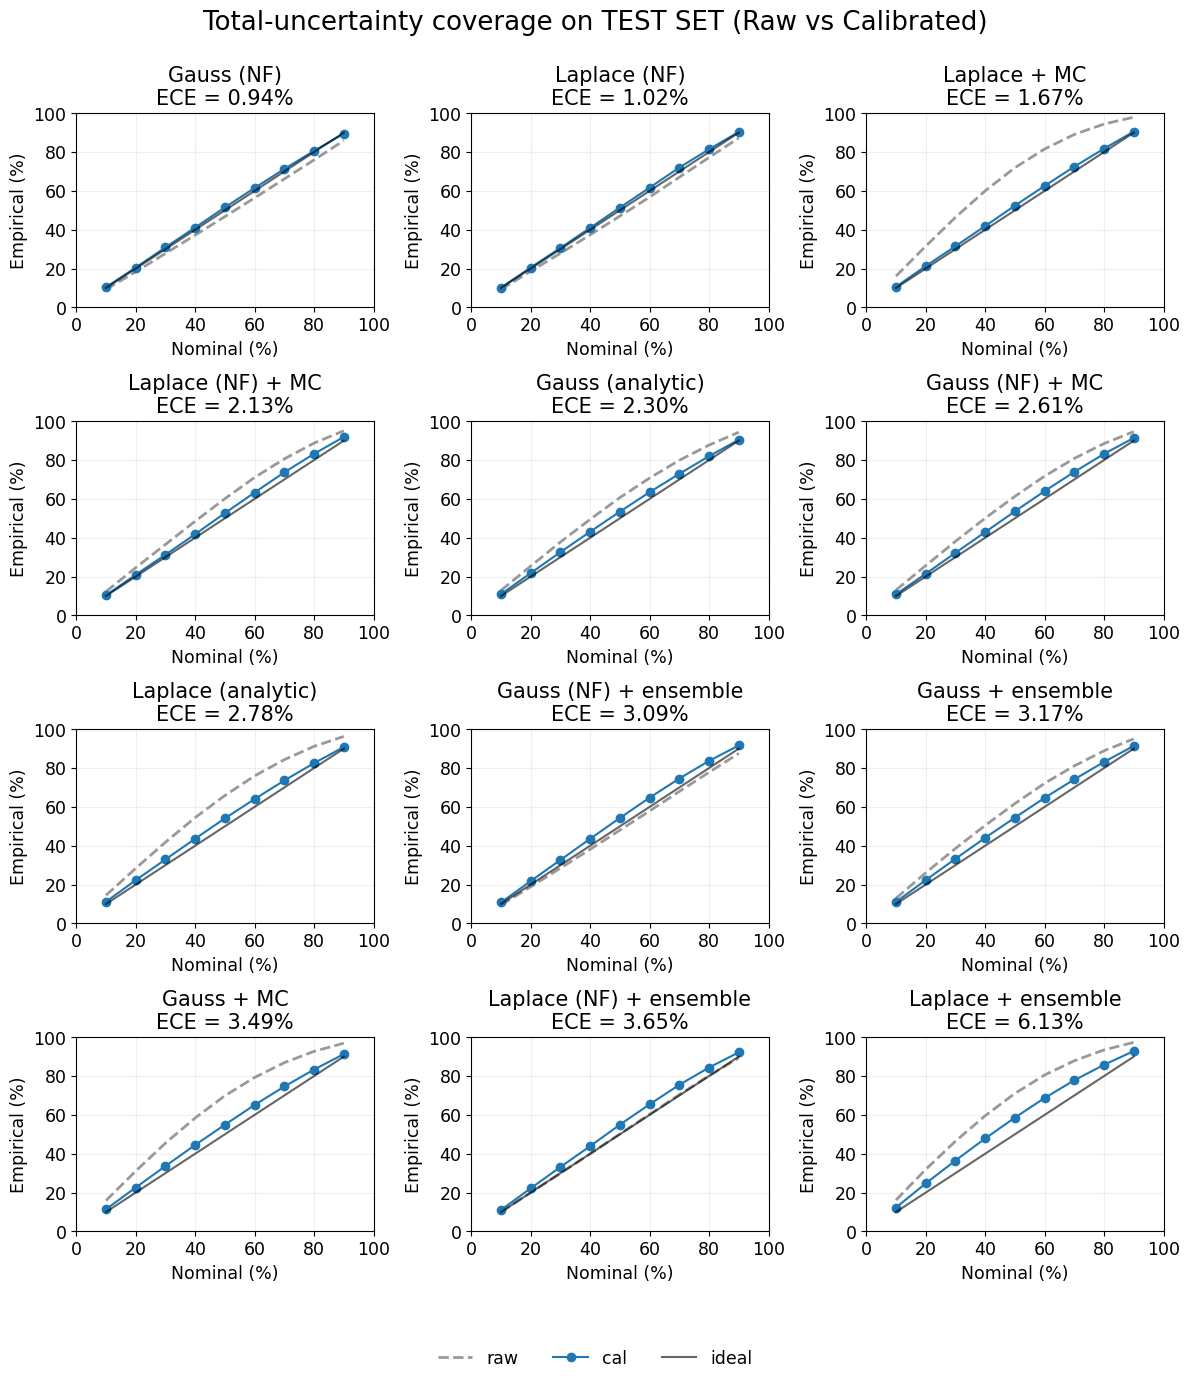

In [85]:
# Phase 4C: calibration diagnostic (ID:test) - nominal vs empirical coverage

NOMINAL_LEVELS = list(range(10, 100, 10))

# ----------------- font scaling -----------------
FONT_SCALE = 1.25

from matplotlib.font_manager import FontProperties

def _to_points(v, fallback=10.0) -> float:
    try:
        return float(FontProperties(size=v).get_size_in_points())
    except Exception:
        try:
            return float(v)
        except Exception:
            return float(fallback)

TITLE_SIZE = _to_points(plt.rcParams.get("axes.titlesize", 12)) * FONT_SCALE
LABEL_SIZE = _to_points(plt.rcParams.get("axes.labelsize", 10)) * FONT_SCALE
TICK_SIZE = _to_points(plt.rcParams.get("xtick.labelsize", 10)) * FONT_SCALE
LEGEND_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10)) * FONT_SCALE
SUPTITLE_SIZE = _to_points(plt.rcParams.get("figure.titlesize", plt.rcParams.get("axes.titlesize", 12))) * FONT_SCALE
# -----------------------------------------------


def coverage_at_levels(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray, levels: list[int]) -> dict[int, float]:
    cov = {}
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    base_mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    for lvl in levels:
        z = float(norm.ppf(0.5 + (lvl / 200.0)))
        m = base_mask & np.isfinite(z)
        cov[lvl] = float(np.mean(np.abs(y[m] - mu[m]) <= z * sigma[m])) if np.any(m) else float("nan")
    return cov


rows = []
for spec in METHODS:
    if spec.head_type == "point" or spec.kind == "dido":
        continue
    try:
        df = method_id_frame(spec, "test")
    except Exception as e:
        print(f"[skip coverage] {spec.key}: {type(e).__name__}: {e}")
        continue
    if "y_true" not in df.columns or "mu" not in df.columns:
        continue

    y = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(float)
    mu = pd.to_numeric(df["mu"], errors="coerce").to_numpy(float)
    s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").fillna(0.0).to_numpy(float)
    s_raw = np.sqrt(np.maximum(np.nan_to_num(s_a_raw, nan=0.0) ** 2 + np.nan_to_num(s_e_raw, nan=0.0) ** 2, 0.0))
    _, _, s_cal = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=s_a_raw,
        sigma_epi_raw=s_e_raw,
    )

    cov_raw = coverage_at_levels(y, mu, s_raw, NOMINAL_LEVELS)
    cov_cal = coverage_at_levels(y, mu, s_cal, NOMINAL_LEVELS)
    ece = float(100.0 * np.nanmean([abs(cov_cal[l] - (l / 100.0)) for l in NOMINAL_LEVELS]))
    rows.append({
        "method": spec.label,
        "key": spec.key,
        "ece_pp": ece,
        **{f"cov_raw_{l}": cov_raw[l] for l in NOMINAL_LEVELS},
        **{f"cov_cal_{l}": cov_cal[l] for l in NOMINAL_LEVELS},
    })

df_cov = pd.DataFrame(rows).sort_values("ece_pp")
EXPORTER.export_table(df_cov, "calibration_coverage_full", dataset=DATASET_KEY, split="test")
EXPORTER.export_table(df_cov[["method", "ece_pp"] + [f"cov_cal_{l}" for l in NOMINAL_LEVELS]], "calibration_coverage", dataset=DATASET_KEY, split="test")
display(df_cov[["method", "ece_pp"] + [f"cov_cal_{l}" for l in NOMINAL_LEVELS]])

# Small multiples plot (raw vs calibrated)
methods_order = df_cov["method"].tolist()
n = len(methods_order)
if n:
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)
    for ax, method in zip(axes, methods_order):
        row = df_cov[df_cov["method"] == method].iloc[0]
        cov_raw = [100.0 * row[f"cov_raw_{l}"] for l in NOMINAL_LEVELS]
        cov_cal = [100.0 * row[f"cov_cal_{l}"] for l in NOMINAL_LEVELS]
        ax.plot(NOMINAL_LEVELS, cov_raw, "--", color="0.6", linewidth=2.0, label="raw")
        ax.plot(NOMINAL_LEVELS, cov_cal, "-o", color="tab:blue", label="cal")
        ax.plot(NOMINAL_LEVELS, NOMINAL_LEVELS, "k-", alpha=0.6, label="ideal")
        ax.set_title(f"{method}\nECE = {row['ece_pp']:.2f}%", fontsize=TITLE_SIZE)
        ax.set_xlabel("Nominal (%)", fontsize=LABEL_SIZE)
        ax.set_ylabel("Empirical (%)", fontsize=LABEL_SIZE)
        ax.tick_params(axis="both", which="both", labelsize=TICK_SIZE)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.2)
    for ax in axes[len(methods_order):]:
        ax.set_axis_off()
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=LEGEND_SIZE)
    fig.suptitle("Total-uncertainty coverage on TEST SET (Raw vs Calibrated)", fontsize=SUPTITLE_SIZE + SUPTITLE_SIZE * 0.25)
    fig.tight_layout(rect=[0, 0.06, 1, 0.98])
    savefig(fig, "calibration_coverage", dataset=DATASET_KEY, split="test")
    plt.show()


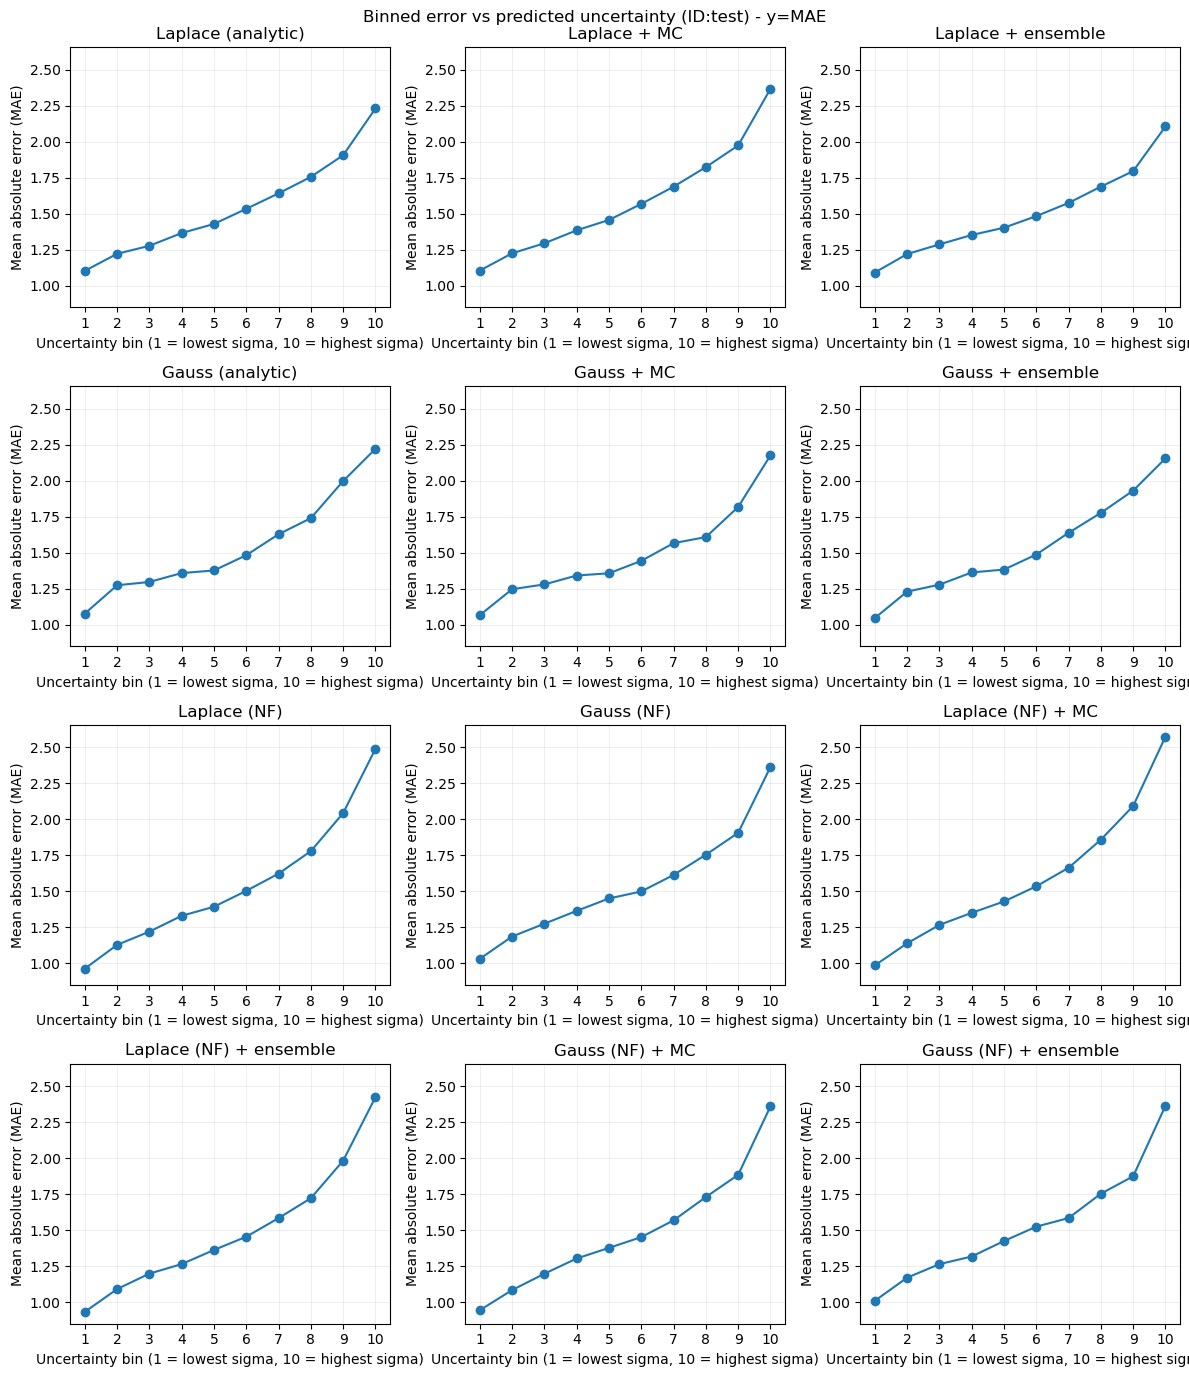

In [86]:
# Phase 4D: binned error vs uncertainty (ID:test)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

BIN_METRIC = "mae"  # "mae" or "crps"
N_BINS = int(N_RELIABILITY_BINS) if "N_RELIABILITY_BINS" in globals() else 10
USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True


def _gaussian_crps_per_row(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    out = np.full_like(y, np.nan, dtype=float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return out
    yy = y[mask]
    mm = mu[mask]
    ss = np.clip(sigma[mask], 1e-8, None)
    z = (yy - mm) / ss
    crps = ss * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    out[mask] = crps
    return out


def _compute_bins_and_means(y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, *, n_bins: int) -> pd.DataFrame:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)
    abs_err = np.abs(y - mu)
    crps = _gaussian_crps_per_row(y, mu, sigma_total)
    mask = np.isfinite(sigma_total) & (sigma_total > 0) & np.isfinite(abs_err)
    if not np.any(mask):
        return pd.DataFrame(columns=["bin", "bin_sigma_mean", "bin_mae_mean", "bin_crps_mean", "n"])
    s = sigma_total[mask]
    ae = abs_err[mask]
    cr = crps[mask]
    bins = pd.qcut(s, n_bins, labels=False, duplicates="drop")
    df = pd.DataFrame({"bin": bins.astype(int) + 1, "sigma": s, "abs_err": ae, "crps": cr})
    out = (
        df.groupby("bin")
        .agg(
            bin_sigma_mean=("sigma", "mean"),
            bin_mae_mean=("abs_err", "mean"),
            bin_crps_mean=("crps", "mean"),
            n=("abs_err", "size"),
        )
        .reset_index()
        .sort_values("bin")
        .reset_index(drop=True)
    )
    return out


bins_rows = []
for spec in METHODS:
    if spec.head_type == "point" or spec.kind == "dido":
        continue
    try:
        df = method_id_frame(spec, "test")
    except Exception as e:
        print(f"[skip bins] {spec.key}: {type(e).__name__}: {e}")
        continue

    y = pd.to_numeric(df.get("y_true"), errors="coerce").to_numpy(float)
    mu = pd.to_numeric(df.get("mu"), errors="coerce").to_numpy(float)
    s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").fillna(0.0).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=s_e_raw,
        )
    else:
        s_t = np.sqrt(np.maximum(np.nan_to_num(s_a_raw, nan=0.0) ** 2 + np.nan_to_num(s_e_raw, nan=0.0) ** 2, 0.0))

    bdf = _compute_bins_and_means(y, mu, s_t, n_bins=N_BINS)
    if bdf.empty:
        continue
    bdf["method"] = spec.label
    bins_rows.append(bdf)

if not bins_rows:
    print("[bins] No binned data available.")
else:
    df_bins = pd.concat(bins_rows, ignore_index=True)
    metric_key = str(BIN_METRIC).strip().lower()
    if metric_key not in {"mae", "crps"}:
        raise ValueError(f"BIN_METRIC must be 'mae' or 'crps', got {BIN_METRIC!r}")
    y_col = "bin_mae_mean" if metric_key == "mae" else "bin_crps_mean"
    y_label = "Mean absolute error (MAE)" if metric_key == "mae" else "Mean Gaussian CRPS"
    EXPORTER.export_table(df_bins, f"binned_error_{metric_key}", dataset=DATASET_KEY, split="test")

    methods_order = df_bins["method"].dropna().unique().tolist()
    if methods_order:
        y_vals = df_bins[y_col].to_numpy(float)
        y_vals = y_vals[np.isfinite(y_vals)]
        y_min, y_max = float(np.min(y_vals)), float(np.max(y_vals))
        pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
        y_lim = (y_min - pad, y_max + pad)

        ncols = 3
        nrows = int(np.ceil(len(methods_order) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
        axes = np.atleast_1d(axes).reshape(-1)

        for ax, method in zip(axes, methods_order):
            sub = df_bins[df_bins["method"] == method].copy()
            if sub.empty:
                ax.set_axis_off()
                continue
            ax.plot(sub["bin"], sub[y_col], "-o", color="tab:blue")
            ax.set_ylim(*y_lim)
            ax.set_title(method)
            ax.set_xlabel("Uncertainty bin (1 = lowest sigma, 10 = highest sigma)")
            ax.set_ylabel(y_label)
            ax.set_xticks(np.arange(1, N_BINS + 1))
            ax.grid(True, alpha=0.2)

        for ax in axes[len(methods_order):]:
            ax.set_axis_off()

        fig.suptitle(f"Binned error vs predicted uncertainty (ID:test) - y={metric_key.upper()}")
        fig.tight_layout()
        # savefig(fig, f"binned_error_{metric_key}", dataset=DATASET_KEY, split="test")
        plt.show()


## Phase 5: OOD + large-error detection

This phase evaluates **ID vs OOD separation** and **large-error detection** using uncertainty scores.

In [87]:
# Phase 5 helpers: kNN band filtering for ID vs OOD

import pandas as pd
from pathlib import Path

_KNN_BANDS_CACHE = {}


def load_knn_bands(dataset_key: str):
    if dataset_key in _KNN_BANDS_CACHE:
        return _KNN_BANDS_CACHE[dataset_key]
    if not dataset_key:
        print("[knn bands] DATASET_KEY missing; falling back to full ID:test vs OOD.")
        _KNN_BANDS_CACHE[dataset_key] = (None, None)
        return _KNN_BANDS_CACHE[dataset_key]
    root = PROJECT_ROOT if "PROJECT_ROOT" in globals() else Path(".")
    knn_dir = Path(root) / "datasets" / "knn_ood"
    id_path = knn_dir / f"{dataset_key}_id_knn.csv"
    ood_path = knn_dir / f"{dataset_key}_ood_knn.csv"
    if not id_path.exists() or not ood_path.exists():
        print(
            f"[knn bands] Missing band files for {dataset_key}: {id_path} or {ood_path}. "
            "Falling back to full ID:test vs OOD."
        )
        _KNN_BANDS_CACHE[dataset_key] = (None, None)
        return _KNN_BANDS_CACHE[dataset_key]

    def _read_ids(path: Path):
        df = pd.read_csv(path, usecols=["id"])
        ids = pd.to_numeric(df["id"], errors="coerce").dropna().astype(int)
        return set(ids.tolist())

    id_ids = _read_ids(id_path)
    ood_ids = _read_ids(ood_path)
    _KNN_BANDS_CACHE[dataset_key] = (id_ids, ood_ids)
    return _KNN_BANDS_CACHE[dataset_key]


def filter_to_ids(df: pd.DataFrame, ids):
    if ids is None:
        return df
    if "id" not in df.columns:
        print("[knn bands] 'id' column missing; skipping ID/OOD filtering.")
        return df
    out = df.copy()
    out["id"] = pd.to_numeric(out["id"], errors="coerce")
    out = out.dropna(subset=["id"])
    out["id"] = out["id"].astype(int)
    return out[out["id"].isin(ids)].copy()


def _assert_disjoint(df_id: pd.DataFrame, df_ood: pd.DataFrame, label: str, spec_key: str | None = None):
    if "id" not in df_id.columns or "id" not in df_ood.columns:
        return
    id_set = set(pd.to_numeric(df_id["id"], errors="coerce").dropna().astype(int).tolist())
    ood_set = set(pd.to_numeric(df_ood["id"], errors="coerce").dropna().astype(int).tolist())
    overlap = id_set & ood_set
    assert not overlap, f"[knn bands] ID/OOD overlap for label={label} spec={spec_key}: {len(overlap)}"


def apply_knn_bands(df_id: pd.DataFrame, df_ood: pd.DataFrame, label: str, spec_key: str | None = None):
    if str(label).lower() != "knn":
        return df_id, df_ood
    id_ids, ood_ids = load_knn_bands(DATASET_KEY)
    if id_ids is None or ood_ids is None:
        return df_id, df_ood
    df_id = filter_to_ids(df_id, id_ids)
    df_ood = filter_to_ids(df_ood, ood_ids)
    _assert_disjoint(df_id, df_ood, label, spec_key)
    return df_id, df_ood


In [88]:
# # Phase 5A1: kNN score density (ID vs OOD)

# import pandas as pd
# import matplotlib.pyplot as plt

# if not DATASET_KEY:
#     print("[knn density] DATASET_KEY missing; skipping.")
# else:
#     knn_dir = PROJECT_ROOT / "datasets" / "knn_ood"
#     id_path = knn_dir / f"{DATASET_KEY}_id_knn.csv"
#     ood_path = knn_dir / f"{DATASET_KEY}_ood_knn.csv"

#     if not id_path.exists() or not ood_path.exists():
#         print(f"[knn density] Missing files: {id_path} or {ood_path}")
#     else:
#         def _read_knn(path):
#             cols = pd.read_csv(path, nrows=0).columns
#             if "knn_score" not in cols:
#                 return None
#             return pd.read_csv(path, usecols=["knn_score"])

#         df_id = _read_knn(id_path)
#         df_ood = _read_knn(ood_path)
#         if df_id is None or df_ood is None:
#             print("[knn density] 'knn_score' column missing; skipping.")
#         else:
#             plt.figure(figsize=(7, 4.5))
#             plt.hist(df_id["knn_score"].to_numpy(float), bins=50, density=True, alpha=0.6, label="TEST", color="tab:blue")
#             plt.hist(df_ood["knn_score"].to_numpy(float), bins=50, density=True, alpha=0.6, label="OOD", color="tab:orange")
#             plt.xlabel("knn_score")
#             plt.ylabel("Density")
#             plt.title("kNN Score Density")
#             plt.legend(frameon=False)
#             plt.grid(True, alpha=0.2)
#             plt.tight_layout()
#             savefig(plt.gcf(), "knn_score_density", dataset=DATASET_KEY, split="test")
#             plt.show()


In [89]:
# # Phase 5A1b: kNN score density (FULL) — ID vs middle vs OOD (single distribution, colored bands)
# # Uses same k-selection logic as the kNN builder by default, with an optional manual override.

# import json
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import yaml
# from sklearn.neighbors import NearestNeighbors
# from matplotlib.patches import Patch

# # ---- font scaling (25% bigger) ----
# FONT_SCALE = 1.25

# def _as_points(v, default):
#     if isinstance(v, (int, float)):
#         return float(v)
#     mapping = {
#         "xx-small": 6, "x-small": 8, "small": 10, "medium": 12,
#         "large": 14, "x-large": 16, "xx-large": 18,
#     }
#     return float(mapping.get(str(v).lower(), default))

# TITLE_SIZE = _as_points(plt.rcParams.get("axes.titlesize", 12), 12) * FONT_SCALE
# LABEL_SIZE = _as_points(plt.rcParams.get("axes.labelsize", 10), 10) * FONT_SCALE
# TICK_SIZE  = _as_points(plt.rcParams.get("xtick.labelsize", 10), 10) * FONT_SCALE
# LEGEND_SIZE = _as_points(plt.rcParams.get("legend.fontsize", 10), 10) * FONT_SCALE
# # -----------------------------------

# if not DATASET_KEY:
#     print("[knn density full] DATASET_KEY missing; skipping.")
# else:
#     # ----------------- toggles -----------------
#     FORCE_K = None          # e.g. 12. If None, choose k exactly like the builder (max gap over knn_k_list).
#     SHOW_CUT_LINES = False   # vertical lines at band cutpoints
#     N_BINS = 60
#     # -------------------------------------------

#     cfg_path = PROJECT_ROOT / "configs" / f"knn_ood_{DATASET_KEY}.yaml"
#     if not cfg_path.exists():
#         cfg_path = PROJECT_ROOT / "configs" / "knn_ood.yaml"

#     if not cfg_path.exists():
#         print(f"[knn density full] Missing config: {cfg_path}")
#     else:
#         cfg = yaml.safe_load(cfg_path.read_text())
#         params = cfg.get("knn_ood", {}) or {}

#         csv_path = (PROJECT_ROOT / params["csv_path"]).resolve()
#         preproc_meta = (PROJECT_ROOT / params["preproc_meta"]).resolve()

#         ref_split = str(params.get("ref_split", "train"))
#         cand_split = str(params.get("candidate_split", "test"))
#         ref_limit = params.get("ref_limit", None)

#         proj_dim = int(params.get("proj_dim", 32))
#         knn_k_list = params.get("knn_k_list", None)
#         if knn_k_list is None:
#             knn_k_list = [int(params.get("knn_k", 5))]
#         knn_k_list = [int(k) for k in knn_k_list]

#         id_q = params.get("id_q", [0.0, 0.80])
#         ood_q = params.get("ood_q", [0.95, 1.0])
#         id_q_lo, id_q_hi = float(id_q[0]), float(id_q[1])
#         ood_q_lo, ood_q_hi = float(ood_q[0]), float(ood_q[1])

#         chunk_rows = int(params.get("chunk_rows", 20_000))
#         seed = int(params.get("seed", 1))

#         if not csv_path.exists() or not preproc_meta.exists():
#             print(f"[knn density full] Missing csv_path or preproc_meta: {csv_path} / {preproc_meta}")
#         else:
#             from scripts.make_knn_ood_knn import _add_derived_features, _build_projection, _project_chunk

#             meta = json.loads(preproc_meta.read_text())
#             id_col = meta.get("id_col", "id")
#             id_values = meta.get("id_values")
#             if id_values is None:
#                 raise RuntimeError("preproc_meta.json missing 'id_values'")

#             split_idx = meta.get("splits", {})
#             if ref_split not in split_idx:
#                 raise RuntimeError(f"ref_split='{ref_split}' missing in preproc_meta.splits")
#             if cand_split.lower() != "all" and cand_split not in split_idx:
#                 raise RuntimeError(f"candidate_split='{cand_split}' missing in preproc_meta.splits")

#             ref_ids = [str(id_values[i]) for i in split_idx[ref_split]]
#             if cand_split.lower() == "all":
#                 cand_ids = [str(x) for x in id_values]
#             else:
#                 cand_ids = [str(id_values[i]) for i in split_idx[cand_split]]

#             if ref_limit is not None and int(ref_limit) < len(ref_ids):
#                 rng = np.random.default_rng(seed)
#                 ref_ids = rng.choice(ref_ids, size=int(ref_limit), replace=False).tolist()

#             ref_set = set(ref_ids)
#             cand_set = set(cand_ids)

#             numeric_cols = list(meta["encoders"]["num"].keys())
#             onehot_levels = meta["encoders"]["oh_levels"]
#             hash_dims = meta["encoders"]["hash_dims"]
#             feature_dim = int(meta["feature_dim"])
#             proj = _build_projection(feature_dim, proj_dim, seed)

#             ref_embeddings = []
#             cand_embeddings = []

#             seen_ref = 0
#             seen_cand = 0

#             for chunk in pd.read_csv(csv_path, chunksize=chunk_rows):
#                 if id_col not in chunk.columns:
#                     raise KeyError(f"ID column '{id_col}' not found in CSV: {csv_path}")

#                 chunk["id_str"] = chunk[id_col].astype(str)
#                 chunk = _add_derived_features(chunk)

#                 mask_ref = chunk["id_str"].isin(ref_set)
#                 mask_cand = chunk["id_str"].isin(cand_set)

#                 if mask_ref.any():
#                     sub = chunk.loc[mask_ref].copy()
#                     Z = _project_chunk(sub, meta["encoders"], proj, numeric_cols, onehot_levels, hash_dims)
#                     ref_embeddings.append(Z)
#                     seen_ref += len(sub)

#                 if mask_cand.any():
#                     sub = chunk.loc[mask_cand].copy()
#                     Z = _project_chunk(sub, meta["encoders"], proj, numeric_cols, onehot_levels, hash_dims)
#                     cand_embeddings.append(Z)
#                     seen_cand += len(sub)

#                 if seen_ref >= len(ref_ids) and seen_cand >= len(cand_ids):
#                     break

#             if seen_ref == 0 or seen_cand == 0:
#                 raise RuntimeError(f"No rows found for ref ({seen_ref}) or candidate ({seen_cand}).")

#             Z_ref = np.vstack(ref_embeddings)
#             Z_cand = np.vstack(cand_embeddings)

#             # Compute knn_score for each k in grid (same as builder), then pick k:
#             # gap = q(ood_lo) - q(id_hi)
#             scores_per_k = {}
#             gap_rows = []
#             for k in knn_k_list:
#                 nn = NearestNeighbors(n_neighbors=k, algorithm="auto", metric="euclidean")
#                 nn.fit(Z_ref)
#                 dists, _ = nn.kneighbors(Z_cand, n_neighbors=k, return_distance=True)
#                 score = dists.mean(axis=1)
#                 scores_per_k[k] = score
#                 id_hi_k = float(np.quantile(score, id_q_hi))
#                 ood_lo_k = float(np.quantile(score, ood_q_lo))
#                 gap_rows.append({"k": k, "gap": float(ood_lo_k - id_hi_k), "std": float(np.std(score))})

#             gap_df = pd.DataFrame(gap_rows).sort_values("k").reset_index(drop=True)

#             if FORCE_K is None:
#                 best_k = int(gap_df.loc[gap_df["gap"].idxmax(), "k"])
#                 chosen_k_reason = "auto (max gap)"
#             else:
#                 best_k = int(FORCE_K)
#                 chosen_k_reason = "manual"
#                 if best_k not in scores_per_k:
#                     raise ValueError(f"FORCE_K={best_k} not in knn_k_list={knn_k_list}. Add it or set FORCE_K=None.")

#             print("[knn density full] k search (gap = q(ood_lo) - q(id_hi)):")
#             print(gap_df.to_string(index=False))
#             print(f"[knn density full] using k={best_k} ({chosen_k_reason})")

#             knn_score = np.asarray(scores_per_k[best_k], float)

#             id_hi = float(np.quantile(knn_score, id_q_hi))
#             ood_lo = float(np.quantile(knn_score, ood_q_lo))

#             # plot: ONE histogram, color bins by band
#             fig, ax = plt.subplots(figsize=(7.2, 4.5))
#             counts, bins, patches = ax.hist(knn_score, bins=N_BINS, density=True, alpha=0.90)

#             for p, left, right in zip(patches, bins[:-1], bins[1:]):
#                 center = 0.5 * (left + right)
#                 if center <= id_hi:
#                     p.set_facecolor("tab:orange")  # ID
#                 elif center >= ood_lo:
#                     p.set_facecolor("tab:blue")    # OOD
#                 else:
#                     p.set_facecolor("0.7")         # middle/ignored

#             if SHOW_CUT_LINES:
#                 ax.axvline(id_hi, color="tab:orange", lw=1.5, alpha=0.9)
#                 ax.axvline(ood_lo, color="tab:blue", lw=1.5, alpha=0.9)

#             ax.set_xlabel(f"kNN Distance Score (k={best_k}, proj_dim={proj_dim})", fontsize=LABEL_SIZE)
#             ax.set_ylabel("Density", fontsize=LABEL_SIZE)
#             ax.set_title("kNN Distance Distribution (original test split)", fontsize=TITLE_SIZE)
#             ax.tick_params(axis="both", labelsize=TICK_SIZE)
#             ax.grid(True, alpha=0.2)

#             handles = [
#                 Patch(facecolor="tab:orange", label="ID band"),
#                 Patch(facecolor="0.7", label="ignored middle"),
#                 Patch(facecolor="tab:blue", label="OOD band"),
#             ]
#             ax.legend(handles=handles, frameon=False, fontsize=LEGEND_SIZE)

#             fig.tight_layout()
#             savefig(fig, "knn_score_density_bands", dataset=DATASET_KEY, split="test")
#             plt.show()


In [90]:
# # Phase 5A1b: kNN score density (FULL) — ID vs middle vs OOD (single distribution, colored bands)
# # Uses same k-selection logic as the kNN builder by default, with an optional manual override.

# import json
# from pathlib import Path

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import yaml
# from sklearn.neighbors import NearestNeighbors
# from matplotlib.patches import Patch

# # ---- font scaling  ----
# FONT_SCALE = 1.05

# def _as_points(v, default):
#     if isinstance(v, (int, float)):
#         return float(v)
#     mapping = {
#         "xx-small": 6, "x-small": 8, "small": 10, "medium": 12,
#         "large": 14, "x-large": 16, "xx-large": 18,
#     }
#     return float(mapping.get(str(v).lower(), default))

# TITLE_SIZE = _as_points(plt.rcParams.get("axes.titlesize", 12), 12) * FONT_SCALE
# LABEL_SIZE = _as_points(plt.rcParams.get("axes.labelsize", 10), 10) * FONT_SCALE
# TICK_SIZE  = _as_points(plt.rcParams.get("xtick.labelsize", 10), 10) * FONT_SCALE
# LEGEND_SIZE = _as_points(plt.rcParams.get("legend.fontsize", 10), 10) * FONT_SCALE
# # -----------------------------------

# if not DATASET_KEY:
#     print("[knn density full] DATASET_KEY missing; skipping.")
# else:
#     # ----------------- toggles -----------------
#     FORCE_K = None          # e.g. 12. If None, choose k exactly like the builder (max gap over knn_k_list).
#     SHOW_CUT_LINES = False   # vertical lines at band cutpoints
#     N_BINS = 60
#     # -------------------------------------------

#     cfg_path = PROJECT_ROOT / "configs" / f"knn_ood_{DATASET_KEY}.yaml"
#     if not cfg_path.exists():
#         cfg_path = PROJECT_ROOT / "configs" / "knn_ood.yaml"

#     if not cfg_path.exists():
#         print(f"[knn density full] Missing config: {cfg_path}")
#     else:
#         cfg = yaml.safe_load(cfg_path.read_text())
#         params = cfg.get("knn_ood", {}) or {}

#         csv_path = (PROJECT_ROOT / params["csv_path"]).resolve()
#         preproc_meta = (PROJECT_ROOT / params["preproc_meta"]).resolve()

#         ref_split = str(params.get("ref_split", "train"))
#         cand_split = str(params.get("candidate_split", "test"))
#         ref_limit = params.get("ref_limit", None)

#         proj_dim = int(params.get("proj_dim", 32))
#         knn_k_list = params.get("knn_k_list", None)
#         if knn_k_list is None:
#             knn_k_list = [int(params.get("knn_k", 5))]
#         knn_k_list = [int(k) for k in knn_k_list]

#         id_q = params.get("id_q", [0.0, 0.80])
#         ood_q = params.get("ood_q", [0.95, 1.0])
#         id_q_lo, id_q_hi = float(id_q[0]), float(id_q[1])
#         ood_q_lo, ood_q_hi = float(ood_q[0]), float(ood_q[1])

#         chunk_rows = int(params.get("chunk_rows", 20_000))
#         seed = int(params.get("seed", 1))

#         if not csv_path.exists() or not preproc_meta.exists():
#             print(f"[knn density full] Missing csv_path or preproc_meta: {csv_path} / {preproc_meta}")
#         else:
#             from scripts.make_knn_ood_knn import _add_derived_features, _build_projection, _project_chunk

#             meta = json.loads(preproc_meta.read_text())
#             id_col = meta.get("id_col", "id")
#             id_values = meta.get("id_values")
#             if id_values is None:
#                 raise RuntimeError("preproc_meta.json missing 'id_values'")

#             split_idx = meta.get("splits", {})
#             if ref_split not in split_idx:
#                 raise RuntimeError(f"ref_split='{ref_split}' missing in preproc_meta.splits")
#             if cand_split.lower() != "all" and cand_split not in split_idx:
#                 raise RuntimeError(f"candidate_split='{cand_split}' missing in preproc_meta.splits")

#             ref_ids = [str(id_values[i]) for i in split_idx[ref_split]]
#             if cand_split.lower() == "all":
#                 cand_ids = [str(x) for x in id_values]
#             else:
#                 cand_ids = [str(id_values[i]) for i in split_idx[cand_split]]

#             if ref_limit is not None and int(ref_limit) < len(ref_ids):
#                 rng = np.random.default_rng(seed)
#                 ref_ids = rng.choice(ref_ids, size=int(ref_limit), replace=False).tolist()

#             ref_set = set(ref_ids)
#             cand_set = set(cand_ids)

#             numeric_cols = list(meta["encoders"]["num"].keys())
#             onehot_levels = meta["encoders"]["oh_levels"]
#             hash_dims = meta["encoders"]["hash_dims"]
#             feature_dim = int(meta["feature_dim"])
#             proj = _build_projection(feature_dim, proj_dim, seed)

#             ref_embeddings = []
#             cand_embeddings = []

#             seen_ref = 0
#             seen_cand = 0

#             for chunk in pd.read_csv(csv_path, chunksize=chunk_rows):
#                 if id_col not in chunk.columns:
#                     raise KeyError(f"ID column '{id_col}' not found in CSV: {csv_path}")

#                 chunk["id_str"] = chunk[id_col].astype(str)
#                 chunk = _add_derived_features(chunk)

#                 mask_ref = chunk["id_str"].isin(ref_set)
#                 mask_cand = chunk["id_str"].isin(cand_set)

#                 if mask_ref.any():
#                     sub = chunk.loc[mask_ref].copy()
#                     Z = _project_chunk(sub, meta["encoders"], proj, numeric_cols, onehot_levels, hash_dims)
#                     ref_embeddings.append(Z)
#                     seen_ref += len(sub)

#                 if mask_cand.any():
#                     sub = chunk.loc[mask_cand].copy()
#                     Z = _project_chunk(sub, meta["encoders"], proj, numeric_cols, onehot_levels, hash_dims)
#                     cand_embeddings.append(Z)
#                     seen_cand += len(sub)

#                 if seen_ref >= len(ref_ids) and seen_cand >= len(cand_ids):
#                     break

#             if seen_ref == 0 or seen_cand == 0:
#                 raise RuntimeError(f"No rows found for ref ({seen_ref}) or candidate ({seen_cand}).")

#             Z_ref = np.vstack(ref_embeddings)
#             Z_cand = np.vstack(cand_embeddings)

#             # Compute knn_score for each k in grid (same as builder), then pick k:
#             # gap = q(ood_lo) - q(id_hi)
#             scores_per_k = {}
#             gap_rows = []
#             for k in knn_k_list:
#                 nn = NearestNeighbors(n_neighbors=k, algorithm="auto", metric="euclidean")
#                 nn.fit(Z_ref)
#                 dists, _ = nn.kneighbors(Z_cand, n_neighbors=k, return_distance=True)
#                 score = dists.mean(axis=1)
#                 scores_per_k[k] = score
#                 id_hi_k = float(np.quantile(score, id_q_hi))
#                 ood_lo_k = float(np.quantile(score, ood_q_lo))
#                 gap_rows.append({"k": k, "gap": float(ood_lo_k - id_hi_k), "std": float(np.std(score))})

#             gap_df = pd.DataFrame(gap_rows).sort_values("k").reset_index(drop=True)

#             if FORCE_K is None:
#                 best_k = int(gap_df.loc[gap_df["gap"].idxmax(), "k"])
#                 chosen_k_reason = "auto (max gap)"
#             else:
#                 best_k = int(FORCE_K)
#                 chosen_k_reason = "manual"
#                 if best_k not in scores_per_k:
#                     raise ValueError(f"FORCE_K={best_k} not in knn_k_list={knn_k_list}. Add it or set FORCE_K=None.")

#             print("[knn density full] k search (gap = q(ood_lo) - q(id_hi)):")
#             print(gap_df.to_string(index=False))
#             print(f"[knn density full] using k={best_k} ({chosen_k_reason})")

#             knn_score = np.asarray(scores_per_k[best_k], float)

#             id_hi = float(np.quantile(knn_score, id_q_hi))
#             ood_lo = float(np.quantile(knn_score, ood_q_lo))

#             # plot: ONE histogram, color bins by band
#             fig, ax = plt.subplots(figsize=(7.2, 4.5))
#             counts, bins, patches = ax.hist(knn_score, bins=N_BINS, density=True, alpha=0.90)

#             for p, left, right in zip(patches, bins[:-1], bins[1:]):
#                 center = 0.5 * (left + right)
#                 if center <= id_hi:
#                     p.set_facecolor("tab:orange")  # ID
#                 elif center >= ood_lo:
#                     p.set_facecolor("tab:blue")    # OOD
#                 else:
#                     p.set_facecolor("0.7")         # middle/ignored

#             if SHOW_CUT_LINES:
#                 ax.axvline(id_hi, color="tab:orange", lw=1.5, alpha=0.9)
#                 ax.axvline(ood_lo, color="tab:blue", lw=1.5, alpha=0.9)

#             ax.set_xlabel(f"kNN Distance Score (k={best_k}, proj_dim={proj_dim})", fontsize=LABEL_SIZE)
#             ax.set_ylabel("Density", fontsize=LABEL_SIZE)
#             ax.set_title("kNN Distance Distribution", fontsize=TITLE_SIZE)
#             ax.tick_params(axis="both", labelsize=TICK_SIZE)
#             ax.grid(True, alpha=0.2)

#             handles = [
#                 Patch(facecolor="tab:orange", label="TEST SET band"),
#                 Patch(facecolor="0.7", label="Ignored band"),
#                 Patch(facecolor="tab:blue", label="OOD subset"),
#             ]
#             ax.legend(handles=handles, frameon=False, fontsize=LEGEND_SIZE)

#             fig.tight_layout()
#             savefig(fig, "knn_score_density_bands", dataset=DATASET_KEY, split="test")
#             plt.show()


In [91]:
# # Phase 5A2: OOD - ID quantile shift (Ua / Ue)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# INCLUDE_ALEATORIC_ONLY_BASELINES = False
# USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
# QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# if not OOD_LABELS:
#     print("[quantile shift] No OOD labels configured; skipping.")
# else:
#     def _has_epi(spec: MethodSpec) -> bool:
#         return str(spec.epistemic_source).lower() in {"mc", "ensemble"}

#     def _sigmas_for(spec: MethodSpec, df: pd.DataFrame):
#         s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
#         s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").to_numpy(float)
#         if USE_CALIBRATED_SIGMAS_LOCAL:
#             s_e0 = np.nan_to_num(s_e_raw, nan=0.0)
#             s_a, s_e, s_t = calibrated_sigmas(
#                 head_type=spec.head_type,
#                 ale_src=spec.aleatoric_source,
#                 epi_src=spec.epistemic_source,
#                 sigma_ale_raw=s_a_raw,
#                 sigma_epi_raw=s_e0,
#             )
#             s_e = np.asarray(s_e, float)
#             s_e[~np.isfinite(s_e_raw)] = np.nan
#             return np.asarray(s_a, float), s_e, np.asarray(s_t, float)
#         s_a = np.asarray(s_a_raw, float)
#         s_e = np.asarray(s_e_raw, float)
#         s_t = np.sqrt(np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0))
#         return s_a, s_e, s_t

#     def _quantile_row(vals: np.ndarray) -> dict:
#         vals = np.asarray(vals, float)
#         vals = vals[np.isfinite(vals)]
#         if vals.size == 0:
#             return {f"q{int(q*100)}": np.nan for q in QUANTILES}
#         return {f"q{int(q*100)}": float(np.quantile(vals, q)) for q in QUANTILES}

#     methods_used = []
#     for spec in METHODS:
#         if spec.head_type == "point" or spec.kind == "dido":
#             continue
#         if _has_epi(spec) or INCLUDE_ALEATORIC_ONLY_BASELINES:
#             methods_used.append(spec)

#     knn_id_ids, knn_ood_ids = (None, None)
#     if any(str(l).lower() == "knn" for l in OOD_LABELS):
#         knn_id_ids, knn_ood_ids = load_knn_bands(DATASET_KEY)

#     if not methods_used:
#         print("[quantile shift] No eligible methods.")
#     else:
#         for sig_key, sig_title in [("Ua", "Ua (aleatoric)"), ("Ue", "Ue (epistemic)")]:
#             ncols = 2
#             nrows = int(np.ceil(len(methods_used) / ncols))
#             fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 3.8 * nrows), sharex=False, sharey=False)
#             axes = np.atleast_1d(axes).reshape(-1)

#             for ax, spec in zip(axes, methods_used):
#                 try:
#                     df_id = method_id_frame(spec, "test")
#                     if knn_id_ids is not None:
#                         df_id = filter_to_ids(df_id, knn_id_ids)
#                     sA_id, sE_id, _ = _sigmas_for(spec, df_id)
#                 except Exception as e:
#                     ax.set_axis_off()
#                     ax.set_title(f"{spec.label} (skip ID: {type(e).__name__})")
#                     continue

#                 sA_ood_list = []
#                 sE_ood_list = []
#                 for label in OOD_LABELS:
#                     try:
#                         df_o = method_ood_frame(spec, label)
#                         if str(label).lower() == "knn" and knn_ood_ids is not None:
#                             df_o = filter_to_ids(df_o, knn_ood_ids)
#                             _assert_disjoint(df_id, df_o, label, spec.key)
#                         sA_o, sE_o, _ = _sigmas_for(spec, df_o)
#                         sA_ood_list.append(sA_o)
#                         sE_ood_list.append(sE_o)
#                     except Exception:
#                         continue

#                 if sA_ood_list:
#                     sA_ood = np.concatenate(sA_ood_list)
#                     sE_ood = np.concatenate(sE_ood_list)
#                 else:
#                     sA_ood = np.array([])
#                     sE_ood = np.array([])

#                 id_vals = sA_id if sig_key == "Ua" else sE_id
#                 ood_vals = sA_ood if sig_key == "Ua" else sE_ood

#                 q_id = _quantile_row(id_vals)
#                 q_ood = _quantile_row(ood_vals)
#                 delta = [q_ood[f"q{int(q*100)}"] - q_id[f"q{int(q*100)}"] for q in QUANTILES]

#                 x = np.arange(len(QUANTILES))
#                 ax.plot(x, delta, "o-", label="OOD - ID", color="tab:purple")
#                 ax.axhline(0.0, color="k", lw=1, alpha=0.4)
#                 ax.set_xticks(x)
#                 ax.set_xticklabels([f"q{int(q*100)}" for q in QUANTILES])
#                 ax.set_title(spec.label)
#                 ax.set_ylabel(f"Delta {sig_key}")
#                 ax.grid(True, alpha=0.2)
#                 ax.legend(frameon=False)

#             for ax in axes[len(methods_used):]:
#                 ax.set_axis_off()

#             fig.suptitle(f"{sig_title} quantile shift (OOD - ID) - {'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}")
#             # savefig(fig, f"ood_quantile_shift_{sig_key.lower()}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split="test")
#             plt.show()


,ood_label,method,signal,n_id,n_ood,n_used,auc,auprc,use_calibrated
0,knn,Gauss + ensemble,Ue,64232,4015,68247,0.776876,0.261004,True
1,knn,Gauss + DIDO,dido_vacuity_raw,64232,4015,68247,0.712307,0.280312,False
2,knn,Laplace + ensemble,Ue,64232,4015,68247,0.708580,0.174629,True
3,knn,Gauss + MC,Ue,64232,4015,68247,0.579734,0.099555,True
4,knn,Laplace + DIDO,dido_vacuity_raw,64232,4015,68247,0.519885,0.154735,False
5,knn,Laplace + MC,Ue,64232,4015,68247,0.481855,0.061066,True


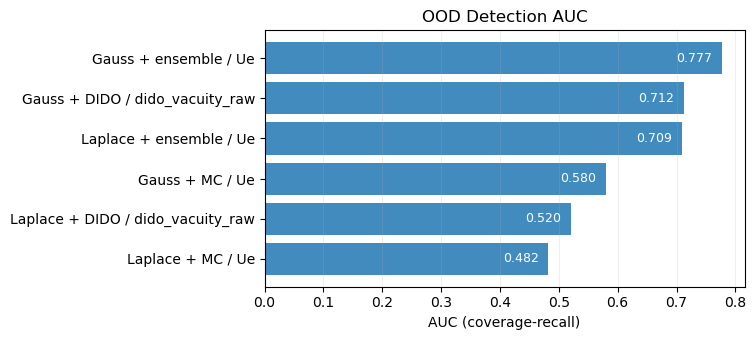

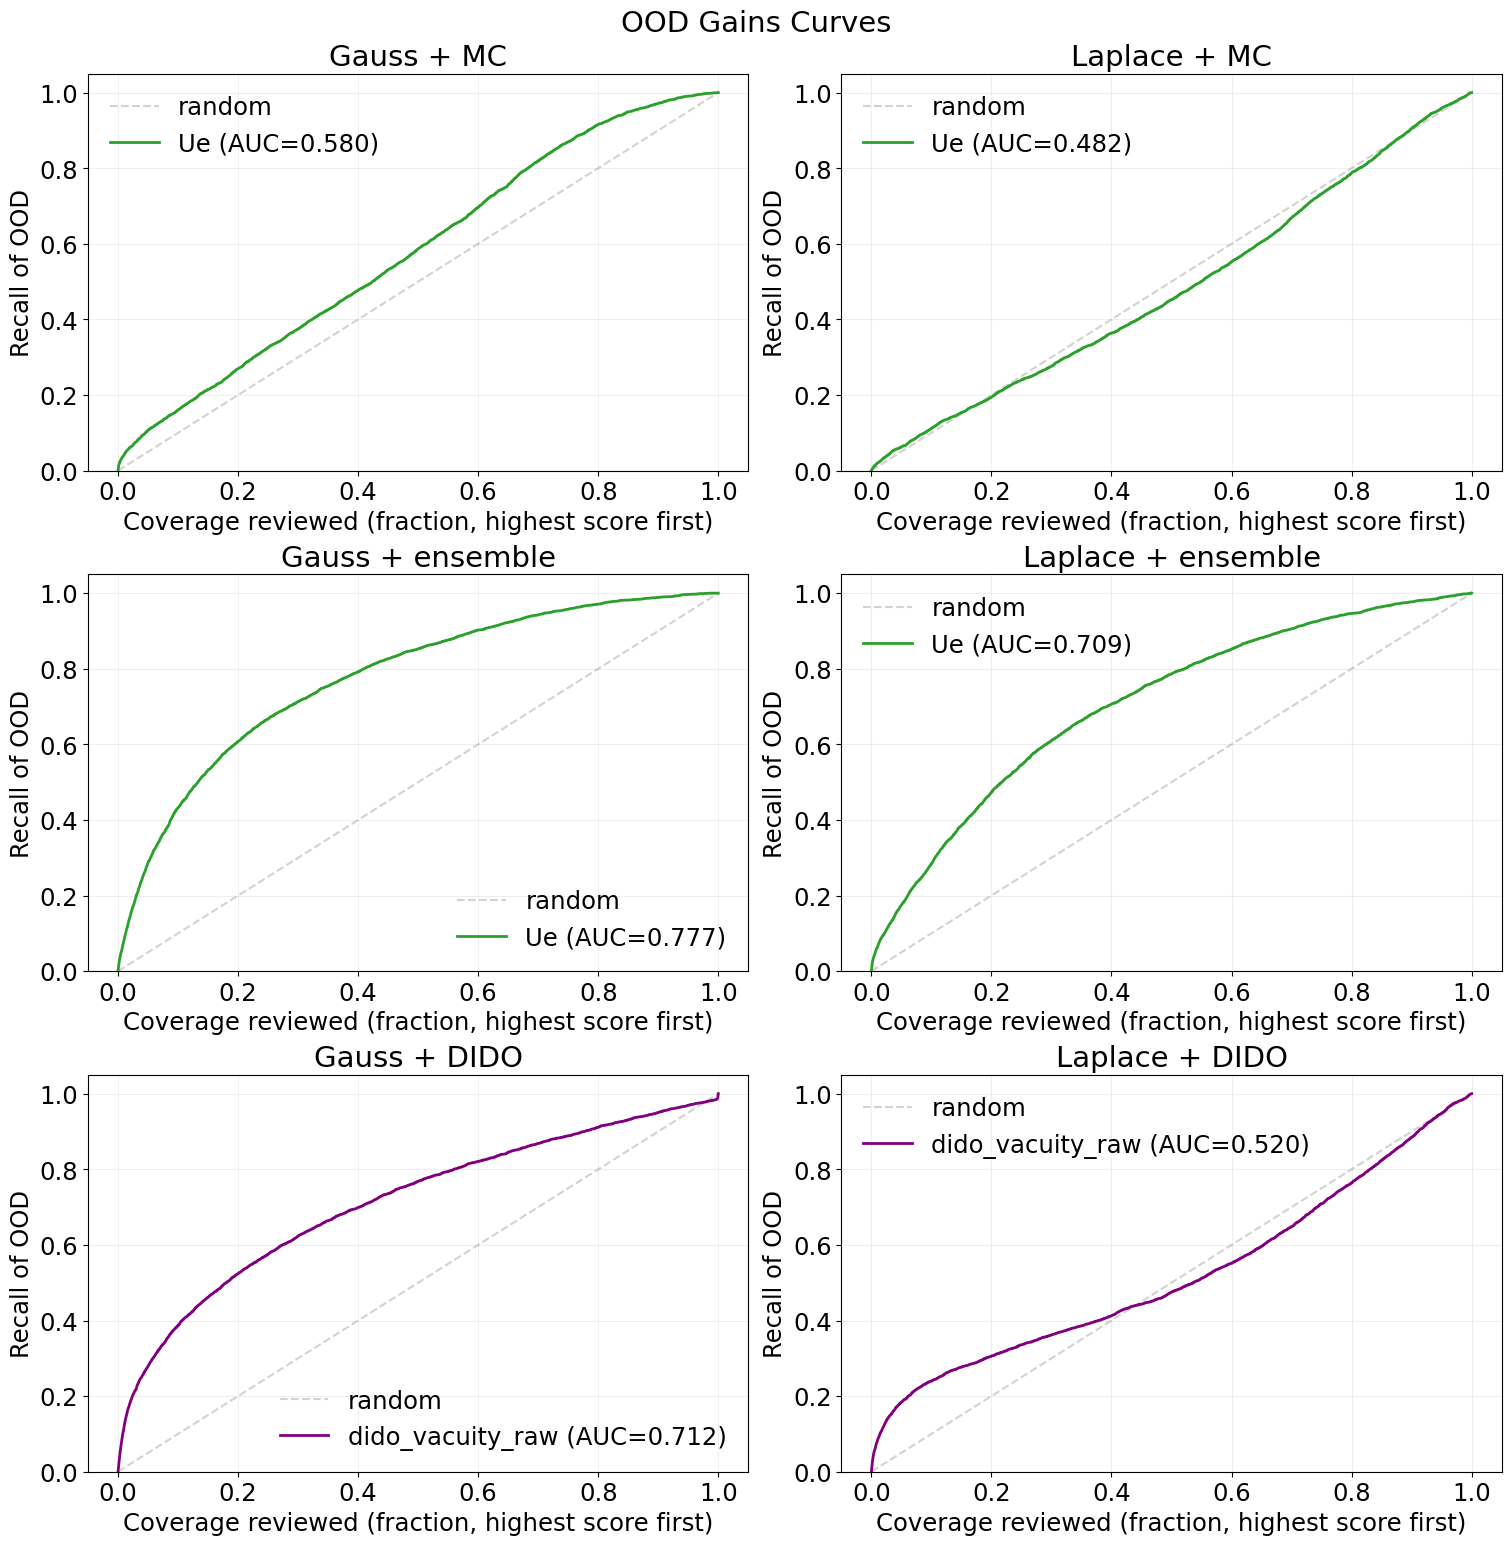

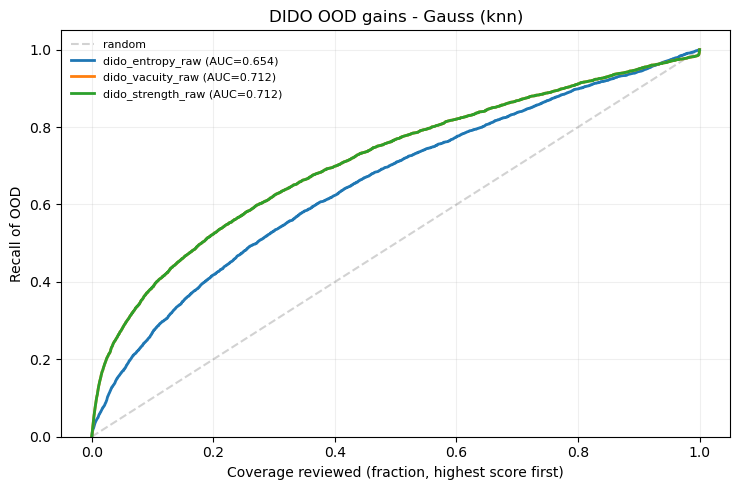

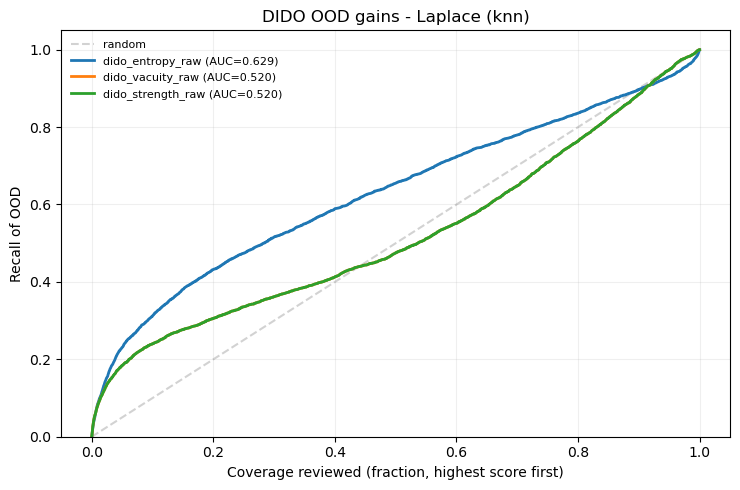

In [92]:
# Phase 5A3: OOD detection AUROC/AUPRC + gains curves

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

INCLUDE_ALEATORIC = False  # toggle Ua in OOD detection analysis
INCLUDE_NF = False  # toggle NF methods in plots/tables
SELECT_SIGNALS = (["Ua", "Ue", "Utot"] if INCLUDE_ALEATORIC else ["Ue"])

SIG_COLORS_LOCAL = (
    SIG_COLORS
    if "SIG_COLORS" in globals()
    else {"Ua": "tab:blue", "Ue": "tab:green", "Utot": "tab:orange", "blend": "tab:purple", "random": "0.5"}
)

INCLUDE_DIDO = True
DIDO_SIGNAL = settings.get("dido_signal", "dido_vacuity_raw")
DIDO_SIGNALS_CFG = settings.get("dido_signals", None)
DIDO_CANDIDATES = ["dido_entropy_raw", "dido_vacuity_raw", "dido_strength_raw"]
DIDO_ALLOW_FLIP = True
DIDO_COLOR = "purple"

DIDO_MAIN_SIGNAL_MODE = "selected"  # "selected" | "auto" | "all"
DIDO_MAIN_SIGNAL = "dido_vacuity_raw"

# ----------------- font scaling (ONLY used in OOD gains curves subplot grid) -----------------
FONT_SCALE = 1.75
from matplotlib.font_manager import FontProperties

def _to_points(v, fallback=10.0) -> float:
    try:
        return float(FontProperties(size=v).get_size_in_points())
    except Exception:
        try:
            return float(v)
        except Exception:
            return float(fallback)

_GAINS_TITLE_SIZE = _to_points(plt.rcParams.get("axes.titlesize", 12)) * FONT_SCALE
_GAINS_LABEL_SIZE = _to_points(plt.rcParams.get("axes.labelsize", 10)) * FONT_SCALE
_GAINS_TICK_SIZE = _to_points(plt.rcParams.get("xtick.labelsize", 10)) * FONT_SCALE
_GAINS_LEGEND_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10)) * FONT_SCALE
_GAINS_SUPTITLE_SIZE = _to_points(plt.rcParams.get("figure.titlesize", plt.rcParams.get("axes.titlesize", 12))) * FONT_SCALE
# --------------------------------------------------------------------------------------------


def _normalize_dido_signals(val):
    if val is None:
        return None
    if isinstance(val, str):
        v = val.strip()
        if v.lower() in {"auto", "all"}:
            return []
        return [s.strip() for s in v.split(",") if s.strip()]
    if isinstance(val, (list, tuple, set)):
        return [str(s).strip() for s in val if str(s).strip()]
    return None


def _label_candidates(label: str) -> list[str]:
    c = [label]
    if label.endswith("_hard"):
        c.append(label.replace("_hard", ""))
    return list(dict.fromkeys(c))


def _ood_metrics(y_true_bin: np.ndarray, score: np.ndarray):
    y_true_bin = np.asarray(y_true_bin, int)
    score = np.asarray(score, float)
    mask = np.isfinite(score) & np.isfinite(y_true_bin)
    if not np.any(mask):
        return float("nan"), float("nan"), 0
    y = y_true_bin[mask]
    s = score[mask]
    if len(np.unique(y)) < 2:
        return float("nan"), float("nan"), int(mask.sum())
    return float(roc_auc_score(y, s)), float(average_precision_score(y, s)), int(mask.sum())


def _gains_curve(y_ood: np.ndarray, score: np.ndarray):
    y_ood = np.asarray(y_ood, int)
    score = np.asarray(score, float)
    m = np.isfinite(score) & np.isfinite(y_ood)
    if not np.any(m):
        return None
    y = y_ood[m]
    s = score[m]
    if len(np.unique(y)) < 2:
        return None
    order = np.argsort(-s, kind="mergesort")
    y = y[order]
    total_pos = float(np.sum(y))
    if total_pos <= 0:
        return None
    cum_pos = np.cumsum(y).astype(float)
    recall = cum_pos / total_pos
    coverage = (np.arange(1, len(y) + 1) / float(len(y))).astype(float)
    auc = float(np.trapezoid(recall, coverage))
    return coverage, recall, auc


def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").to_numpy(float)
    miss_epi = ~np.isfinite(s_e_raw)
    s_e0 = np.nan_to_num(s_e_raw, nan=0.0)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        s_a, s_e, s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=s_e0,
        )
        s_e = np.asarray(s_e, float)
        s_e[miss_epi] = np.nan
        return np.asarray(s_a, float), s_e, np.asarray(s_t, float)

    s_a = np.asarray(s_a_raw, float)
    s_e = np.asarray(s_e_raw, float)
    s_t = np.sqrt(np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0))
    return s_a, s_e, s_t


def _load_ood_for_spec(spec: MethodSpec, ood_label: str) -> pd.DataFrame:
    last_err = None
    for lab in _label_candidates(ood_label):
        try:
            return method_ood_frame(spec, lab)
        except Exception as e:
            last_err = e
    raise last_err


# Include MC/ensemble + NF in the main method subplots
if INCLUDE_ALEATORIC:
    base_specs = [
        m for m in METHODS
        if (m.kind in {"regression", "ensemble"} and str(m.epistemic_source).lower() in {"mc", "ensemble"})
        or (m.kind == "nf")
    ]
else:
    base_specs = [m for m in METHODS if str(m.epistemic_source).lower() in {"mc", "ensemble"}]

if not INCLUDE_NF:
    base_specs = [m for m in base_specs if str(m.aleatoric_source).lower() != "nf" and m.kind != "nf"]

rows = []
gains_rows = []
dido_rows = []
dido_all_gains = []

dido_method_labels = {m.label for m in METHODS if m.kind == "dido"}

if DIDO_MAIN_SIGNAL_MODE == "selected":
    dido_signals = [DIDO_MAIN_SIGNAL]
elif DIDO_MAIN_SIGNAL_MODE == "all":
    dido_signals = []
else:
    dido_signals = _normalize_dido_signals(DIDO_SIGNALS_CFG)
    if dido_signals is None:
        dido_signals = _normalize_dido_signals(DIDO_SIGNAL)
    if dido_signals is None:
        dido_signals = []

for ood_label in OOD_LABELS_LOCAL:
    for spec in base_specs:
        try:
            df_id = method_id_frame(spec, "test")
            df_ood = _load_ood_for_spec(spec, ood_label)
            df_id, df_ood = apply_knn_bands(df_id, df_ood, ood_label, spec.key)
        except Exception as e:
            print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")
            continue

        df_id = df_id.copy()
        df_ood = df_ood.copy()
        df_id["is_ood"] = 0
        df_ood["is_ood"] = 1
        df_all = pd.concat([df_id, df_ood], ignore_index=True)
        ybin = df_all["is_ood"].to_numpy(int)

        s_a, s_e, s_t = _sigmas(spec, df_all)
        sig_map = {"Ua": s_a, "Ue": s_e, "Utot": s_t}

        for sig_name in SELECT_SIGNALS:
            score = sig_map[sig_name]
            _auroc, auprc, n_used = _ood_metrics(ybin, score)

            g = _gains_curve(ybin, score)
            auc = g[2] if g is not None else float("nan")

            rows.append({
                "ood_label": ood_label,
                "method": spec.label,
                "signal": sig_name,
                "n_id": int(len(df_id)),
                "n_ood": int(len(df_ood)),
                "n_used": n_used,
                "auc": auc,
                "auprc": auprc,
                "use_calibrated": bool(USE_CALIBRATED_SIGMAS_LOCAL),
            })

            if g is not None:
                cov, rec, auc = g
                gains_rows.append({
                    "ood_label": ood_label,
                    "method": spec.label,
                    "signal": sig_name,
                    "coverage": cov,
                    "recall": rec,
                    "auc": auc,
                })

    if INCLUDE_DIDO:
        dido_specs = [m for m in METHODS if m.kind == "dido"]
        for dido_spec in dido_specs:
            try:
                df_id_d = method_id_frame(dido_spec, "test")
                df_ood_d = _load_ood_for_spec(dido_spec, ood_label)
                df_id_d, df_ood_d = apply_knn_bands(df_id_d, df_ood_d, ood_label, dido_spec.key)
            except Exception as e:
                print(f"[skip] {dido_spec.label} / ood={ood_label}: {type(e).__name__}: {e}")
                continue

            df_id_d = df_id_d.copy()
            df_ood_d = df_ood_d.copy()
            df_id_d["is_ood"] = 0
            df_ood_d["is_ood"] = 1
            df_all_d = pd.concat([df_id_d, df_ood_d], ignore_index=True)
            ybin = df_all_d["is_ood"].to_numpy(int)

            if dido_signals:
                dido_cols = [c for c in dido_signals if c in df_all_d.columns]
            else:
                dido_cols = [c for c in DIDO_CANDIDATES if c in df_all_d.columns]

            if not dido_cols:
                print(f"[skip] {dido_spec.label} / ood={ood_label}: dido column not found")
                continue

            dido_cols_all = [c for c in DIDO_CANDIDATES if c in df_all_d.columns]

            for col in dido_cols:
                score0 = pd.to_numeric(df_all_d[col], errors="coerce").to_numpy(float)
                _auroc, auprc, n_used = _ood_metrics(ybin, score0)
                score_used = score0
                if DIDO_ALLOW_FLIP:
                    auroc_neg, auprc_neg, _ = _ood_metrics(ybin, -score0)
                    if np.isfinite(auroc_neg) and (not np.isfinite(_auroc) or auroc_neg > _auroc):
                        _auroc, auprc = auroc_neg, auprc_neg
                        score_used = -score0

                g = _gains_curve(ybin, score_used)
                auc = g[2] if g is not None else float("nan")

                sig_name = col
                dido_rows.append({
                    "ood_label": ood_label,
                    "method": dido_spec.label,
                    "signal": sig_name,
                    "n_id": int(len(df_id_d)),
                    "n_ood": int(len(df_ood_d)),
                    "n_used": int(n_used),
                    "auc": auc,
                    "auprc": auprc,
                    "use_calibrated": False,
                })

                if g is not None:
                    cov, rec, auc = g
                    gains_rows.append({
                        "ood_label": ood_label,
                        "method": dido_spec.label,
                        "signal": sig_name,
                        "coverage": cov,
                        "recall": rec,
                        "auc": auc,
                    })

            for col in dido_cols_all:
                score0 = pd.to_numeric(df_all_d[col], errors="coerce").to_numpy(float)
                score_used = score0
                sig_name = col
                if DIDO_ALLOW_FLIP:
                    auroc_pos, _auprc_pos, _ = _ood_metrics(ybin, score0)
                    auroc_neg, _auprc_neg, _ = _ood_metrics(ybin, -score0)
                    if np.isfinite(auroc_neg) and (not np.isfinite(auroc_pos) or auroc_neg > auroc_pos):
                        score_used = -score0
                g = _gains_curve(ybin, score_used)
                if g is not None:
                    cov, rec, auc = g
                    dido_all_gains.append({
                        "ood_label": ood_label,
                        "head_type": dido_spec.head_type,
                        "signal": sig_name,
                        "coverage": cov,
                        "recall": rec,
                        "auc": auc,
                    })

if rows or dido_rows:
    df_ooddet = pd.DataFrame(rows + dido_rows)
    EXPORTER.export_table(df_ooddet, f"ood_detection_full_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split="test")
    display(df_ooddet.sort_values(["ood_label", "auc"], ascending=[True, False]).reset_index(drop=True))

    for ood_label in OOD_LABELS_LOCAL:
        sub = df_ooddet[df_ooddet["ood_label"] == ood_label].copy()
        sub = sub[np.isfinite(sub["auc"].to_numpy(float))].copy()
        if sub.empty:
            continue
        sub["name"] = sub["method"] + " / " + sub["signal"]
        sub = sub.sort_values("auc", ascending=True)

        fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(sub))))
        y = np.arange(len(sub))
        vals = sub["auc"].to_numpy(float)
        ax.barh(y, vals, alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["name"].tolist())
        ax.set_xlabel("AUC (coverage-recall)")
        ax.set_title(
            f"OOD Detection AUC"
        )
        ax.grid(True, axis="x", alpha=0.2)
        ax.ticklabel_format(style="plain", axis="x", useOffset=False)
        xmax = float(vals.max()) if len(vals) else 0.0
        pad = 0.02 * xmax
        for yi, v in zip(y, vals):
            ax.text(max(v - pad, 0.0), yi, f"{v:.3f}", va="center", ha="right", fontsize=9, color="white")
        fig.tight_layout()
        fig.subplots_adjust(left=0.45)
        savefig(fig, f"ood_detection_auc_{ood_label}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split="test")
        plt.show()

    gains_map = {(r["ood_label"], r["method"], r["signal"]): (r["coverage"], r["recall"], r["auc"]) for r in gains_rows}
    method_head = {m.label: m.head_type for m in METHODS}

    for ood_label in OOD_LABELS_LOCAL:
        methods = sorted({m for (ol, m, _s) in gains_map.keys() if ol == ood_label})
        if not methods:
            continue

        gauss_methods = [m for m in methods if method_head.get(m) == "gauss" and m not in dido_method_labels]
        laplace_methods = [m for m in methods if method_head.get(m) == "laplace" and m not in dido_method_labels]

        dido_gauss = [m for m in methods if method_head.get(m) == "gauss" and m in dido_method_labels]
        dido_laplace = [m for m in methods if method_head.get(m) == "laplace" and m in dido_method_labels]

        nrows = max(len(gauss_methods), len(laplace_methods))
        if INCLUDE_DIDO and (dido_gauss or dido_laplace):
            nrows += 1  # bottom row reserved for DIDO

        ncols = 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(7.5 * ncols, 5.0 * max(nrows, 1)), sharex=False, sharey=False, constrained_layout=True)
        axes = np.atleast_2d(axes)

        def _plot_method(ax, method):
            ax.plot([0, 1], [0, 1], "--", alpha=0.35, color=SIG_COLORS_LOCAL.get("random", "0.5"), label="random")
            sigs_here = [sig for (ol, m, sig) in gains_map.keys() if (ol == ood_label and m == method)]
            for sig in sigs_here:
                cov, rec, auc = gains_map[(ood_label, method, sig)]
                color = DIDO_COLOR if method in dido_method_labels else SIG_COLORS_LOCAL.get(sig, None)
                ax.plot(cov, rec, lw=2, color=color, label=f"{sig} (AUC={auc:.3f})")

            # ---- font scaling applies ONLY to this OOD gains curves subplot grid ----
            ax.set_title(method, fontsize=_GAINS_TITLE_SIZE)
            ax.set_xlabel("Coverage reviewed (fraction, highest score first)", fontsize=_GAINS_LABEL_SIZE)
            ax.set_ylabel("Recall of OOD", fontsize=_GAINS_LABEL_SIZE)
            ax.tick_params(axis="both", which="both", labelsize=_GAINS_TICK_SIZE)
            ax.set_ylim(0, 1.05)
            ax.grid(True, alpha=0.2)
            ax.legend(frameon=False, fontsize=_GAINS_LEGEND_SIZE)

        # main rows
        for r in range(nrows - (1 if INCLUDE_DIDO and (dido_gauss or dido_laplace) else 0)):
            if r < len(gauss_methods):
                _plot_method(axes[r, 0], gauss_methods[r])
            else:
                axes[r, 0].set_axis_off()

            if r < len(laplace_methods):
                _plot_method(axes[r, 1], laplace_methods[r])
            else:
                axes[r, 1].set_axis_off()

        # bottom DIDO row
        if INCLUDE_DIDO and (dido_gauss or dido_laplace):
            r = nrows - 1
            if dido_gauss:
                _plot_method(axes[r, 0], dido_gauss[0])
            else:
                axes[r, 0].set_axis_off()

            if dido_laplace:
                _plot_method(axes[r, 1], dido_laplace[0])
            else:
                axes[r, 1].set_axis_off()

        fig.suptitle(
            f"OOD Gains Curves",
            y=1.02,
            fontsize=_GAINS_SUPTITLE_SIZE,
        )
        savefig(fig, f"ood_gains_curves_{ood_label}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split="test")
        plt.show()

    # DIDO gains: one figure for Gauss (all signals), one for Laplace (all signals)
    if dido_all_gains:
        for ood_label in OOD_LABELS_LOCAL:
            for head in ["gauss", "laplace"]:
                dido_here = [g for g in dido_all_gains if g["ood_label"] == ood_label and g["head_type"] == head]
                if not dido_here:
                    continue
                fig, ax = plt.subplots(figsize=(7.5, 5))
                ax.plot([0, 1], [0, 1], "--", alpha=0.35, color="0.5", label="random")
                for g in dido_here:
                    ax.plot(g["coverage"], g["recall"], lw=2, label=f"{g['signal']} (AUC={g['auc']:.3f})")
                ax.set_xlabel("Coverage reviewed (fraction, highest score first)")
                ax.set_ylabel("Recall of OOD")
                ax.set_ylim(0, 1.05)
                ax.grid(True, alpha=0.2)
                ax.legend(frameon=False, fontsize=8)
                ax.set_title(f"DIDO OOD gains - {head.capitalize()} ({ood_label})")
                fig.tight_layout()
                # savefig(fig, f"dido_ood_gains_{head}_{ood_label}", dataset=DATASET_KEY, split="test")
                plt.show()

else:
    print("[OOD detection] No rows to plot.")


,method,key,signal,scope,auc
0,Laplace (NF) + ensemble,nf_lpl_ensemble,Ua,id_test+ood,0.784634
1,Laplace (NF) + MC,nf_lpl_mc,Ua,id_test+ood,0.782701
2,Laplace (NF),nf_lpl,Ua,id_test+ood,0.777871
3,Gauss (NF) + MC,nf_gau_mc,Ua,id_test+ood,0.766886
4,Laplace (NF) + ensemble,nf_lpl_ensemble,Ue,id_test+ood,0.766714
5,Laplace + ensemble,esm_lpl,Ue,id_test+ood,0.766714
6,Gauss + ensemble,esm_gau,Ua,id_test+ood,0.764995
7,Gauss (NF) + ensemble,nf_gau_ensemble,Ua,id_test+ood,0.763604
8,Laplace + ensemble,esm_lpl,Ua,id_test+ood,0.758741
9,Laplace + MC,lpl_mc,Ua,id_test+ood,0.758299


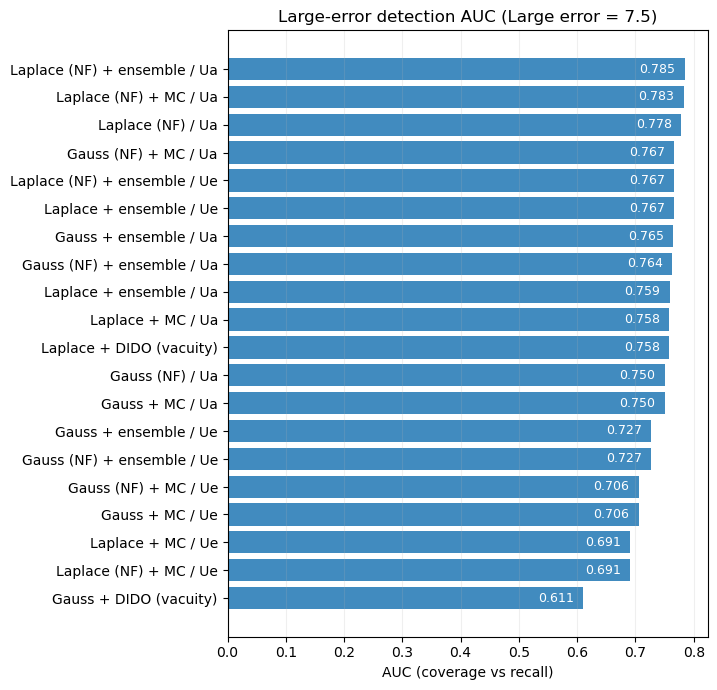

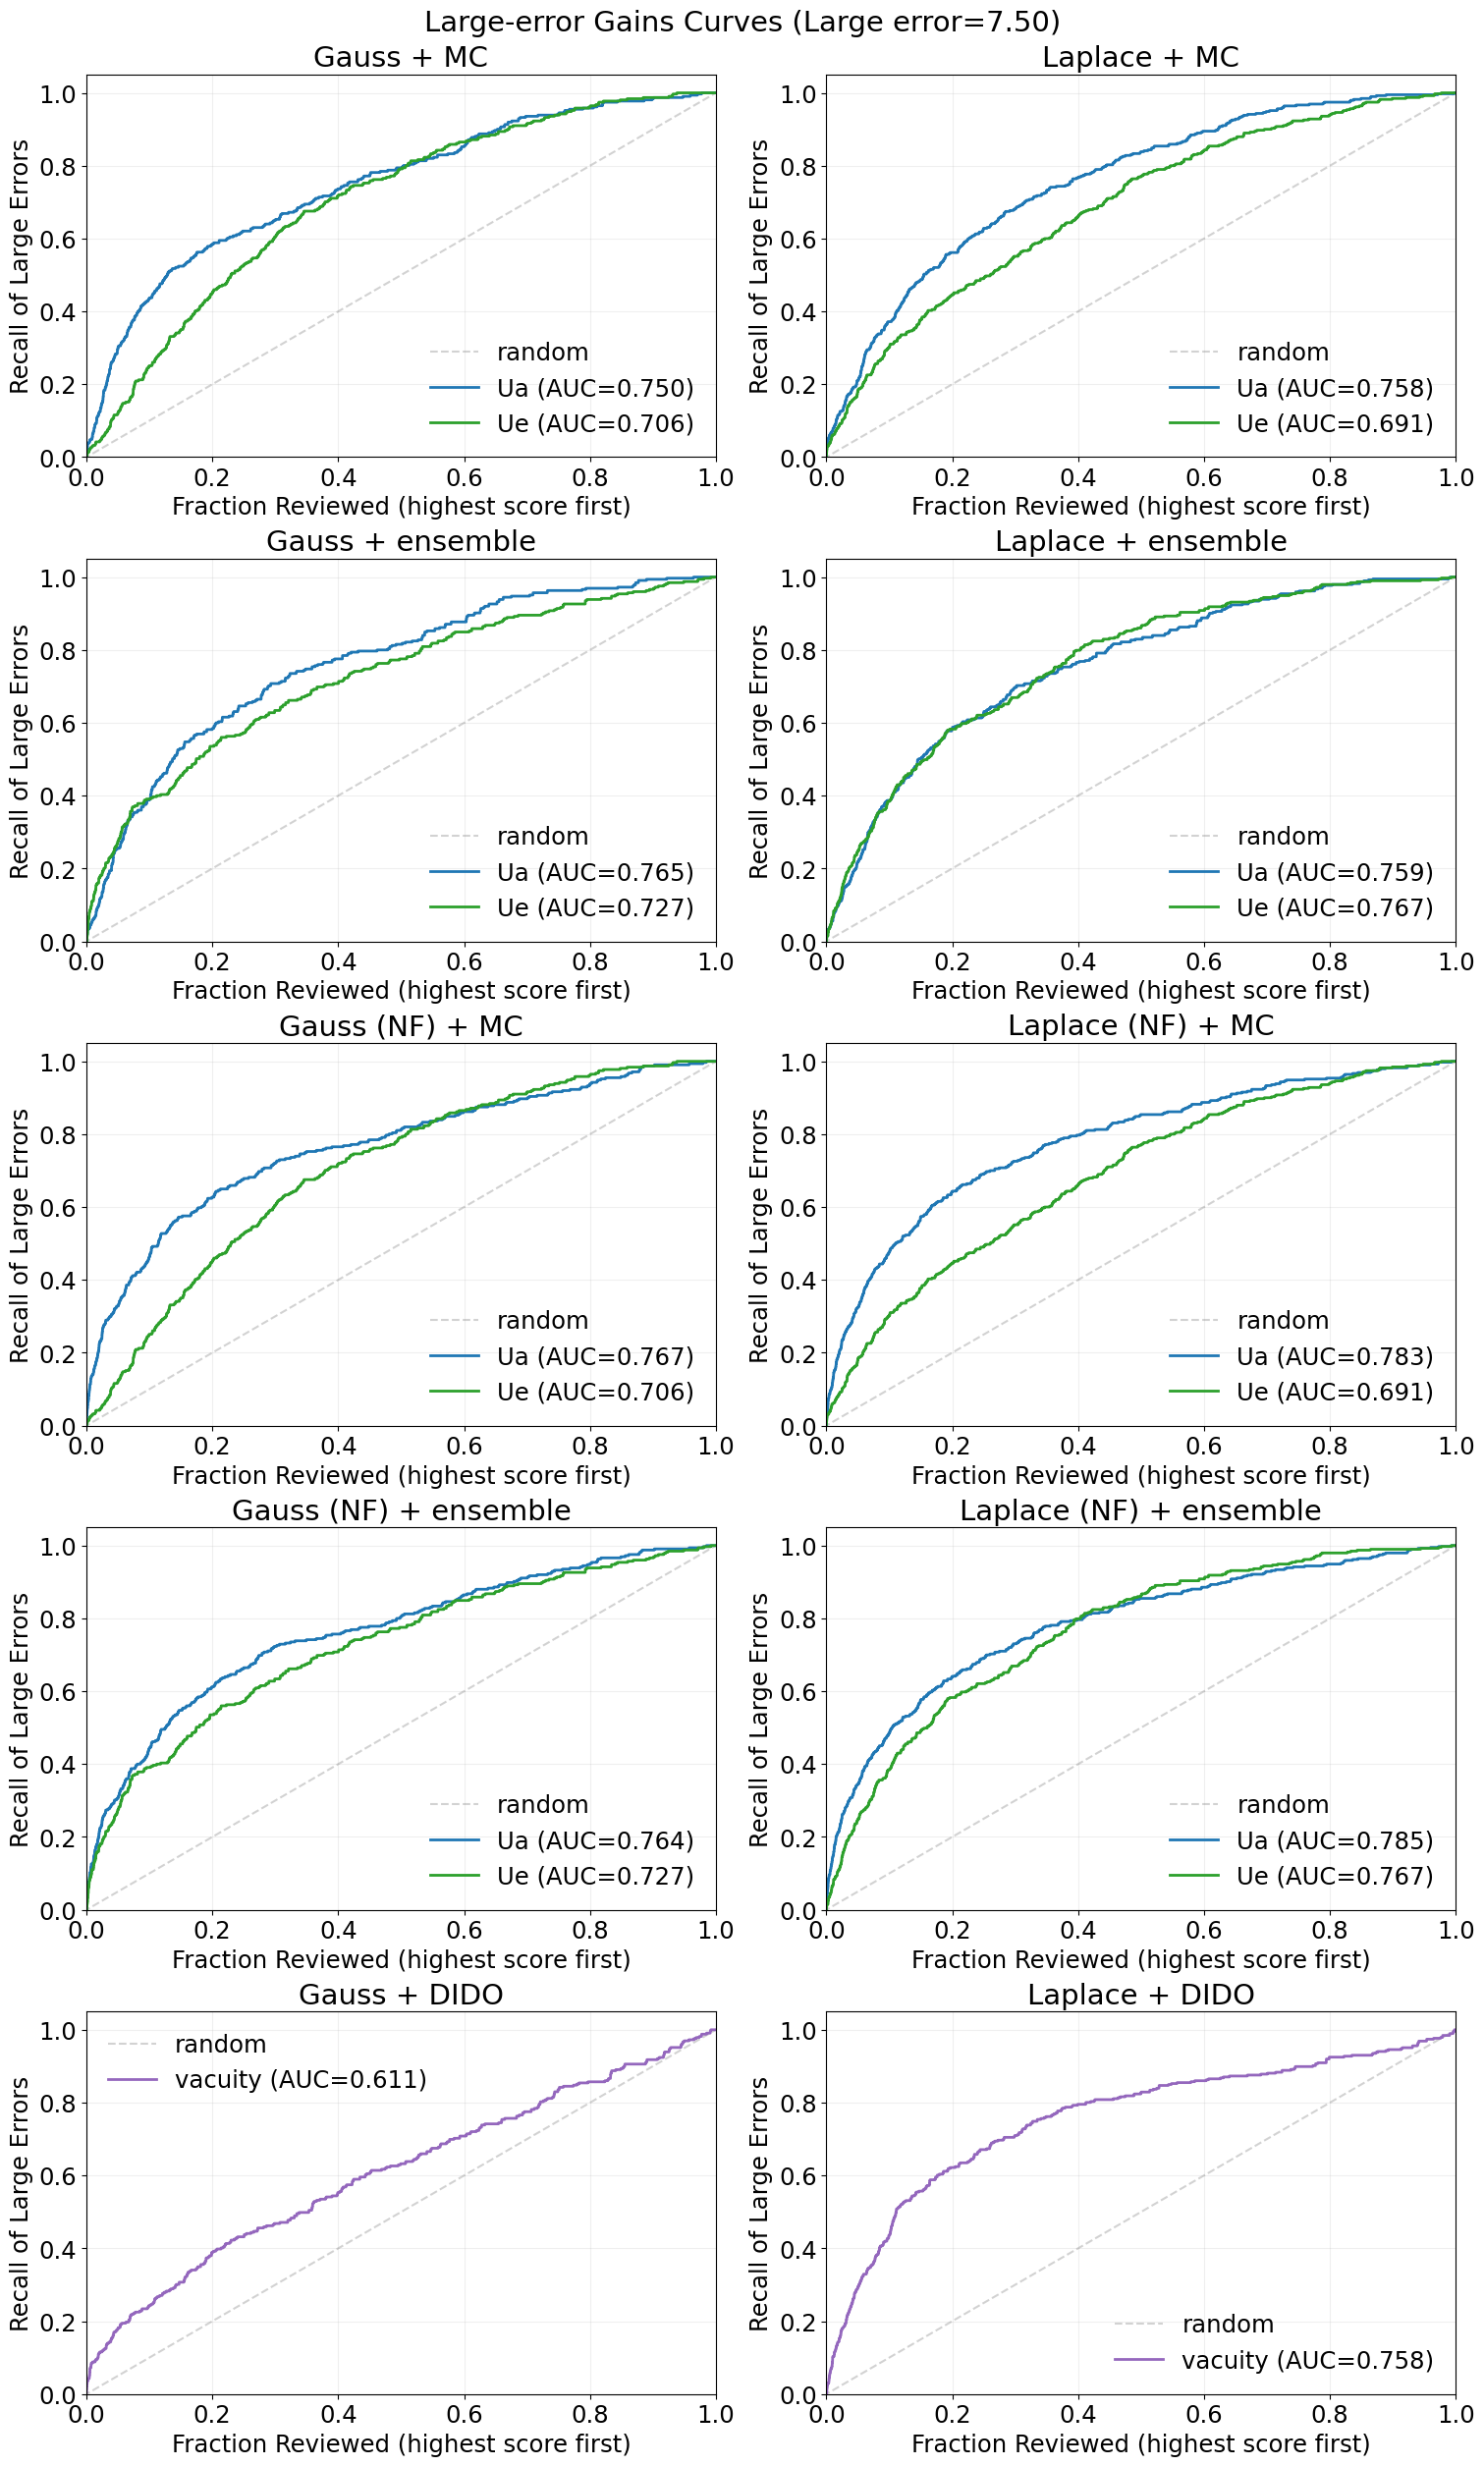

In [93]:
# Phase 5C+5D (MERGED): large-error AUC + gains curves (consistent AUC for table + plots)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- toggles (set here) -----------------
USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

# Scope matches former 5D
EVAL_SCOPE_LOCAL = "id_test+ood"  # "id_test" | "id_test+ood"

# Signals to rank by (former 5C/5D)
LARGE_ERROR_SIGNALS = ["Ua", "Ue"]  # any subset of {"Ua","Ue","Utot"}

# NF methods (former 5D)
INCLUDE_NF_SIGNALS = True  # include NF variants/methods

# Keep/skip methods that only have Ua available (former 5D)
ALLOW_ALEATORIC_ONLY = False

# DIDO (former 5C/5D)
INCLUDE_DIDO = True
DIDO_LARGE_SIGNAL = "dido_vacuity_raw"  # "dido_vacuity_raw" | "dido_strength_raw" | "dido_entropy_raw"
DIDO_ALLOW_FLIP = True                 # if True, will use -score if it improves AUC
DIDO_COLOR = "tab:purple"

# Plot layout (former 5D)
N_COLS = 2  # kept, but gauss/laplace layout forces 2 columns

SIG_COLORS_LOCAL = (
    SIG_COLORS
    if "SIG_COLORS" in globals()
    else {"Ua": "tab:blue", "Ue": "tab:green", "Utot": "tab:orange", "random": "0.5"}
)
# ------------------------------------------------------

try:
    TAU_LOCAL = float(TAU)
except Exception as e:
    raise RuntimeError("TAU not defined; run the large-error threshold cell first.") from e

OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

# ----------------- font scaling (ONLY used in Large-error gains curves subplot grid) -----------------
FONT_SCALE = 1.75
from matplotlib.font_manager import FontProperties

def _to_points(v, fallback=10.0) -> float:
    try:
        return float(FontProperties(size=v).get_size_in_points())
    except Exception:
        try:
            return float(v)
        except Exception:
            return float(fallback)

_GAINS_TITLE_SIZE = _to_points(plt.rcParams.get("axes.titlesize", 12)) * FONT_SCALE
_GAINS_LABEL_SIZE = _to_points(plt.rcParams.get("axes.labelsize", 10)) * FONT_SCALE
_GAINS_TICK_SIZE = _to_points(plt.rcParams.get("xtick.labelsize", 10)) * FONT_SCALE
_GAINS_LEGEND_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10)) * FONT_SCALE
_GAINS_SUPTITLE_SIZE = _to_points(plt.rcParams.get("figure.titlesize", plt.rcParams.get("axes.titlesize", 12))) * FONT_SCALE
# ------------------------------------------------------------------------------------------------------


def _col_to_numpy(df: pd.DataFrame, col: str, fill_nan: float | None = None) -> np.ndarray:
    if col not in df.columns:
        out = np.full(len(df), np.nan, dtype=float)
    else:
        out = pd.to_numeric(df[col], errors="coerce").to_numpy(float)
    if fill_nan is not None:
        out = np.nan_to_num(out, nan=float(fill_nan))
    return out


def _auc_curve(y_bin: np.ndarray, score: np.ndarray):
    y_bin = np.asarray(y_bin, int)
    score = np.asarray(score, float)
    m = np.isfinite(score) & np.isfinite(y_bin)
    if not np.any(m):
        return None
    y = y_bin[m]
    s = score[m]
    if np.unique(y).size < 2:
        return None
    order = np.argsort(-s, kind="mergesort")
    y = y[order]
    total_pos = float(np.sum(y))
    if total_pos <= 0:
        return None
    cum_pos = np.cumsum(y).astype(float)
    recall = cum_pos / total_pos
    coverage = (np.arange(1, len(y) + 1) / float(len(y))).astype(float)
    auc = float(np.trapezoid(recall, coverage))
    return coverage, recall, auc


def _sigmas(spec: "MethodSpec", df: pd.DataFrame):
    s_a_raw = _col_to_numpy(df, "sigma_ale_raw")
    s_e_raw = _col_to_numpy(df, "sigma_epi_raw")
    miss_epi = ~np.isfinite(s_e_raw)
    s_e0 = np.nan_to_num(s_e_raw, nan=0.0)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        s_a, s_e, s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=s_e0,
        )
        s_e = np.asarray(s_e, float)
        s_e[miss_epi] = np.nan
        return np.asarray(s_a, float), s_e, np.asarray(s_t, float)

    s_a = np.asarray(s_a_raw, float)
    s_e = np.asarray(s_e_raw, float)
    s_t = np.sqrt(np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0))
    return s_a, s_e, s_t


def _load_for_scope(spec: "MethodSpec") -> pd.DataFrame:
    parts = []
    df_id = method_id_frame(spec, "test").copy()
    df_id["dataset"] = "id:test"
    parts.append(df_id)

    if EVAL_SCOPE_LOCAL.strip().lower() == "id_test+ood":
        for ood_label in OOD_LABELS_LOCAL:
            try:
                df_o = method_ood_frame(spec, ood_label).copy()
                df_o["dataset"] = f"ood:{ood_label}"
                parts.append(df_o)
            except Exception as e:
                print(f"[skip scope] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")

    return pd.concat(parts, ignore_index=True)


def _short_dido_signal(col: str) -> str:
    c = str(col).replace("dido_", "")
    for suf in ("_raw", "_cal"):
        if c.endswith(suf):
            c = c[: -len(suf)]
    return c


def _is_nf_method(m: "MethodSpec") -> bool:
    return str(getattr(m, "aleatoric_source", "")).lower() == "nf" or getattr(m, "kind", None) == "nf"


# ----------------------------
# Resolve which signals to use
# ----------------------------
LARGE_ERROR_SIGNALS = [str(s).strip() for s in LARGE_ERROR_SIGNALS if str(s).strip()]
VALID_LARGE_ERROR_SIGNALS = {"Ua", "Ue", "Utot"}
LARGE_ERROR_SIGNALS = [s for s in LARGE_ERROR_SIGNALS if s in VALID_LARGE_ERROR_SIGNALS]
if not LARGE_ERROR_SIGNALS:
    LARGE_ERROR_SIGNALS = ["Ue"]

# ----------------------------
# Select non-DIDO specs
# ----------------------------
specs = []
for m in METHODS:
    if m.kind == "dido" or m.head_type == "point":
        continue
    if (not INCLUDE_NF_SIGNALS) and _is_nf_method(m):
        continue
    if str(m.epistemic_source).lower() in {"mc", "ensemble"} or _is_nf_method(m):
        specs.append(m)

# Dedup by label (matches your pattern elsewhere)
seen = set()
specs = [m for m in specs if (m.label not in seen and not seen.add(m.label))]

# ----------------------------
# Compute curves once, reuse AUC for table + plots
# ----------------------------
rows = []            # for bar/table
plot_items = []      # for gains subplots

for spec in specs:
    try:
        df_all = _load_for_scope(spec)
    except Exception as e:
        print(f"[skip large merged] {spec.label}: {type(e).__name__}: {e}")
        continue

    if "y_true" not in df_all.columns or "mu" not in df_all.columns:
        continue

    y = _col_to_numpy(df_all, "y_true")
    mu = _col_to_numpy(df_all, "mu")
    abs_err = np.abs(y - mu)
    y_large = (abs_err > TAU_LOCAL).astype(int)

    s_a, s_e, s_t = _sigmas(spec, df_all)
    has_epi = str(spec.epistemic_source).lower() in {"mc", "ensemble"}

    # per-signal AUC uses per-signal finite mask (matches 5C style)
    sig_map = {"Ua": s_a, "Ue": s_e, "Utot": s_t}

    curves = {}
    for sig_name in LARGE_ERROR_SIGNALS:
        if sig_name == "Ue" and (not has_epi):
            continue

        score = np.asarray(sig_map[sig_name], float)
        g = _auc_curve(y_large, score)
        if g is None:
            continue
        cov, rec, auc = g
        curves[sig_name] = (cov, rec, auc)

        rows.append({
            "method": spec.label,
            "key": spec.key,
            "signal": sig_name,
            "scope": EVAL_SCOPE_LOCAL,
            "auc": auc,
        })

    if not curves:
        continue
    if (not ALLOW_ALEATORIC_ONLY) and set(curves.keys()) == {"Ua"}:
        continue

    plot_items.append({
        "title": spec.label,
        "key": spec.key,
        "curves": curves,
        "is_dido": False,
        "head": str(getattr(spec, "head_type", "")).lower(),
    })

# ----------------------------
# DIDO (compute large-error label from matching base-head predictions)
# ----------------------------
if INCLUDE_DIDO:
    dido_specs = [m for m in METHODS if m.kind == "dido" and str(m.head_type).lower() in {"gauss", "laplace"}]

    # find base analytic specs (used only to compute y_true/mu and is_large)
    base_by_head = {}
    for head in ("gauss", "laplace"):
        base = None
        for m in METHODS:
            if m.kind == "dido" or m.head_type == "point":
                continue
            if str(m.head_type).lower() != head:
                continue
            if str(m.epistemic_source).lower() == "none" and str(m.aleatoric_source).lower() == "analytic":
                base = m
                break
        if base is None:
            for m in METHODS:
                if m.kind == "dido" or m.head_type == "point":
                    continue
                if str(m.head_type).lower() == head:
                    base = m
                    break
        if base is not None:
            base_by_head[head] = base
        else:
            print(f"[warn] No base spec found for head_type={head}; DIDO({head}) will be skipped.")

    for dido_spec in dido_specs:
        head = str(dido_spec.head_type).lower()
        base = base_by_head.get(head)
        if base is None:
            continue

        try:
            df_dido = _load_for_scope(dido_spec)
        except Exception as e:
            print(f"[skip DIDO merged] {dido_spec.label}: {type(e).__name__}: {e}")
            continue

        if "id" not in df_dido.columns or DIDO_LARGE_SIGNAL not in df_dido.columns:
            print(f"[skip DIDO merged] {dido_spec.label}: missing id or {DIDO_LARGE_SIGNAL}")
            continue

        try:
            df_base = _load_for_scope(base)
        except Exception as e:
            print(f"[skip DIDO merged] base={base.label}: {type(e).__name__}: {e}")
            continue

        if "id" not in df_base.columns or "y_true" not in df_base.columns or "mu" not in df_base.columns:
            print(f"[skip DIDO merged] base={base.label}: missing id/y_true/mu")
            continue

        dido_small = pd.DataFrame({
            "id": pd.to_numeric(df_dido["id"], errors="coerce"),
            "dataset": df_dido.get("dataset", "id:test"),
            "dido_score": pd.to_numeric(df_dido[DIDO_LARGE_SIGNAL], errors="coerce"),
        }).dropna(subset=["id"])
        dido_small["id"] = dido_small["id"].astype(int)

        base_small = pd.DataFrame({
            "id": pd.to_numeric(df_base["id"], errors="coerce"),
            "dataset": df_base.get("dataset", "id:test"),
            "y_true": pd.to_numeric(df_base["y_true"], errors="coerce"),
            "mu": pd.to_numeric(df_base["mu"], errors="coerce"),
        }).dropna(subset=["id"])
        base_small["id"] = base_small["id"].astype(int)

        merged = dido_small.merge(base_small, on=["id", "dataset"], how="inner")
        if merged.empty:
            print(f"[skip DIDO merged] {dido_spec.label}: no matching ids after join with base={base.label}")
            continue

        abs_err = np.abs(merged["y_true"].to_numpy(float) - merged["mu"].to_numpy(float))
        y_large = (abs_err > TAU_LOCAL).astype(int)

        score0 = merged["dido_score"].to_numpy(float)
        g = _auc_curve(y_large, score0)
        if DIDO_ALLOW_FLIP:
            g_neg = _auc_curve(y_large, -score0)
            if g is None and g_neg is not None:
                g = g_neg
            elif g is not None and g_neg is not None and np.isfinite(g_neg[2]) and (not np.isfinite(g[2]) or g_neg[2] > g[2]):
                g = g_neg

        if g is None:
            continue

        cov, rec, auc = g
        sig_short = _short_dido_signal(DIDO_LARGE_SIGNAL)
        method_short = f"{('Gauss' if head == 'gauss' else 'Laplace')} + DIDO"

        rows.append({
            "method": method_short,
            "key": dido_spec.key,
            "signal": sig_short,
            "scope": EVAL_SCOPE_LOCAL,
            "auc": auc,
        })

        plot_items.append({
            "title": method_short,
            "key": dido_spec.key,
            "curves": {sig_short: (cov, rec, auc)},
            "is_dido": True,
            "head": head,
        })

# ----------------------------
# Table + bar plot (uses same AUC as gains curves)
# ----------------------------
if not rows:
    print("[large merged] No rows to plot.")
else:
    df_large = pd.DataFrame(rows).copy()
    df_large["auc"] = pd.to_numeric(df_large["auc"], errors="coerce")
    df_large = df_large[np.isfinite(df_large["auc"])].copy()
    df_large = df_large.sort_values("auc", ascending=False).reset_index(drop=True)

    EXPORTER.export_table(
        df_large,
        f"large_error_auroc_{EVAL_SCOPE_LOCAL}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
        dataset=DATASET_KEY,
        split="test",
    )
    display(df_large)

    is_dido_row = df_large["method"].astype(str).str.contains("DIDO", na=False)
    df_large["name"] = np.where(
        is_dido_row,
        df_large["method"] + " (" + df_large["signal"].astype(str) + ")",
        df_large["method"] + " / " + df_large["signal"].astype(str),
    )

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(df_large))))
    y = np.arange(len(df_large))
    vals = df_large["auc"].to_numpy(float)
    ax.barh(y, vals, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(df_large["name"].tolist())
    ax.invert_yaxis()
    ax.set_xlabel("AUC (coverage vs recall)")
    ax.set_title(f"Large-error detection AUC (Large error = {TAU_LOCAL:.1f})")
    ax.grid(True, axis="x", alpha=0.2)
    ax.ticklabel_format(style="plain", axis="x", useOffset=False)

    xmax = float(np.nanmax(vals)) if len(vals) else 0.0
    pad = 0.02 * xmax if xmax > 0 else 0.01
    for yi, v in zip(y, vals):
        if np.isfinite(v):
            ax.text(max(v - pad, 0.0), yi, f"{v:.3f}", va="center", ha="right", fontsize=9, color="white")

    fig.tight_layout()
    fig.subplots_adjust(left=0.45)
    savefig(
        fig,
        f"large_error_auroc_{EVAL_SCOPE_LOCAL}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
        dataset=DATASET_KEY,
        split="test",
    )
    plt.show()

# ----------------------------
# Gains curves (uses the exact same stored AUC)
# ----------------------------
if not plot_items:
    print("[large merged] No curves to plot.")
else:
    gauss_items = [it for it in plot_items if str(it.get("head", "")).lower().startswith("gauss")]
    laplace_items = [it for it in plot_items if str(it.get("head", "")).lower().startswith("laplace")]

    nrows = int(max(len(gauss_items), len(laplace_items)))
    if nrows == 0:
        print("[large merged] No gauss/laplace curves to plot.")
    else:
        fig, axes = plt.subplots(
            nrows,
            2,
            figsize=(7.5 * 2, 5.0 * nrows),
            sharex=False,
            sharey=False,
            constrained_layout=True,
        )
        axes = np.atleast_2d(axes)

        for r in range(nrows):
            for c, items in enumerate((gauss_items, laplace_items)):
                ax = axes[r, c]
                if r >= len(items):
                    ax.set_axis_off()
                    continue

                item = items[r]
                ax.plot([-0.05, 1.05], [-0.05, 1.05], linestyle="--", alpha=0.35, color=SIG_COLORS_LOCAL.get("random", "0.5"), label="random")

                for name, (cov, rec, auc) in item["curves"].items():
                    color = DIDO_COLOR if item.get("is_dido", False) else SIG_COLORS_LOCAL.get(name, None)
                    ax.plot(cov, rec, lw=2, color=color, label=f"{name} (AUC={auc:.3f})")

                # ---- font scaling applies ONLY to this Large-error gains curves subplot grid ----
                ax.set_title(item["title"], fontsize=_GAINS_TITLE_SIZE)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1.05)
                ax.grid(True, alpha=0.2)
                ax.tick_params(axis="both", which="both", labelsize=_GAINS_TICK_SIZE)
                ax.legend(frameon=False, fontsize=_GAINS_LEGEND_SIZE)

                ax.set_xlabel("Fraction Reviewed (highest score first)", fontsize=_GAINS_LABEL_SIZE)
                ax.set_ylabel("Recall of Large Errors", fontsize=_GAINS_LABEL_SIZE)

        fig.suptitle(f"Large-error Gains Curves (Large error={TAU_LOCAL:.2f})", fontsize=_GAINS_SUPTITLE_SIZE)
        savefig(
            fig,
            f"large_error_gains_{EVAL_SCOPE_LOCAL}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
            dataset=DATASET_KEY,
            split="test",
        )
        plt.show()


## Phase 6: OOD predictive quality + ID vs OOD metrics

Compute MAE/CRPS on OOD and compare ID:test vs OOD side-by-side.

,ood_label,method,key,head_type,n,MAE,RMSE,CRPS
0,knn,Point,point,point,4015,1.581860,2.385721,NaN
4,knn,Gauss (analytic),gau_analytic,gauss,4015,1.862316,2.534031,1.355890
5,knn,Gauss + MC,gau_mc,gauss,4015,1.862316,2.534031,1.355887
11,knn,Gauss (NF) + MC,nf_gau_mc,gauss,4015,1.862316,2.534031,1.362965
6,knn,Gauss + ensemble,esm_gau,gauss,4015,1.954990,2.648590,1.419745
12,knn,Gauss (NF) + ensemble,nf_gau_ensemble,gauss,4015,1.954990,2.648590,1.424429
8,knn,Gauss (NF),nf_gau,gauss,4015,1.996457,2.691923,1.469945
3,knn,Laplace + ensemble,esm_lpl,laplace,4015,2.008261,2.746906,1.473016
10,knn,Laplace (NF) + ensemble,nf_lpl_ensemble,laplace,4015,2.008261,2.746906,1.472572
7,knn,Laplace (NF),nf_lpl,laplace,4015,2.067317,2.804483,1.517793


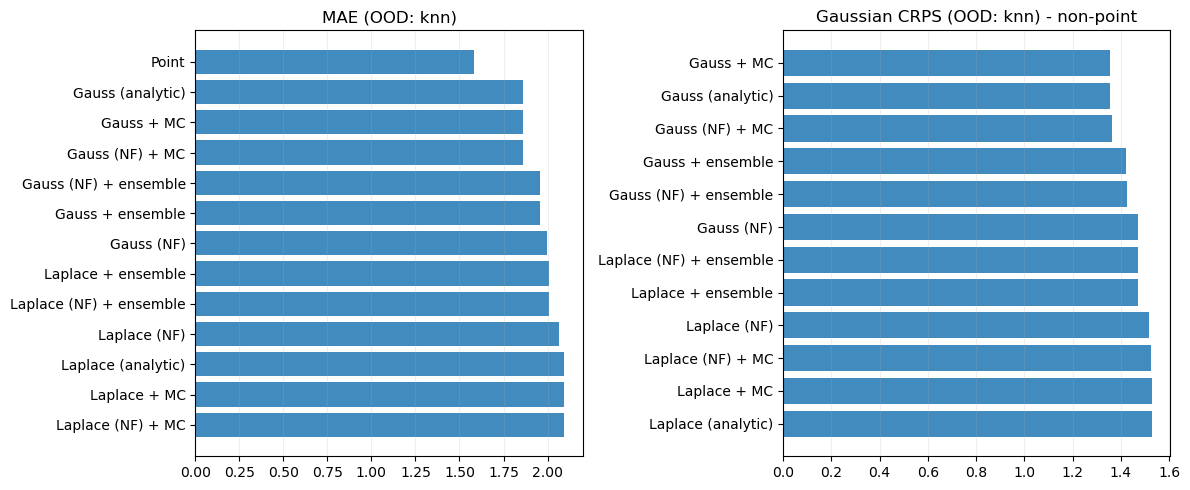

In [94]:
# Phase 6A: OOD predictive quality (MAE + CRPS) per method/label

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

if "gaussian_crps_mean" not in globals():
    from scipy.stats import norm as _norm
    def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
        y = np.asarray(y, float)
        mu = np.asarray(mu, float)
        sigma = np.asarray(sigma, float)
        mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
        if not np.any(mask):
            return float("nan")
        y = y[mask]
        mu = mu[mask]
        sigma = sigma[mask]
        z = (y - mu) / sigma
        crps = sigma * (z * (2 * _norm.cdf(z) - 1) + 2 * _norm.pdf(z) - 1 / np.sqrt(np.pi))
        return float(np.mean(crps))


def _sigma_total(spec: MethodSpec, df: pd.DataFrame) -> np.ndarray:
    s_a = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        _, _, s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a,
            sigma_epi_raw=s_e,
        )
    else:
        s_t = np.sqrt(np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0))
    return np.asarray(s_t, float)


if not OOD_LABELS:
    print("[phase6] No OOD labels configured; skipping OOD quality.")
else:
    rows = []
    for label in OOD_LABELS:
        for spec in METHODS:
            if spec.kind == "dido":
                continue
            try:
                df = method_ood_frame(spec, label)
            except Exception as e:
                print(f"[skip OOD quality] {spec.key}/{label}: {type(e).__name__}: {e}")
                continue
            if "y_true" not in df.columns or "mu" not in df.columns:
                continue

            y = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(float)
            mu = pd.to_numeric(df["mu"], errors="coerce").to_numpy(float)
            mae = float(np.nanmean(np.abs(y - mu)))
            rmse = float(np.sqrt(np.nanmean((y - mu) ** 2)))

            crps = float("nan")
            if spec.head_type != "point":
                s_t = _sigma_total(spec, df)
                crps = gaussian_crps_mean(y, mu, s_t)

            rows.append({
                "ood_label": label,
                "method": spec.label,
                "key": spec.key,
                "head_type": spec.head_type,
                "n": int(len(df)),
                "MAE": mae,
                "RMSE": rmse,
                "CRPS": crps,
            })

    df_ood_quality = pd.DataFrame(rows)
    EXPORTER.export_table(df_ood_quality, f"ood_quality_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split="test")
    display(df_ood_quality.sort_values(["ood_label", "MAE"]))

    def _barh(ax, df, metric, title):
        sub = df[np.isfinite(df[metric].to_numpy(float))].copy()
        if sub.empty:
            ax.set_axis_off()
            ax.set_title(f"{title} (no data)")
            return
        sub = sub.sort_values(metric, ascending=True)
        y = np.arange(len(sub))
        vals = sub[metric].to_numpy(float)
        ax.barh(y, vals, color="tab:blue", alpha=0.85)
        ax.set_yticks(y)
        ax.set_yticklabels(sub["method"])
        ax.invert_yaxis()
        ax.set_title(title)
        ax.grid(True, axis="x", alpha=0.2)
        ax.ticklabel_format(style="plain", axis="x", useOffset=False)

    for label in OOD_LABELS:
        sub = df_ood_quality[df_ood_quality["ood_label"] == label].copy()
        if sub.empty:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        _barh(axes[0], sub, "MAE", f"MAE (OOD: {label})")
        sub_non_point = sub[sub["head_type"] != "point"]
        _barh(axes[1], sub_non_point, "CRPS", f"Gaussian CRPS (OOD: {label}) - non-point")
        plt.tight_layout()
        # savefig(fig, f"ood_quality_{label}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split="test")
        plt.show()


,ood_label,method,metric,id_value,ood_value
0,id_only,Point,MAE,1.385251,NaN
1,id_only,Point,CRPS,NaN,NaN
2,id_only,Point,IntervalHalfWidth@90,NaN,NaN
3,id_only,Laplace (analytic),MAE,1.547635,NaN
4,id_only,Laplace (analytic),CRPS,1.113104,NaN
5,id_only,Laplace (analytic),IntervalHalfWidth@90,3.326955,NaN
6,id_only,Laplace + MC,MAE,1.589841,NaN
7,id_only,Laplace + MC,CRPS,1.135674,NaN
8,id_only,Laplace + MC,IntervalHalfWidth@90,3.328051,NaN
9,id_only,Laplace + ensemble,MAE,1.501237,NaN


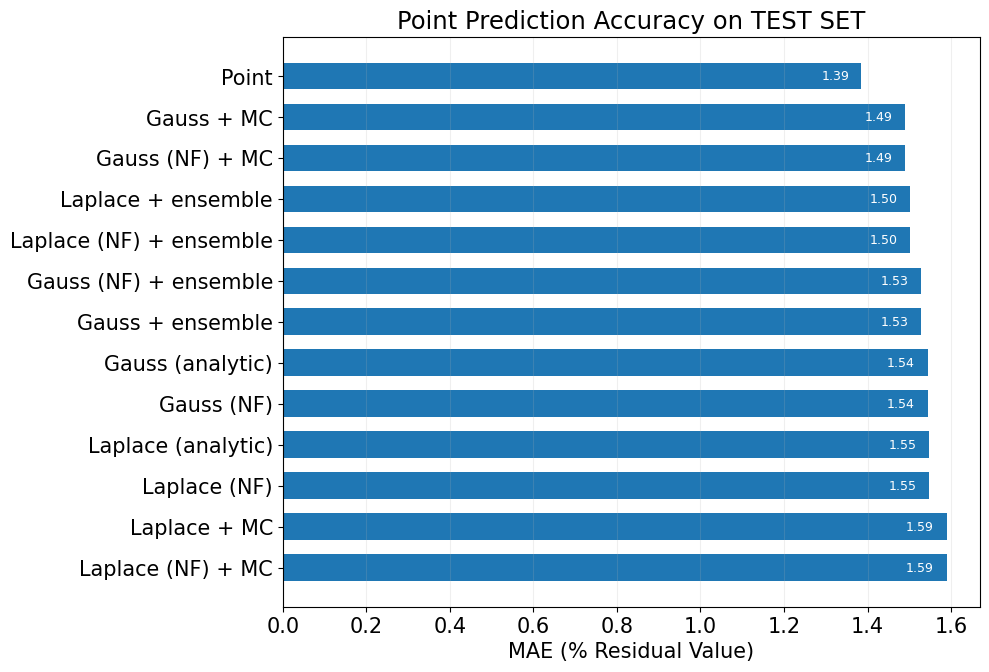

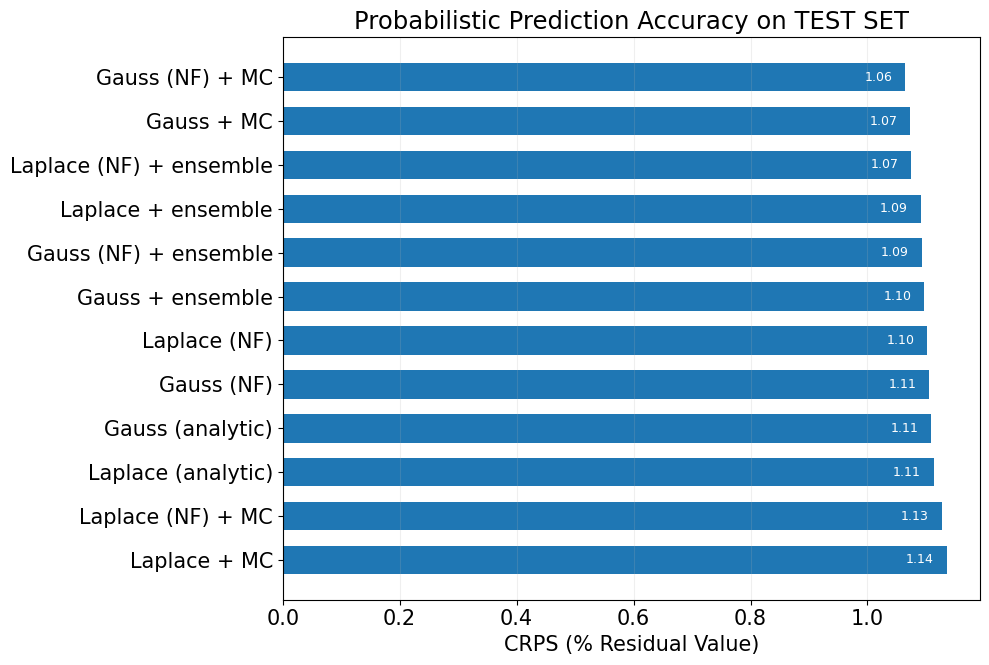

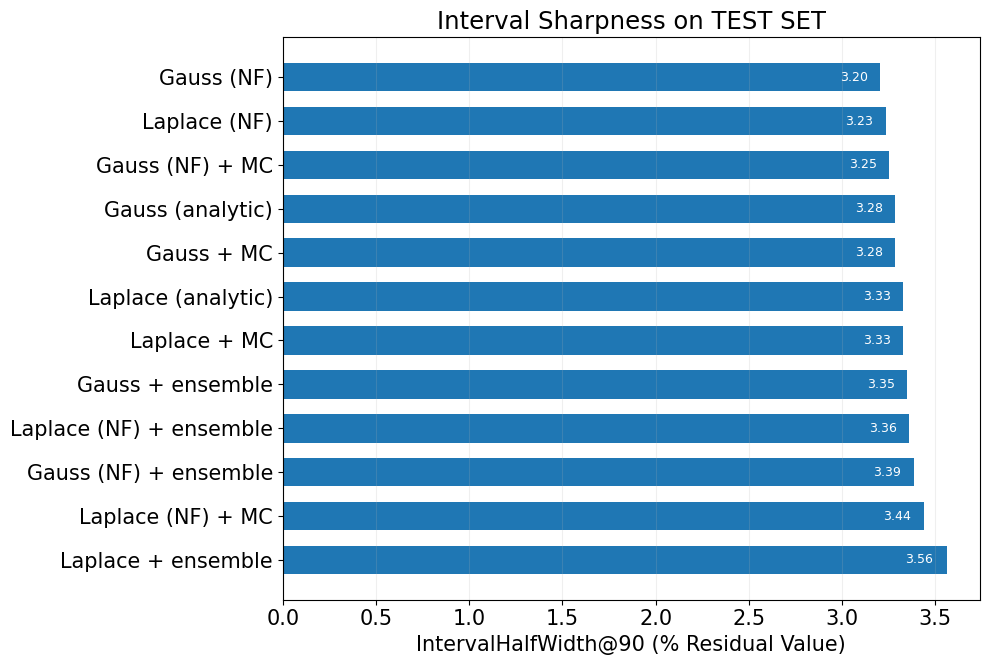

,ood_label,method,metric,id_value,ood_value
0,knn,Point,MAE,1.371599,1.581860
1,knn,Point,CRPS,NaN,NaN
2,knn,Point,IntervalHalfWidth@90,NaN,NaN
3,knn,Laplace (analytic),MAE,1.496663,2.094874
4,knn,Laplace (analytic),CRPS,1.074623,1.528938
5,knn,Laplace (analytic),IntervalHalfWidth@90,3.325520,3.461068
6,knn,Laplace + MC,MAE,1.540751,2.094874
7,knn,Laplace + MC,CRPS,1.097889,1.528907
8,knn,Laplace + MC,IntervalHalfWidth@90,3.326627,3.462125
9,knn,Laplace + ensemble,MAE,1.452964,2.008261


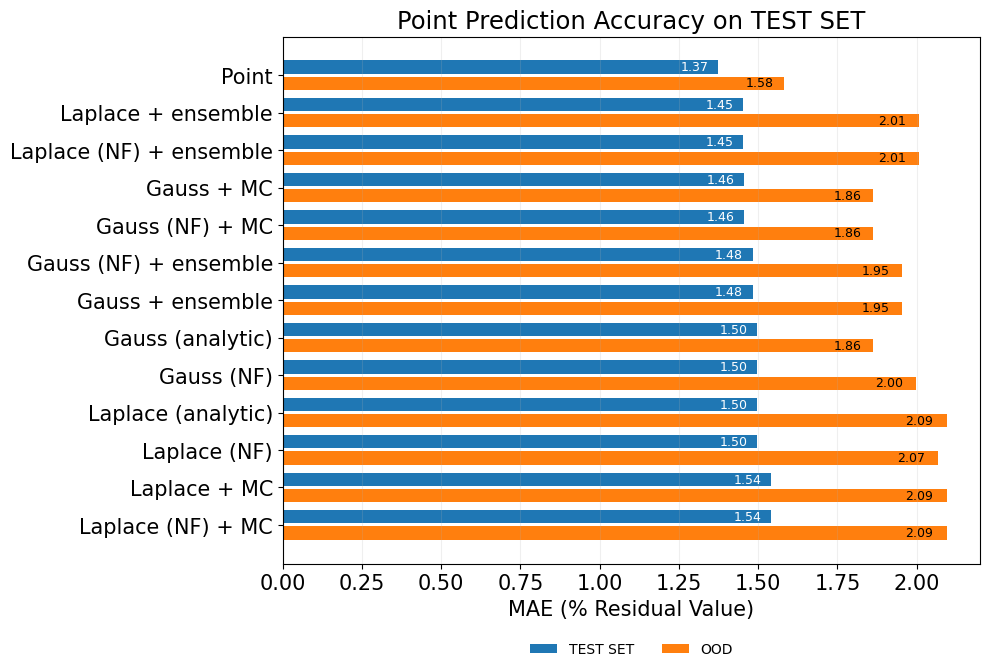

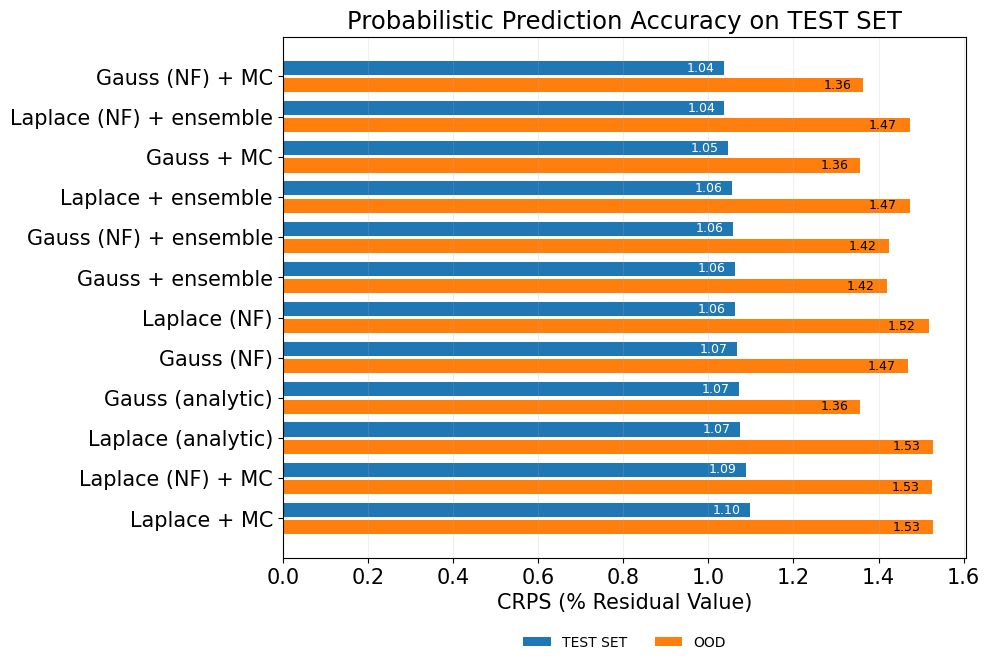

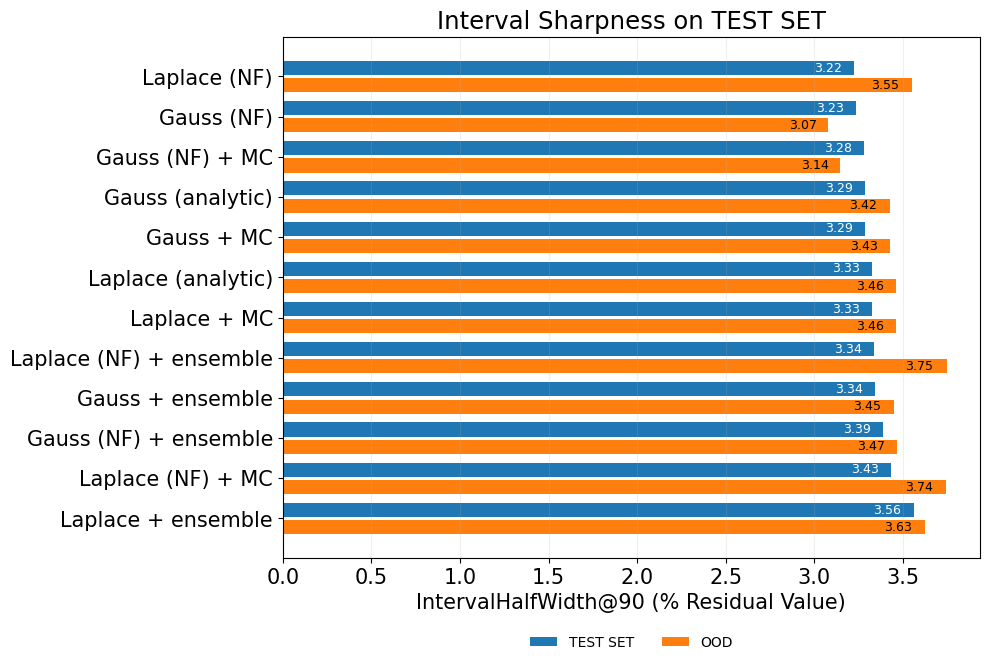

In [95]:
# Phase 6B: ID:test vs OOD (MAE + CRPS + IntervalHalfWidth@90) side-by-side

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
PRED_COVER = 0.90
Z90 = float(norm.ppf((1.0 + PRED_COVER) / 2.0))

# ---- font scaling (25% bigger) ----
FONT_SCALE = 1.25

def _as_points(v, default):
    # Matplotlib rcParams can be numeric OR strings like 'large'
    if isinstance(v, (int, float)):
        return float(v)
    mapping = {
        "xx-small": 6, "x-small": 8, "small": 10, "medium": 12,
        "large": 14, "x-large": 16, "xx-large": 18,
    }
    return float(mapping.get(str(v).lower(), default))

TITLE_SIZE = _as_points(plt.rcParams.get("axes.titlesize", 12), 12) * FONT_SCALE
LABEL_SIZE = _as_points(plt.rcParams.get("axes.labelsize", 10), 10) * FONT_SCALE
# -----------------------------------

def _metric_units_suffix() -> str:
    dk = str(DATASET_KEY).lower() if "DATASET_KEY" in globals() else ""
    if dk.startswith("vw"):
        return " (% Residual Value)"
    if dk.startswith("craigs"):
        return " (USD)"
    return ""

def _metric_plot_title(metric: str) -> str:
    if metric == "MAE":
        return "Point Prediction Accuracy on TEST SET"
    if metric == "CRPS":
        return "Probabilistic Prediction Accuracy on TEST SET"
    if metric == "IntervalHalfWidth@90":
        return "Interval Sharpness on TEST SET"
    return "Predictive Accuracy on TEST SET"

if not OOD_LABELS:
    print("[phase6] No OOD labels configured; skipping ID vs OOD plots.")
else:
    def _build_frames(include_ood: bool) -> pd.DataFrame:
        rows = []
        labels = OOD_LABELS if include_ood else ["id_only"]
        for label in labels:
            for spec in METHODS:
                if spec.kind == "dido":
                    continue
                try:
                    df_id = method_id_frame(spec, "test")
                    df_ood = None
                    if include_ood:
                        df_ood = method_ood_frame(spec, label)
                        df_id, df_ood = apply_knn_bands(df_id, df_ood, label, spec.key)
                except Exception as e:
                    print(f"[skip ID/OOD] {spec.key}/{label}: {type(e).__name__}: {e}")
                    continue
                if "y_true" not in df_id.columns or "mu" not in df_id.columns:
                    continue

                def _metrics(df: pd.DataFrame):
                    y = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(float)
                    mu = pd.to_numeric(df["mu"], errors="coerce").to_numpy(float)
                    mae = float(np.nanmean(np.abs(y - mu)))
                    crps = float("nan")
                    iw90 = float("nan")
                    if spec.head_type != "point":
                        s_t = _sigma_total(spec, df)
                        crps = gaussian_crps_mean(y, mu, s_t)
                        iw90 = float(np.nanmean(Z90 * s_t))
                    return mae, crps, iw90

                mae_id, crps_id, iw_id = _metrics(df_id)
                mae_ood, crps_ood, iw_ood = (float("nan"), float("nan"), float("nan"))
                if include_ood and df_ood is not None:
                    mae_ood, crps_ood, iw_ood = _metrics(df_ood)

                rows.append({
                    "ood_label": label,
                    "method": spec.label,
                    "metric": "MAE",
                    "id_value": mae_id,
                    "ood_value": mae_ood,
                })
                rows.append({
                    "ood_label": label,
                    "method": spec.label,
                    "metric": "CRPS",
                    "id_value": crps_id,
                    "ood_value": crps_ood,
                })
                rows.append({
                    "ood_label": label,
                    "method": spec.label,
                    "metric": "IntervalHalfWidth@90",
                    "id_value": iw_id,
                    "ood_value": iw_ood,
                })
        return pd.DataFrame(rows)

    def _plot_frames(df_id_ood: pd.DataFrame, include_ood: bool):
        labels = OOD_LABELS if include_ood else ["id_only"]
        tag = "with_ood" if include_ood else "id_only"
        height_id_only = 0.65
        height_id_ood = 0.35
        gap = 0.04

        EXPORTER.export_table(df_id_ood, f"id_vs_ood_metrics_{tag}", dataset=DATASET_KEY, split="test")
        display(df_id_ood)

        for label in labels:
            for metric in ("MAE", "CRPS", "IntervalHalfWidth@90"):
                sub = df_id_ood[(df_id_ood["ood_label"] == label) & (df_id_ood["metric"] == metric)].copy()
                if sub.empty:
                    continue
                if metric in {"CRPS", "IntervalHalfWidth@90"}:
                    sub = (
                        sub[np.isfinite(sub["id_value"]) & np.isfinite(sub["ood_value"])]
                        if include_ood
                        else sub[np.isfinite(sub["id_value"])]
                    )

                sub = sub.sort_values("id_value", ascending=True)

                y = np.arange(len(sub))
                height = height_id_ood if include_ood else height_id_only
                bar_offset = height / 2 + gap

                fig, ax = plt.subplots(figsize=(10, 1.5 * max(4.5, 0.35 * len(sub))))
                if include_ood:
                    bars_id = ax.barh(y - bar_offset, sub["id_value"], height, label="TEST SET", color="tab:blue")
                    bars_ood = ax.barh(y + bar_offset, sub["ood_value"], height, label="OOD", color="tab:orange")
                else:
                    bars_id = ax.barh(y, sub["id_value"], height, label="TEST SET", color="tab:blue")
                    bars_ood = []

                ax.set_yticks(y)
                ax.set_yticklabels(sub["method"])
                ax.invert_yaxis()
                ax.tick_params(axis="x", labelsize=LABEL_SIZE)
                ax.set_xlabel(f"{metric}{_metric_units_suffix()}", fontsize=LABEL_SIZE)
                ax.tick_params(axis="y", labelsize=LABEL_SIZE)
                ax.set_title(_metric_plot_title(metric), fontsize=TITLE_SIZE)
                if include_ood:
                    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
                ax.grid(True, axis="x", alpha=0.2)
                ax.ticklabel_format(style="plain", axis="x", useOffset=False)

                fmt = (lambda v: f"{v:,.2f}") if metric in {"MAE", "IntervalHalfWidth@90"} else (lambda v: f"{v:.2f}")
                for bar in list(bars_id) + list(bars_ood):
                    w = bar.get_width()
                    if not np.isfinite(w):
                        continue
                    y_text = bar.get_y() + bar.get_height() / 2
                    x_text = w * 0.98 if w > 0 else w
                    color = "white" if bar in bars_id else "black"
                    ax.text(x_text, y_text, fmt(w), va="center", ha="right", color=color, fontsize=9)

                fig.tight_layout()
                savefig(
                    fig,
                    f"id_vs_{'ood' if include_ood else 'id'}_{metric.lower().replace('@','')}_{label}_{tag}",
                    dataset=DATASET_KEY,
                    split="test",
                )
                plt.show()

    df_id_only = _build_frames(False)
    _plot_frames(df_id_only, False)

    df_with_ood = _build_frames(True)
    _plot_frames(df_with_ood, True)


## Phase 7: Cohort sanity + aleatoric validity

Use dataset metadata to inspect cohort sizes and relate cohort error to predicted aleatoric uncertainty.

In [96]:
# Phase 7A: cohort candidates quick check (uses config.cohorts)

import numpy as np
import pandas as pd

_coh = COHORTS if isinstance(COHORTS, dict) else {}
dataset_csv = _resolve_path(_coh.get("dataset_csv"))
if not _coh.get("enabled", False) or not dataset_csv or not dataset_csv.exists():
    print("[cohorts] disabled or dataset_csv missing; skipping.")
else:
    id_col = _coh.get("id_col", "id")
    cohort_defs = _coh.get("cohort_defs", {}) or {}
    age_col = _coh.get("age_col")
    age_bins = _coh.get("age_bins")
    age_from_cols = _coh.get("age_from_cols", []) or []
    min_n = int(_coh.get("min_cohort_n", 100))

    usecols = {id_col}
    for cols in cohort_defs.values():
        for c in cols:
            if c != "age_bucket":
                usecols.add(c)
    if age_col and age_col != "age_bucket" and not age_from_cols:
        usecols.add(age_col)
    for c in age_from_cols:
        usecols.add(c)

    # Only keep columns that actually exist in the CSV.
    header = pd.read_csv(dataset_csv, nrows=0).columns
    usecols = [c for c in usecols if c in header]

    df_meta = pd.read_csv(dataset_csv, usecols=usecols)

    if age_col and age_col not in df_meta.columns and len(age_from_cols) == 2:
        a0, a1 = age_from_cols
        if a0 in df_meta.columns and a1 in df_meta.columns:
            df_meta[age_col] = pd.to_numeric(df_meta[a0], errors="coerce") - pd.to_numeric(df_meta[a1], errors="coerce")

    if age_col and age_bins and age_col in df_meta.columns:
        df_meta[age_col] = pd.to_numeric(df_meta[age_col], errors="coerce")
        labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins) - 1)]
        df_meta["age_bucket"] = pd.cut(df_meta[age_col], bins=age_bins, labels=labels, include_lowest=True)

    rows = []
    for name, cols in cohort_defs.items():
        missing = [c for c in cols if c not in df_meta.columns]
        if missing:
            rows.append({"cohort_name": name, "cols": cols, "status": f"missing: {missing}"})
            continue
        tmp = df_meta.dropna(subset=cols).copy()
        key = tmp[cols].astype(str).agg(" / ".join, axis=1)
        counts = key.value_counts()
        rows.append({
            "cohort_name": name,
            "cols": " + \n".join(cols),
            "n_rows_used": int(counts.sum()),
            "n_cohorts": int(counts.size),
            "cohort_size_q50": float(np.quantile(counts.to_numpy(), 0.50)) if counts.size else np.nan,
            "cohort_size_q90": float(np.quantile(counts.to_numpy(), 0.90)) if counts.size else np.nan,
            "cohort_size_q99": float(np.quantile(counts.to_numpy(), 0.99)) if counts.size else np.nan,
            "n_cohorts_ge_min_n": int((counts >= min_n).sum()),
        })

    df_cohorts = pd.DataFrame(rows)
    EXPORTER.export_table(df_cohorts, "cohort_candidates", dataset=DATASET_KEY)
    display(df_cohorts)
    print(f"[cohorts] loaded {len(df_meta):,} rows from {dataset_csv}")


,cohort_name,cols,n_rows_used,n_cohorts,cohort_size_q50,cohort_size_q90,cohort_size_q99,n_cohorts_ge_min_n
0,vda_make+vda_model,vda_make + \nvda_model,401450,83,1161.0,13007.0,50801.04,54
1,mbv_model,mbv_model,401450,165,206.0,8099.4,26160.04,95


[cohorts] loaded 401,450 rows from /home/canelo/uncertainty_quantification/datasets/rv_dataset_2024.csv


In [97]:
# Phase 7B: noise-cohort analysis (aleatoric validity) on ID:test

import numpy as np
import pandas as pd

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

# ---- toggle ----
INCLUDE_EPI_VARIANTS = False  # include MC/ensemble variants (epistemic_source in {"mc","ensemble"})
# ----------------

_coh = COHORTS if isinstance(COHORTS, dict) else {}
dataset_csv = _resolve_path(_coh.get("dataset_csv"))
if not _coh.get("enabled", False) or not dataset_csv or not dataset_csv.exists():
    print("[cohorts] disabled or dataset_csv missing; skipping.")
else:
    id_col = _coh.get("id_col", "id")
    cohort_defs = _coh.get("cohort_defs", {}) or {}
    age_col = _coh.get("age_col")
    age_bins = _coh.get("age_bins")
    age_from_cols = _coh.get("age_from_cols", []) or []
    min_n = int(_coh.get("min_cohort_n", 100))

    if "df_meta" not in globals():
        usecols = {id_col}
        for cols in cohort_defs.values():
            for c in cols:
                if c != "age_bucket":
                    usecols.add(c)
        if age_col and age_col != "age_bucket":
            usecols.add(age_col)
        for c in age_from_cols:
            usecols.add(c)

        header = pd.read_csv(dataset_csv, nrows=0).columns
        usecols = [c for c in usecols if c in header]
        df_meta = pd.read_csv(dataset_csv, usecols=usecols)

    if age_col and age_col not in df_meta.columns and len(age_from_cols) == 2:
        a0, a1 = age_from_cols
        if a0 in df_meta.columns and a1 in df_meta.columns:
            df_meta[age_col] = pd.to_numeric(df_meta[a0], errors="coerce") - pd.to_numeric(
                df_meta[a1], errors="coerce"
            )

    need_age_bucket = any("age_bucket" in cols for cols in cohort_defs.values())
    if need_age_bucket and age_col and age_bins and age_col in df_meta.columns and "age_bucket" not in df_meta.columns:
        df_meta[age_col] = pd.to_numeric(df_meta[age_col], errors="coerce")
        labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins) - 1)]
        df_meta["age_bucket"] = pd.cut(df_meta[age_col], bins=age_bins, labels=labels, include_lowest=True)

    if id_col != "id" and id_col in df_meta.columns:
        df_meta = df_meta.rename(columns={id_col: "id"})

    results = []
    for spec in METHODS:
        if spec.kind == "dido" or spec.head_type == "point":
            continue
        if not INCLUDE_EPI_VARIANTS and str(spec.epistemic_source).lower() in {"mc", "ensemble"}:
            continue

        try:
            df_pred = method_id_frame(spec, "test")
        except Exception as e:
            print(f"[skip noise] {spec.key}: {type(e).__name__}: {e}")
            continue
        if "y_true" not in df_pred.columns or "mu" not in df_pred.columns:
            continue

        y = pd.to_numeric(df_pred["y_true"], errors="coerce").to_numpy(float)
        mu = pd.to_numeric(df_pred["mu"], errors="coerce").to_numpy(float)
        s_a = pd.to_numeric(df_pred.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
        s_e = pd.to_numeric(df_pred.get("sigma_epi_raw"), errors="coerce").fillna(0.0).to_numpy(float)

        if USE_CALIBRATED_SIGMAS_LOCAL:
            s_a, _, s_t = calibrated_sigmas(
                head_type=spec.head_type,
                ale_src=spec.aleatoric_source,
                epi_src=spec.epistemic_source,
                sigma_ale_raw=s_a,
                sigma_epi_raw=s_e,
            )
        else:
            s_t = np.sqrt(
                np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0)
            )

        id_series = df_pred.get("id")
        if id_series is None and id_col in df_pred.columns:
            id_series = df_pred[id_col]

        df_small = pd.DataFrame(
            {
                "id": pd.to_numeric(id_series, errors="coerce"),
                "abs_err": np.abs(y - mu),
                "sigma_ale": np.asarray(s_a, float),
                "sigma_tot": np.asarray(s_t, float),
            }
        )
        df_join = df_small.merge(df_meta, on="id", how="inner")

        for name, cols in cohort_defs.items():
            if any(c not in df_join.columns for c in cols):
                continue
            tmp = df_join.dropna(subset=cols).copy()
            g = tmp.groupby(cols, observed=True).agg(
                n=("id", "size"),
                mean_abs_err=("abs_err", "mean"),
                mean_sigma_ale=("sigma_ale", "mean"),
                mean_sigma_tot=("sigma_tot", "mean"),
            )
            g = g[g["n"] >= min_n]
            if g.empty:
                continue

            corr_ale = float(g["mean_sigma_ale"].corr(g["mean_abs_err"]))
            corr_tot = float(g["mean_sigma_tot"].corr(g["mean_abs_err"]))
            bias_ale = float((g["mean_sigma_ale"] - g["mean_abs_err"]).mean())
            bias_tot = float((g["mean_sigma_tot"] - g["mean_abs_err"]).mean())

            results.append(
                {
                    "method": spec.label,
                    "key": spec.key,
                    "cohort": name,
                    "n_cohorts": int(len(g)),
                    "corr_sigma_ale_vs_err": corr_ale,
                    "corr_sigma_tot_vs_err": corr_tot,
                    "bias_sigma_ale_minus_err": bias_ale,
                    "bias_sigma_tot_minus_err": bias_tot,
                }
            )

    df_noise = pd.DataFrame(results)
    EXPORTER.export_table(df_noise, "noise_cohort_stats", dataset=DATASET_KEY, split="test")
    display(df_noise.sort_values(["cohort", "corr_sigma_ale_vs_err"], ascending=[True, False]))


,method,key,cohort,n_cohorts,corr_sigma_ale_vs_err,corr_sigma_tot_vs_err,bias_sigma_ale_minus_err,bias_sigma_tot_minus_err
5,Laplace (NF),nf_lpl,mbv_model,66,0.891524,0.891524,0.390164,0.390164
7,Gauss (NF),nf_gau,mbv_model,66,0.845656,0.845656,0.356559,0.356559
3,Gauss (analytic),gau_analytic,mbv_model,66,0.738378,0.738378,0.428712,0.428712
1,Laplace (analytic),lpl_analytic,mbv_model,66,0.736074,0.736074,0.450768,0.450768
4,Laplace (NF),nf_lpl,vda_make+vda_model,47,0.921547,0.921547,0.386528,0.386528
6,Gauss (NF),nf_gau,vda_make+vda_model,47,0.882265,0.882265,0.380927,0.380927
0,Laplace (analytic),lpl_analytic,vda_make+vda_model,47,0.780960,0.780960,0.425029,0.425029
2,Gauss (analytic),gau_analytic,vda_make+vda_model,47,0.778675,0.778675,0.417320,0.417320


,method,r2_loglog,n_cohorts
2,Laplace (NF),0.727606,66
0,Gauss (NF),0.724973,66
3,Laplace (analytic),0.582234,66
1,Gauss (analytic),0.550556,66


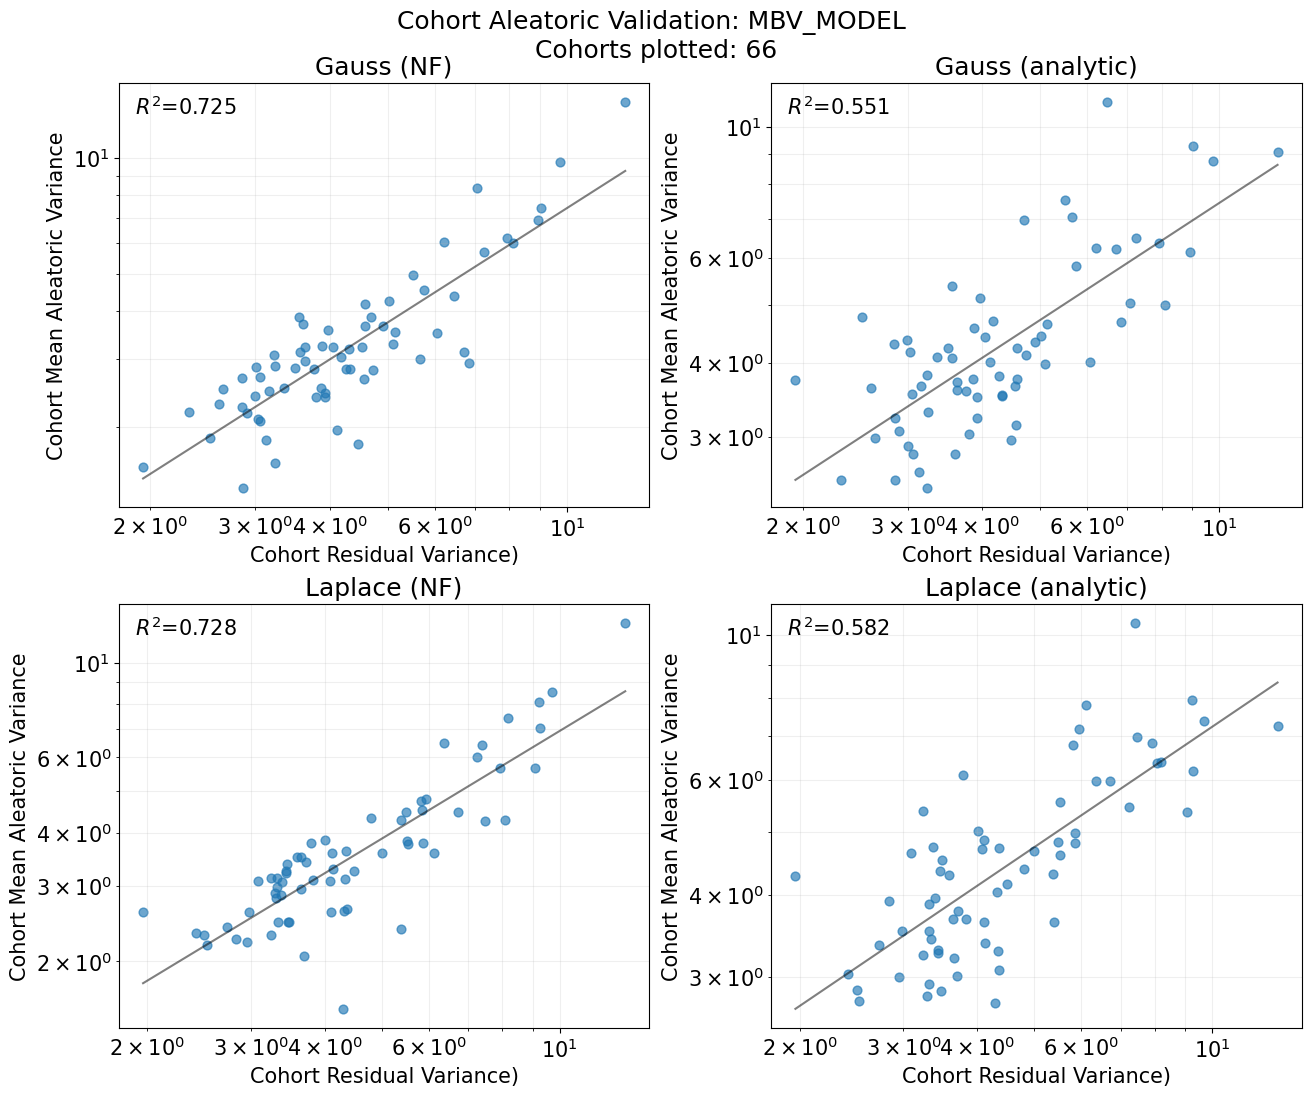

,method,r2_loglog,n_cohorts
2,Laplace (NF),0.821280,47
0,Gauss (NF),0.759531,47
3,Laplace (analytic),0.624695,47
1,Gauss (analytic),0.607432,47


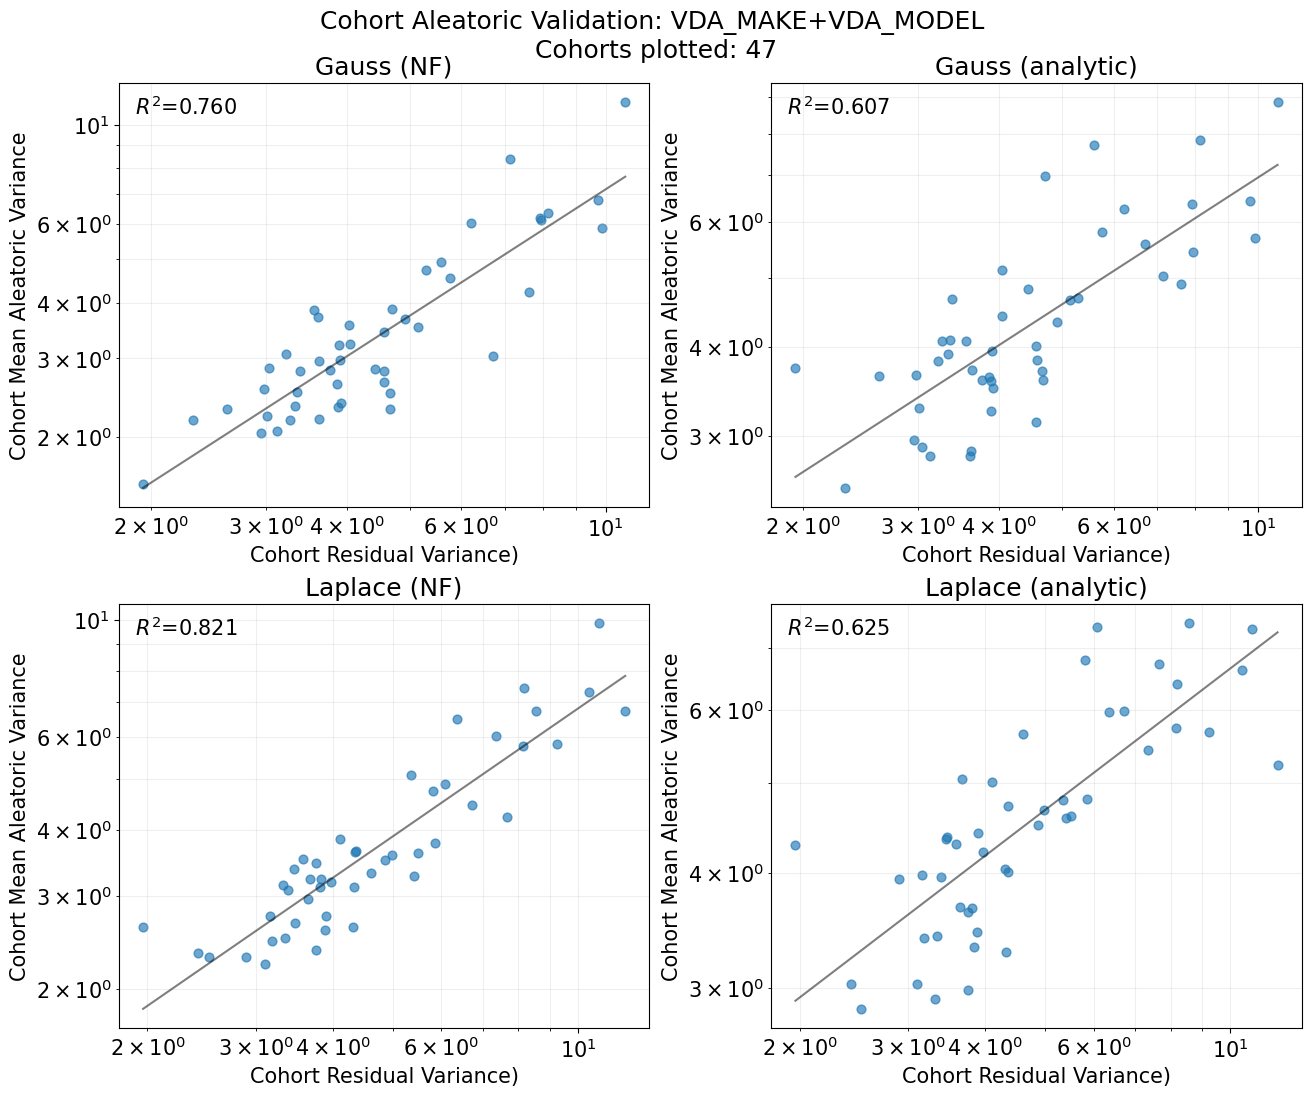

In [98]:
# Phase 7C: noise-cohort plots (log-log)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

# ----------------- font scaling -----------------
FONT_SCALE = 1.5

from matplotlib.font_manager import FontProperties

def _to_points(v, fallback=10.0) -> float:
    try:
        return float(FontProperties(size=v).get_size_in_points())
    except Exception:
        try:
            return float(v)
        except Exception:
            return float(fallback)

TITLE_SIZE = _to_points(plt.rcParams.get("axes.titlesize", 12)) * FONT_SCALE
LABEL_SIZE = _to_points(plt.rcParams.get("axes.labelsize", 10)) * FONT_SCALE
TICK_SIZE = _to_points(plt.rcParams.get("xtick.labelsize", 10)) * FONT_SCALE
LEGEND_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10)) * FONT_SCALE
SUPTITLE_SIZE = _to_points(plt.rcParams.get("figure.titlesize", plt.rcParams.get("axes.titlesize", 12))) * FONT_SCALE
# -----------------------------------------------

# ---- toggle ----
INCLUDE_EPI_VARIANTS = False  # if True, include MC/ensemble variants too; if False, ONLY epi_source=="none" + NF(also epi_source=="none")
# ----------------

_coh = COHORTS if isinstance(COHORTS, dict) else {}
dataset_csv = _resolve_path(_coh.get("dataset_csv"))
if not _coh.get("enabled", False) or not dataset_csv or not dataset_csv.exists():
    print("[cohorts] disabled or dataset_csv missing; skipping.")
else:
    id_col = _coh.get("id_col", "id")
    cohort_defs = _coh.get("cohort_defs", {}) or {}
    age_col = _coh.get("age_col")
    age_bins = _coh.get("age_bins")
    age_from_cols = _coh.get("age_from_cols", []) or []
    min_n = int(_coh.get("min_cohort_n", 100))

    if "df_meta" not in globals():
        usecols = {id_col}
        for cols in cohort_defs.values():
            for c in cols:
                if c != "age_bucket":
                    usecols.add(c)
        if age_col and age_col != "age_bucket":
            usecols.add(age_col)
        for c in age_from_cols:
            usecols.add(c)

        header = pd.read_csv(dataset_csv, nrows=0).columns
        usecols = [c for c in usecols if c in header]
        df_meta = pd.read_csv(dataset_csv, usecols=usecols)

    if age_col and age_col not in df_meta.columns and len(age_from_cols) == 2:
        a0, a1 = age_from_cols
        if a0 in df_meta.columns and a1 in df_meta.columns:
            df_meta[age_col] = pd.to_numeric(df_meta[a0], errors="coerce") - pd.to_numeric(
                df_meta[a1], errors="coerce"
            )

    need_age_bucket = any("age_bucket" in cols for cols in cohort_defs.values())
    if need_age_bucket and age_col and age_bins and age_col in df_meta.columns and "age_bucket" not in df_meta.columns:
        df_meta[age_col] = pd.to_numeric(df_meta[age_col], errors="coerce")
        labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins) - 1)]
        df_meta["age_bucket"] = pd.cut(df_meta[age_col], bins=age_bins, labels=labels, include_lowest=True)

    if id_col != "id" and id_col in df_meta.columns:
        df_meta = df_meta.rename(columns={id_col: "id"})

    def _attach_meta(df_eval: pd.DataFrame, cols_needed: list[str]) -> pd.DataFrame:
        if "id" not in df_eval.columns:
            raise KeyError("Eval frame missing 'id' column; cannot join cohorts")
        out = df_eval.copy()
        out["id"] = pd.to_numeric(out["id"], errors="coerce")
        out = out.dropna(subset=["id"])
        out["id"] = out["id"].astype(int)
        meta_cols = ["id"] + [c for c in cols_needed if c in df_meta.columns]
        out = out.merge(df_meta[meta_cols], on="id", how="left")
        return out

    def _cohort_key(df: pd.DataFrame, cols: list[str]) -> pd.Series:
        return df[cols].astype(str).agg(" / ".join, axis=1)

    def _aleatoric_sigma(spec: MethodSpec, df_eval: pd.DataFrame) -> np.ndarray:
        sA_raw = pd.to_numeric(df_eval.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
        if str(spec.aleatoric_source).lower() == "nf":
            return np.asarray(sA_raw, float)
        if USE_CALIBRATED_SIGMAS_LOCAL:
            sE_zeros = np.zeros_like(sA_raw, dtype=float)
            sA, _, _ = calibrated_sigmas(
                head_type=spec.head_type,
                ale_src=spec.aleatoric_source,
                epi_src="none",
                sigma_ale_raw=sA_raw,
                sigma_epi_raw=sE_zeros,
            )
            return np.asarray(sA, float)
        return np.asarray(sA_raw, float)

    # Select specs
    specs = []
    for m in METHODS:
        if m.kind == "dido" or m.head_type == "point":
            continue

        if INCLUDE_EPI_VARIANTS:
            if m.head_type in {"gauss", "laplace"} or (str(m.aleatoric_source).lower() == "nf"):
                specs.append(m)
        else:
            if m.head_type in {"gauss", "laplace"}:
                is_analytic = (
                    str(m.epistemic_source).lower() == "none"
                    and str(m.aleatoric_source).lower() == "analytic"
                )
                is_nf = (
                    str(m.aleatoric_source).lower() == "nf"
                    and str(m.epistemic_source).lower() == "none"
                )
                if is_analytic or is_nf:
                    specs.append(m)

    seen = set()
    specs = [m for m in specs if (m.label not in seen and not seen.add(m.label))]

    tables = []
    for spec in specs:
        try:
            df_id = method_id_frame(spec, "test")
        except Exception as e:
            print(f"[skip noise plot] {spec.key}: {type(e).__name__}: {e}")
            continue
        if "y_true" not in df_id.columns or "mu" not in df_id.columns:
            continue

        y = pd.to_numeric(df_id["y_true"], errors="coerce").to_numpy(float)
        mu = pd.to_numeric(df_id["mu"], errors="coerce").to_numpy(float)
        resid = y - mu
        sA = _aleatoric_sigma(spec, df_id)

        for cohort_name, cols in cohort_defs.items():
            needed_cols = list(cols)
            df_join = _attach_meta(df_id, needed_cols)
            if any(c not in df_join.columns for c in cols):
                continue
            tmp = pd.DataFrame(
                {"cohort": _cohort_key(df_join, cols), "resid": resid, "sA2": np.square(sA)}
            )
            tmp = tmp[np.isfinite(tmp["resid"]) & np.isfinite(tmp["sA2"])].copy()
            g = (
                tmp.groupby("cohort")
                .agg(n=("resid", "size"), resid_var=("resid", "var"), mean_sA2=("sA2", "mean"))
                .reset_index()
            )
            g = g[g["n"] >= min_n].copy()
            if g.empty:
                continue
            g["cohort_def"] = cohort_name
            g["method"] = spec.label
            tables.append(g)

    if not tables:
        print("[noise plot] No cohort tables produced.")
    else:
        df_noise = pd.concat(tables, ignore_index=True)
        EXPORTER.export_table(
            df_noise,
            f"noise_cohort_scatter_{'epi' if INCLUDE_EPI_VARIANTS else 'ale_only'}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
            dataset=DATASET_KEY,
            split="test",
        )

        def _safe_name(s: str) -> str:
            return "".join(c if (c.isalnum() or c in "-_") else "_" for c in s)

        def _fit_loglog(x: np.ndarray, y: np.ndarray):
            x = np.asarray(x, float)
            y = np.asarray(y, float)
            m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
            if np.sum(m) < 2:
                return None, None, None, None
            lx = np.log10(x[m])
            ly = np.log10(y[m])
            a, b = np.polyfit(lx, ly, 1)
            y_hat = a * lx + b
            ss_res = float(np.sum((ly - y_hat) ** 2))
            ss_tot = float(np.sum((ly - np.mean(ly)) ** 2))
            r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else float("nan")
            return a, b, r2, m

        def _plot_grid_for_cohort(cohort_def: str, df_all: pd.DataFrame):
            methods_here = sorted(df_all["method"].unique().tolist())
            n = len(methods_here)
            if n == 0:
                return
            ncols = 2
            nrows = int(np.ceil(n / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 5.2 * nrows), constrained_layout=True)
            axes = np.atleast_1d(axes).reshape(-1)

            r2_rows = []

            for ax, method in zip(axes, methods_here):
                sub = df_all[(df_all["method"] == method) & (df_all["resid_var"] > 0) & (df_all["mean_sA2"] > 0)].copy()
                if sub.empty:
                    ax.set_axis_off()
                    continue

                x = sub["resid_var"].to_numpy(float)
                y = sub["mean_sA2"].to_numpy(float)

                ax.scatter(x, y, s=40, alpha=0.65)
                ax.set_xscale("log")
                ax.set_yscale("log")
                ax.set_xlabel("Cohort Residual Variance)", fontsize=LABEL_SIZE)
                ax.set_ylabel("Cohort Mean Aleatoric Variance", fontsize=LABEL_SIZE)
                ax.tick_params(axis="both", which="both", labelsize=TICK_SIZE)
                ax.set_title(f"{method}", fontsize=TITLE_SIZE)
                ax.grid(True, which="both", alpha=0.2)

                a, b, r2, _ = _fit_loglog(x, y)
                r2_rows.append({"method": method, "r2_loglog": r2, "n_cohorts": int(len(sub))})

                if a is not None and b is not None:
                    x_line = np.linspace(np.min(x), np.max(x), 200)
                    y_line = 10 ** (a * np.log10(x_line) + b)
                    ax.plot(x_line, y_line, color="black", alpha=0.5)
                    ax.text(
                        0.03,
                        0.97,
                        f"$R^2$={r2:.3f}",
                        transform=ax.transAxes,
                        ha="left",
                        va="top",
                        color="black",
                        fontsize=LABEL_SIZE,
                    )

            for ax in axes[n:]:
                ax.set_axis_off()

            r2_df = pd.DataFrame(r2_rows).sort_values("r2_loglog", ascending=False)
            display(r2_df)
            EXPORTER.export_table(
                r2_df,
                f"noise_cohort_r2_{_safe_name(cohort_def)}_{'epi' if INCLUDE_EPI_VARIANTS else 'ale_only'}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
                dataset=DATASET_KEY,
                split="test",
            )

            fig.suptitle(
                f"Cohort Aleatoric Validation: {cohort_def.upper()} \n"
                f"Cohorts plotted: {len(df_all['cohort'].unique())}",
                y=1.04,
                fontsize=SUPTITLE_SIZE,
            )
            savefig(
                fig,
                f"noise_cohort_{cohort_def}_{'epi' if INCLUDE_EPI_VARIANTS else 'ale_only'}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
                dataset=DATASET_KEY,
                split="test",
            )
            plt.show()

        for cohort_def, sub in df_noise.groupby("cohort_def"):
            _plot_grid_for_cohort(cohort_def, sub)


## Phase 8: Uncertainty behavior and decision analysis

Sharpness, large-error AUC, decile diagnostics, selective prediction, and blend synergy.

In [99]:
# Phase 8A: shared helpers

import numpy as np
import pandas as pd

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
EVAL_SCOPE = "id_test"  # "id_test" | "ood" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

SIG_COLORS = {"Ua": "tab:blue", "Ue": "tab:green", "Utot": "tab:orange", "blend": "tab:purple", "random": "0.5"}


def _get_series(df: pd.DataFrame, col: str) -> pd.Series:
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce")
    return pd.Series(np.nan, index=df.index)


def _gather_eval_frames(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    scope = EVAL_SCOPE.strip().lower()

    if scope in {"id_test", "id_test+ood"}:
        df_id = method_id_frame(spec, "test").copy()
        df_id["dataset"] = "id:test"
        parts.append(df_id)

    if scope in {"ood", "id_test+ood"}:
        for ood_label in OOD_LABELS_LOCAL:
            df_o = method_ood_frame(spec, ood_label).copy()
            df_o["dataset"] = f"ood:{ood_label}"
            parts.append(df_o)

    if not parts:
        raise ValueError(f"Unknown EVAL_SCOPE={EVAL_SCOPE!r}")
    return pd.concat(parts, ignore_index=True)


def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    s_a_raw = _get_series(df, "sigma_ale_raw").to_numpy(float)
    s_e_raw = _get_series(df, "sigma_epi_raw").to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        s_a, s_e, s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=np.nan_to_num(s_e_raw, nan=0.0),
        )
    else:
        s_a = np.asarray(s_a_raw, float)
        s_e = np.asarray(s_e_raw, float)
        s_t = np.sqrt(np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0))

    s_a = np.asarray(s_a, float)
    s_e = np.asarray(s_e, float)
    s_t = np.asarray(s_t, float)

    s_e[~np.isfinite(s_e_raw)] = np.nan
    s_t[~(np.isfinite(s_a_raw) | np.isfinite(s_e_raw))] = np.nan
    return s_a, s_e, s_t


SPECS_SIGMA = [s for s in METHODS if s.head_type != "point" and s.kind != "dido"]
SPECS_EPI = [s for s in SPECS_SIGMA if str(s.epistemic_source).lower() in {"mc", "ensemble"}]

print(f"[phase8] scope={EVAL_SCOPE} calibrated={USE_CALIBRATED_SIGMAS_LOCAL} specs_sigma={len(SPECS_SIGMA)} specs_epi={len(SPECS_EPI)}")


[phase8] scope=id_test calibrated=True specs_sigma=12 specs_epi=8


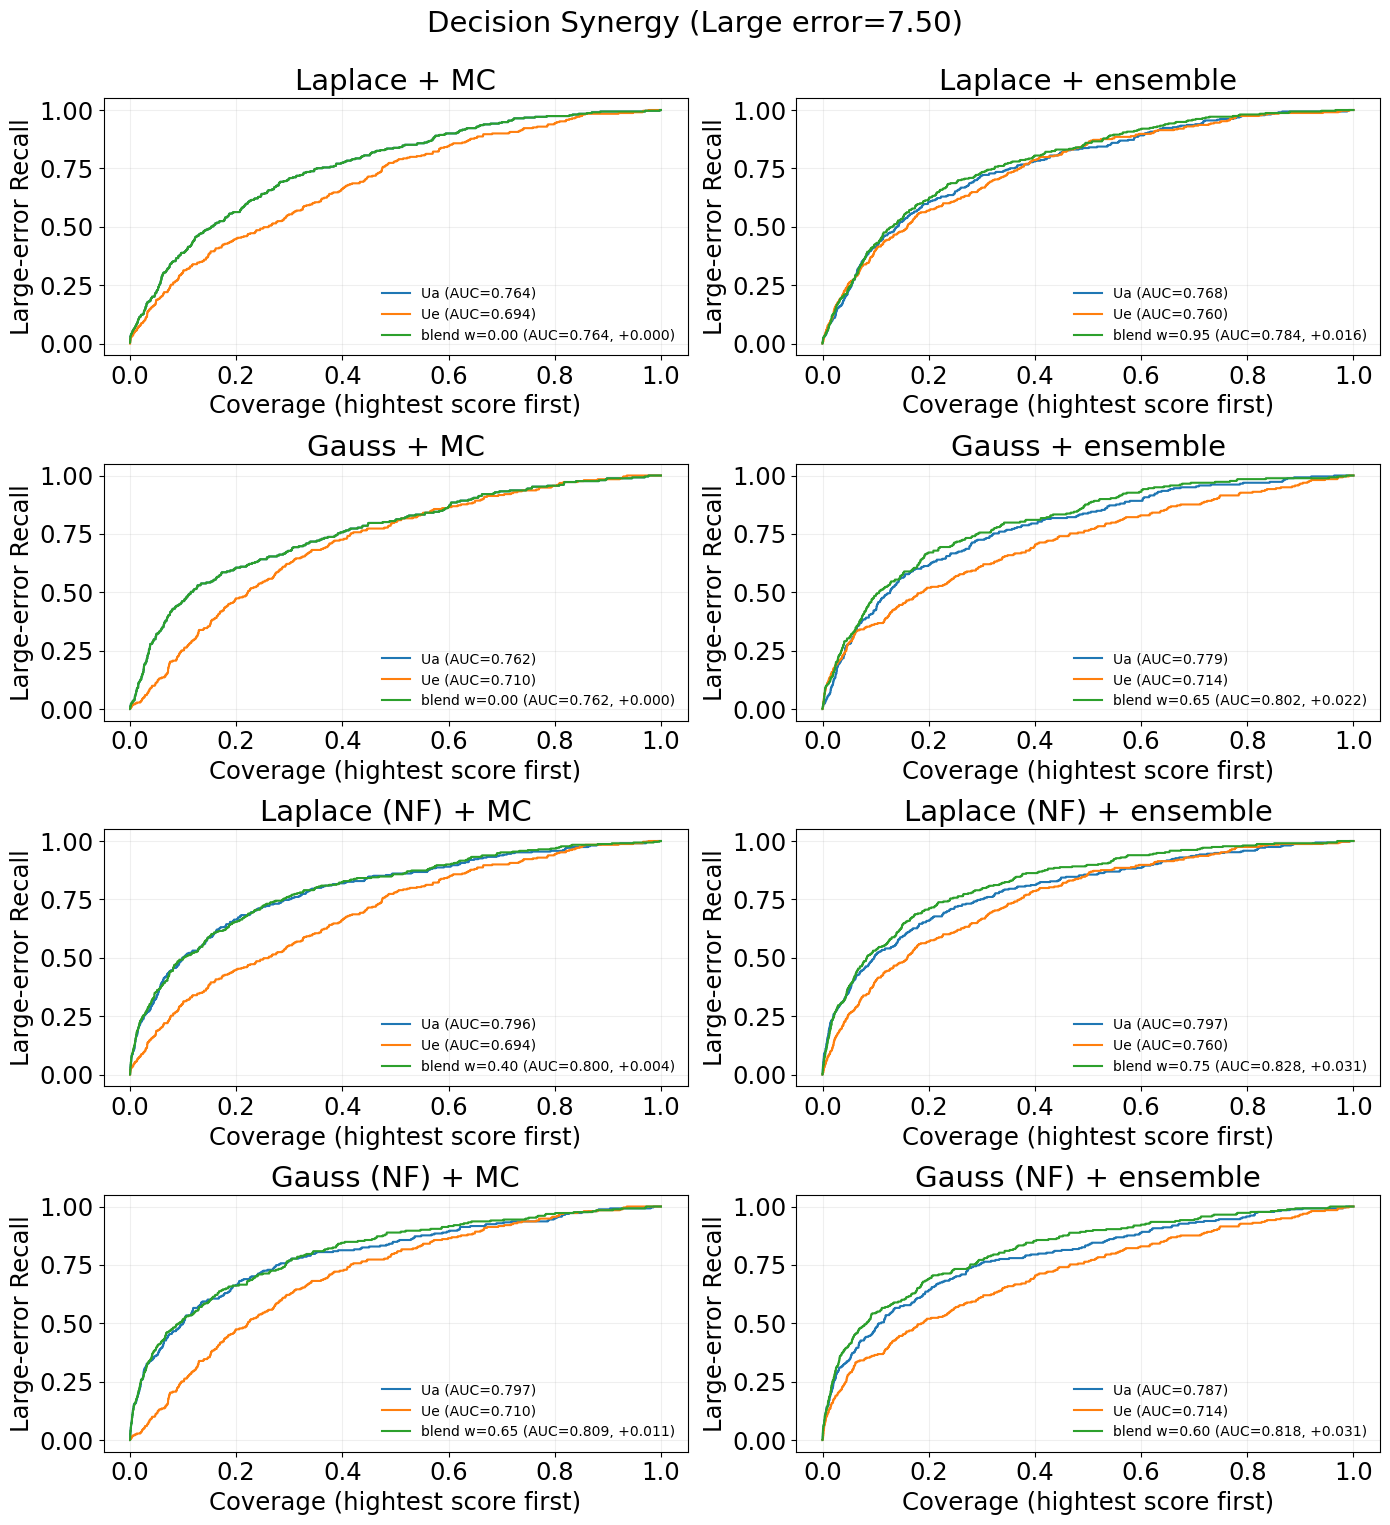

In [100]:
# Phase 8F: decision synergy (ALE vs EPI vs BLEND)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WEIGHTS = np.linspace(0.0, 1.0, 21)
COLOR_ALE = "tab:blue"
COLOR_EPI = "tab:orange"
COLOR_BLEND = "tab:green"

try:
    TAU = float(TAU)
except Exception as e:
    raise RuntimeError("TAU not defined; run the large-error cell first.") from e

# ----------------- font scaling -----------------
FONT_SCALE = 1.75
from matplotlib.font_manager import FontProperties

def _to_points(v, fallback=10.0) -> float:
    try:
        return float(FontProperties(size=v).get_size_in_points())
    except Exception:
        try:
            return float(v)
        except Exception:
            return float(fallback)

TITLE_SIZE = _to_points(plt.rcParams.get("axes.titlesize", 12)) * FONT_SCALE
LABEL_SIZE = _to_points(plt.rcParams.get("axes.labelsize", 10)) * FONT_SCALE
TICK_SIZE = _to_points(plt.rcParams.get("xtick.labelsize", 10)) * FONT_SCALE
LEGEND_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10)) * FONT_SCALE
SUPTITLE_SIZE = _to_points(plt.rcParams.get("figure.titlesize", plt.rcParams.get("axes.titlesize", 12))) * FONT_SCALE

# keep annotation font unscaled
ANNOT_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10))
# -----------------------------------------------

def _auc_from_scores(scores: np.ndarray, labels: np.ndarray) -> float:
    order = np.argsort(scores)[::-1]
    y = labels[order].astype(float)
    if y.sum() == 0:
        return float("nan")
    recall = np.cumsum(y) / y.sum()
    coverage = (np.arange(len(y)) + 1) / len(y)
    return float(np.trapezoid(recall, coverage))

if not SPECS_EPI:
    print("[synergy] No epistemic methods available.")
else:
    ncols = 2
    nrows = int(np.ceil(len(SPECS_EPI) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)

    for ax, spec in zip(axes, SPECS_EPI):
        try:
            df_all = _gather_eval_frames(spec)
        except Exception as e:
            ax.set_axis_off()
            ax.set_title(f"{spec.label} (skip: {type(e).__name__})", fontsize=TITLE_SIZE)
            continue

        if "y_true" not in df_all.columns or "mu" not in df_all.columns:
            ax.set_axis_off()
            ax.set_title(f"{spec.label} (missing y_true/mu)", fontsize=TITLE_SIZE)
            continue

        y = pd.to_numeric(df_all["y_true"], errors="coerce").to_numpy(float)
        mu = pd.to_numeric(df_all["mu"], errors="coerce").to_numpy(float)
        err = np.abs(y - mu)
        is_large = err > TAU

        s_a, s_e, _ = _sigmas(spec, df_all)
        mask = np.isfinite(s_a) & np.isfinite(s_e) & np.isfinite(err)
        if mask.sum() == 0 or is_large[mask].sum() == 0:
            ax.set_axis_off()
            ax.set_title(f"{spec.label} (no large errors)", fontsize=TITLE_SIZE)
            continue

        s_a = s_a[mask]
        s_e = s_e[mask]
        y_large = is_large[mask]

        auc_ale = _auc_from_scores(s_a, y_large)
        auc_epi = _auc_from_scores(s_e, y_large)

        best_w, best_auc = 0.0, -np.inf
        best_scores = None
        for w in WEIGHTS:
            blend = w * s_e + (1.0 - w) * s_a
            auc = _auc_from_scores(blend, y_large)
            if np.isfinite(auc) and auc > best_auc:
                best_auc = auc
                best_w = w
                best_scores = blend

        def _plot_curve(scores, label, color):
            order = np.argsort(scores)[::-1]
            y = y_large[order].astype(float)
            recall = np.cumsum(y) / y.sum()
            coverage = (np.arange(len(y)) + 1) / len(y)
            ax.plot(coverage, recall, label=label, color=color)

        _plot_curve(s_a, f"Ua (AUC={auc_ale:.3f})", COLOR_ALE)
        _plot_curve(s_e, f"Ue (AUC={auc_epi:.3f})", COLOR_EPI)
        if best_scores is not None:
            synergy = best_auc - max(auc_ale, auc_epi)
            _plot_curve(best_scores, f"blend w={best_w:.2f} (AUC={best_auc:.3f}, +{synergy:.3f})", COLOR_BLEND)

        ax.set_title(spec.label, fontsize=TITLE_SIZE)
        ax.set_xlabel("Coverage (hightest score first)", fontsize=LABEL_SIZE)
        ax.set_ylabel("Large-error Recall", fontsize=LABEL_SIZE)
        ax.tick_params(axis="both", which="both", labelsize=TICK_SIZE)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=ANNOT_SIZE, frameon=False)

    for ax in axes[len(SPECS_EPI):]:
        ax.set_axis_off()

    fig.suptitle(f"Decision Synergy (Large error={TAU:.2f})", fontsize=SUPTITLE_SIZE)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98])
    savefig(fig, f"decision_synergy_blend_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split=EVAL_SCOPE)
    plt.show()


In [101]:
# Phase 8G: unique information checks (Ua vs Ue)

import numpy as np
import pandas as pd

N_BINS = 10
EPS = 1e-8

try:
    TAU = float(TAU)
except Exception as e:
    raise RuntimeError("TAU not defined; run the large-error cell first.") from e

rows = []
for spec in SPECS_EPI:
    try:
        df_all = _gather_eval_frames(spec)
    except Exception as e:
        print(f"[skip unique] {spec.key}: {type(e).__name__}: {e}")
        continue
    if "y_true" not in df_all.columns or "mu" not in df_all.columns:
        continue

    y = pd.to_numeric(df_all["y_true"], errors="coerce").to_numpy(float)
    mu = pd.to_numeric(df_all["mu"], errors="coerce").to_numpy(float)
    err = np.abs(y - mu)
    s_a, s_e, _ = _sigmas(spec, df_all)
    mask = np.isfinite(err) & np.isfinite(s_a) & np.isfinite(s_e)
    if mask.sum() < 100:
        continue

    err = err[mask]
    s_a = s_a[mask]
    s_e = s_e[mask]

    z = err / (s_a + EPS)

    # Within Ua bins: does z rise with Ue?
    corrs = []
    try:
        bins_ua = pd.qcut(s_a, q=N_BINS, labels=False, duplicates="drop")
        for b in range(int(bins_ua.max()) + 1):
            idx = bins_ua == b
            if idx.sum() < 20:
                continue
            corr = np.corrcoef(z[idx], s_e[idx])[0, 1]
            if np.isfinite(corr):
                corrs.append(corr)
    except ValueError:
        pass
    corr_z_ue = float(np.nanmean(corrs)) if corrs else np.nan

    # Within Ue bins: does |err| rise with Ua?
    corr2 = []
    try:
        bins_ue = pd.qcut(s_e, q=N_BINS, labels=False, duplicates="drop")
        for b in range(int(bins_ue.max()) + 1):
            idx = bins_ue == b
            if idx.sum() < 20:
                continue
            c = np.corrcoef(err[idx], s_a[idx])[0, 1]
            if np.isfinite(c):
                corr2.append(c)
    except ValueError:
        pass
    corr_err_ua = float(np.nanmean(corr2)) if corr2 else np.nan

    rows.append({
        "method": spec.label,
        "key": spec.key,
        "corr_z_vs_ue_within_ua": corr_z_ue,
        "corr_err_vs_ua_within_ue": corr_err_ua,
    })

df_unique = pd.DataFrame(rows)
EXPORTER.export_table(df_unique, "unique_information", dataset=DATASET_KEY, split=EVAL_SCOPE)
display(df_unique)



,method,key,corr_z_vs_ue_within_ua,corr_err_vs_ua_within_ue
0,Laplace + MC,lpl_mc,-0.086140,0.213658
1,Laplace + ensemble,esm_lpl,0.053513,0.149331
2,Gauss + MC,gau_mc,-0.087465,0.212742
3,Gauss + ensemble,esm_gau,0.055117,0.218281
4,Laplace (NF) + MC,nf_lpl_mc,0.054105,0.280935
5,Laplace (NF) + ensemble,nf_lpl_ensemble,0.046513,0.286335
6,Gauss (NF) + MC,nf_gau_mc,0.039712,0.277763
7,Gauss (NF) + ensemble,nf_gau_ensemble,0.063237,0.262930


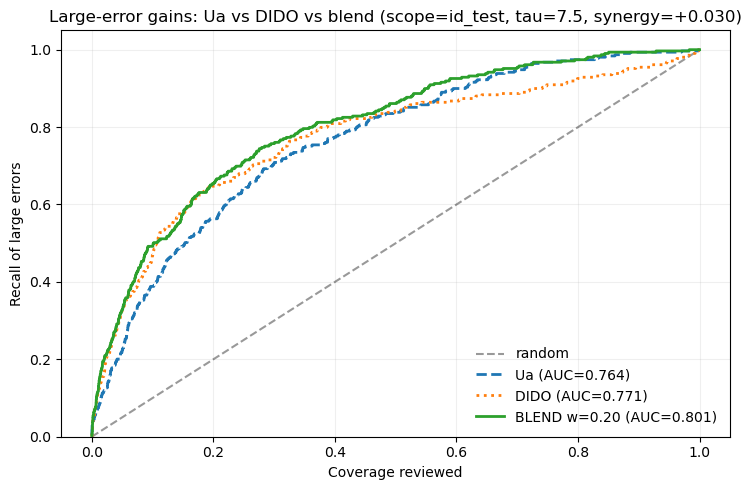

In [102]:
# Phase 8H: DIDO synergy (Ua vs DIDO vs blend)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
EVAL_SCOPE_LOCAL = "id_test"  # "id_test" | "id_test+ood"
OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []
WEIGHTS = np.linspace(0.0, 1.0, 21)

DIDO_SIGNAL = settings.get("dido_signal", "dido_strength_raw")
DIDO_CANDIDATES = ["dido_entropy_raw", "dido_vacuity_raw", "dido_strength_raw"]
DIDO_ALLOW_FLIP = True

try:
    TAU = float(TAU)
except Exception as e:
    raise RuntimeError("TAU not defined; run the large-error cell first.") from e


def _gains(score: np.ndarray, y_large: np.ndarray):
    d = pd.DataFrame({"score": score, "y": y_large}).dropna()
    if d.empty or d["y"].nunique() < 2:
        return None
    d = d.sort_values("score", ascending=False, kind="mergesort")
    total_pos = float(d["y"].sum())
    if total_pos == 0:
        return None
    cum_pos = d["y"].cumsum().to_numpy(float)
    recall = cum_pos / total_pos
    coverage = np.arange(1, len(d) + 1) / float(len(d))
    auc = float(np.trapezoid(recall, coverage))
    return coverage, recall, auc


def _load_for_scope(spec: MethodSpec) -> pd.DataFrame:
    parts = []
    df_id = method_id_frame(spec, "test").copy()
    df_id["dataset"] = "id:test"
    parts.append(df_id)

    if EVAL_SCOPE_LOCAL.strip().lower() == "id_test+ood":
        for ood_label in OOD_LABELS_LOCAL:
            try:
                df_o = method_ood_frame(spec, ood_label).copy()
                df_o["dataset"] = f"ood:{ood_label}"
                parts.append(df_o)
            except Exception as e:
                print(f"[skip] {spec.label} / ood={ood_label}: {type(e).__name__}: {e}")

    return pd.concat(parts, ignore_index=True)


base_spec = next((m for m in METHODS if m.key == "lpl_mc"), None)
if base_spec is None:
    print("[dido synergy] Laplace + MC not available; skipping.")
else:
    dido_spec = next((m for m in METHODS if m.kind == "dido" and m.key == "dido_lpl"), None)
    if dido_spec is None:
        print("[dido synergy] DIDO Laplace not available; skipping.")
    else:
        try:
            df_d = _load_for_scope(dido_spec)
        except Exception as e:
            print(f"[dido synergy] failed to load DIDO: {type(e).__name__}: {e}")
            df_d = None

        if df_d is not None:
            if str(DIDO_SIGNAL).lower() == "auto":
                dido_col = next((c for c in DIDO_CANDIDATES if c in df_d.columns), None)
            else:
                dido_col = DIDO_SIGNAL if DIDO_SIGNAL in df_d.columns else None
            if dido_col is None:
                print(f"[dido synergy] DIDO signal not found: {DIDO_SIGNAL!r}")
            else:
                df_pred = _load_for_scope(base_spec)
                if "id" not in df_d.columns or "id" not in df_pred.columns:
                    print("[dido synergy] Missing 'id' for joining; skipping.")
                else:
                    dd = df_d.copy()
                    pp = df_pred[["id", "y_true", "mu", "sigma_ale_raw", "sigma_epi_raw"]].copy()
                    dd["id"] = pd.to_numeric(dd["id"], errors="coerce")
                    pp["id"] = pd.to_numeric(pp["id"], errors="coerce")
                    dd = dd.dropna(subset=["id"])
                    pp = pp.dropna(subset=["id"])
                    dd["id"] = dd["id"].astype(int)
                    pp["id"] = pp["id"].astype(int)

                    merged = dd.merge(pp, on="id", how="inner")
                    if merged.empty:
                        print("[dido synergy] No overlap between DIDO and base preds.")
                    else:
                        y = merged["y_true"].to_numpy(float)
                        mu = merged["mu"].to_numpy(float)
                        abs_err = np.abs(y - mu)
                        yL = (abs_err > TAU).astype(int)

                        s_a_raw = merged.get("sigma_ale_raw", pd.Series(np.nan, index=merged.index)).to_numpy(float)
                        s_e_raw = merged.get("sigma_epi_raw", pd.Series(np.nan, index=merged.index)).fillna(0.0).to_numpy(float)
                        if USE_CALIBRATED_SIGMAS_LOCAL:
                            s_a, _, _ = calibrated_sigmas(
                                head_type=base_spec.head_type,
                                ale_src=base_spec.aleatoric_source,
                                epi_src=base_spec.epistemic_source,
                                sigma_ale_raw=s_a_raw,
                                sigma_epi_raw=s_e_raw,
                            )
                        else:
                            s_a = np.asarray(s_a_raw, float)

                        dido = pd.to_numeric(merged[dido_col], errors="coerce").to_numpy(float)
                        if DIDO_ALLOW_FLIP:
                            g_pos = _gains(dido, yL)
                            g_neg = _gains(-dido, yL)
                            if g_neg is not None and (g_pos is None or g_neg[2] > g_pos[2]):
                                dido = -dido
                                dido_col = dido_col + " (flipped)"

                        g_ua = _gains(s_a, yL)
                        g_dido = _gains(dido, yL)

                        best = {"w": None, "auc": -np.inf, "g": None}
                        for w in WEIGHTS:
                            score = (1.0 - w) * s_a + w * dido
                            g = _gains(score, yL)
                            if g is None:
                                continue
                            if g[2] > best["auc"]:
                                best = {"w": float(w), "auc": float(g[2]), "g": g}

                        synergy = float(best["auc"] - max(g_ua[2], g_dido[2])) if best["g"] is not None else float("nan")

                        plt.figure(figsize=(7.5, 5))
                        plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
                        plt.plot(g_ua[0], g_ua[1], "--", lw=2, label=f"Ua (AUC={g_ua[2]:.3f})")
                        plt.plot(g_dido[0], g_dido[1], ":", lw=2, label=f"DIDO (AUC={g_dido[2]:.3f})")
                        if best["g"] is not None:
                            plt.plot(best["g"][0], best["g"][1], "-", lw=2, label=f"BLEND w={best['w']:.2f} (AUC={best['auc']:.3f})")
                        plt.xlabel("Coverage reviewed")
                        plt.ylabel("Recall of large errors")
                        plt.title(f"Large-error gains: Ua vs DIDO vs blend (scope={EVAL_SCOPE_LOCAL}, tau={TAU:.3g}, synergy={synergy:+.3f})")
                        plt.ylim(0, 1.05)
                        plt.grid(True, alpha=0.2)
                        plt.legend(frameon=False)
                        plt.tight_layout()
                        # savefig(plt.gcf(), f"dido_synergy_{EVAL_SCOPE_LOCAL}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}", dataset=DATASET_KEY, split=EVAL_SCOPE_LOCAL)
                        plt.show()


## Phase 9: NF vs analytic + cohort diagnostics

Compare NF vs analytic heads and diagnose cohort coverage differences.

## Phase 10: Signal Decoupling



In [103]:
# # Phase 10A: Contribution decomposition of total (Ua vs Ue) — stacked bars (ID only)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True
# OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

# # ---- toggles ----
# INCLUDE_OOD = False
# REQUIRE_EPI = True                   # require epistemic_source in {"mc","ensemble"} for decomposition
# INCLUDE_NF_VARIANTS = True           # include aleatoric_source == "nf" variants
# RNG_SEED = 1
# X_PAD = 0.02                         # expand x-limits to [-X_PAD, 1+X_PAD]
# LEGEND_NCOL = 2
# LEGEND_Y = 0.02                      # figure coords
# LEGEND_RECT_BOTTOM = 0.08            # reserve bottom space for legend
# # -----------------

# rng = np.random.default_rng(RNG_SEED)


# def _is_nf_variant(spec: MethodSpec) -> bool:
#     return str(getattr(spec, "aleatoric_source", "")).lower() == "nf" or getattr(spec, "kind", None) == "nf"


# def _sigmas(spec: MethodSpec, df: pd.DataFrame):
#     s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
#     s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").to_numpy(float)
#     miss_epi = ~np.isfinite(s_e_raw)
#     s_e0 = np.nan_to_num(s_e_raw, nan=0.0)

#     if USE_CALIBRATED_SIGMAS_LOCAL:
#         s_a, s_e, s_t = calibrated_sigmas(
#             head_type=spec.head_type,
#             ale_src=spec.aleatoric_source,
#             epi_src=spec.epistemic_source,
#             sigma_ale_raw=s_a_raw,
#             sigma_epi_raw=s_e0,
#         )
#         s_e = np.asarray(s_e, float)
#         s_e[miss_epi] = np.nan
#         return np.asarray(s_a, float), s_e, np.asarray(s_t, float)

#     s_a = np.asarray(s_a_raw, float)
#     s_e = np.asarray(s_e_raw, float)
#     s_t = np.sqrt(np.maximum(np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2, 0.0))
#     return s_a, s_e, s_t


# def _contrib_fracs(s_a: np.ndarray, s_e: np.ndarray):
#     a2 = np.square(np.asarray(s_a, float))
#     e2 = np.square(np.asarray(s_e, float))
#     denom = a2 + e2
#     m = np.isfinite(denom) & (denom > 0) & np.isfinite(a2) & np.isfinite(e2)
#     frac_a = np.full_like(denom, np.nan, dtype=float)
#     frac_e = np.full_like(denom, np.nan, dtype=float)
#     frac_a[m] = a2[m] / denom[m]
#     frac_e[m] = e2[m] / denom[m]
#     return frac_a, frac_e


# def _summarize(x: np.ndarray):
#     x = np.asarray(x, float)
#     x = x[np.isfinite(x)]
#     if x.size == 0:
#         return {"n": 0, "p50": np.nan}
#     return {"n": int(x.size), "p50": float(np.quantile(x, 0.50))}


# def _place_bottom_legend(fig, handles, labels):
#     fig.legend(
#         handles,
#         labels,
#         loc="lower center",
#         bbox_to_anchor=(0.5, LEGEND_Y),
#         ncol=LEGEND_NCOL,
#         frameon=False,
#     )


# # Select methods
# specs = []
# for m in METHODS:
#     if m.kind == "dido" or m.head_type == "point":
#         continue
#     epi = str(m.epistemic_source).lower()
#     if REQUIRE_EPI and epi not in {"mc", "ensemble"}:
#         continue
#     if (not INCLUDE_NF_VARIANTS) and _is_nf_variant(m):
#         continue
#     specs.append(m)

# if not specs:
#     print("[phase10] No methods selected for decomposition.")
# else:
#     rows = []
#     for spec in specs:
#         try:
#             df_id0 = method_id_frame(spec, "test").copy()
#         except Exception as e:
#             print(f"[skip phase10] {spec.label}: {type(e).__name__}: {e}")
#             continue

#         s_a_id, s_e_id, _ = _sigmas(spec, df_id0)
#         frac_a_id, frac_e_id = _contrib_fracs(s_a_id, s_e_id)

#         sa = _summarize(frac_a_id)
#         se = _summarize(frac_e_id)
#         rows.append({
#             "method": spec.label,
#             "key": spec.key,
#             "dataset": "id:test",
#             "n": sa["n"],
#             "ale_frac_p50": sa["p50"],
#             "epi_frac_p50": se["p50"],
#         })

#     if not rows:
#         print("[phase10] No decomposition rows produced.")
#     else:
#         df_summary = pd.DataFrame(rows).reset_index(drop=True)
#         EXPORTER.export_table(
#             df_summary,
#             f"decomp_total_contrib_id_only_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
#             dataset=DATASET_KEY,
#             split="test",
#         )
#         display(df_summary)

#         df_wide = df_summary.copy()
#         df_wide["epi_p50"] = pd.to_numeric(df_wide["epi_frac_p50"], errors="coerce")
#         df_wide["ale_p50"] = pd.to_numeric(df_wide["ale_frac_p50"], errors="coerce")
#         df_wide = df_wide[np.isfinite(df_wide["epi_p50"]) & np.isfinite(df_wide["ale_p50"])].copy()
#         df_wide = df_wide.sort_values("epi_p50", ascending=True).reset_index(drop=True)

#         y = np.arange(len(df_wide))
#         epi = df_wide["epi_p50"].to_numpy(float)
#         ale = df_wide["ale_p50"].to_numpy(float)

#         fig, ax = plt.subplots(figsize=(10, max(4.5, 0.35 * len(df_wide))))

#         # Epistemic on the LEFT, Aleatoric on the RIGHT
#         ax.barh(y, epi, color="tab:orange", label="Epistemic (median)")
#         ax.barh(y, ale, left=epi, color="tab:blue", label="Aleatoric (median)")

#         ax.set_yticks(y)
#         ax.set_yticklabels(df_wide["method"].tolist())
#         ax.invert_yaxis()
#         ax.set_xlim(-X_PAD, 1.0 + X_PAD)
#         ax.set_xlabel("Median fraction of total (Ue²/(Ua²+Ue²) + Ua²/(Ua²+Ue²) = 1)")
#         ax.set_title(f"Total uncertainty decomposition (median) — ID:test ({'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'})")
#         ax.grid(True, axis="x", alpha=0.2)

#         # annotate ALE fraction inside the BLUE segment (white text)
#         for yi, e, a in zip(y, epi, ale):
#             if not (np.isfinite(e) and np.isfinite(a)) or a <= 0:
#                 continue
#             x_center = e + 0.5 * a
#             ax.text(x_center, yi, f"{a:.3f}", va="center", ha="center", fontsize=9, color="white")

#         # figure-level legend (won't overlap xlabel)
#         handles, labels = ax.get_legend_handles_labels()
#         _place_bottom_legend(fig, handles, labels)

#         # reserve bottom space for legend
#         fig.tight_layout(rect=[0, LEGEND_RECT_BOTTOM, 1, 1])

#         savefig(
#             fig,
#             f"decomp_total_contrib_stacked_id_only_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
#             dataset=DATASET_KEY,
#             split="test",
#         )
#         plt.show()


In [104]:
# # Phase 10B: 2D interaction map (Ua vs Ue) with outcome overlays (ID and optionally OOD)
# # Hexbin in (Ua, Ue) space colored by large-error rate or mean |err|.
# # Updated: single figure grid with 2 columns (Gauss left, Laplace right)
# # Update requested: do NOT share x/y axes across subplots.

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from typing import Optional, Dict, Tuple

# # ----------------- toggles (set here) -----------------
# USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

# INCLUDE_OOD = False
# OOD_LABEL_FOR_PLOTS = (list(OOD_LABELS)[0] if "OOD_LABELS" in globals() and list(OOD_LABELS) else None)  # e.g. "knn"

# INCLUDE_NF_VARIANTS = True  # include (NF) variants if present
# APPLY_KNN_BANDS_LOCAL = True

# PLOT_METRIC = "mae"  # "large_rate" | "mae"   (color in hexbin)
# USE_LOG10_AXES = False
# LOG_EPS = 1e-6

# GRIDSIZE = 55
# MINCNT = 40

# SHOW_CONTOURS = False
# CONTOUR_BINS = 45
# CONTOUR_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5]  # large-error probability

# QUANTILE_LIMITS = (0.01, 0.99)  # axis limits from combined data per method

# METHOD_KEYS = []  # optional: e.g. ["gau_mc", "esm_gau", "lpl_mc", "esm_lpl"]; leave [] for auto
# # ------------------------------------------------------

# try:
#     TAU_LOCAL = float(TAU)
# except Exception as e:
#     raise RuntimeError("TAU not defined; run the large-error threshold cell first.") from e

# OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []


# def _is_nf_variant(spec: "MethodSpec") -> bool:
#     return str(getattr(spec, "aleatoric_source", "")).lower() == "nf" or getattr(spec, "kind", None) == "nf"


# def _maybe_apply_knn(df_id: pd.DataFrame, df_ood: pd.DataFrame, ood_label: str, key: str):
#     if APPLY_KNN_BANDS_LOCAL and "apply_knn_bands" in globals():
#         try:
#             return apply_knn_bands(df_id, df_ood, ood_label, key)
#         except Exception as e:
#             print(f"[knn bands skip] {key}/{ood_label}: {type(e).__name__}: {e}")
#     return df_id, df_ood


# def _sigmas(spec: "MethodSpec", df: pd.DataFrame):
#     s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
#     s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").to_numpy(float)
#     miss_epi = ~np.isfinite(s_e_raw)
#     s_e0 = np.nan_to_num(s_e_raw, nan=0.0)

#     if USE_CALIBRATED_SIGMAS_LOCAL:
#         s_a, s_e, _s_t = calibrated_sigmas(
#             head_type=spec.head_type,
#             ale_src=spec.aleatoric_source,
#             epi_src=spec.epistemic_source,
#             sigma_ale_raw=s_a_raw,
#             sigma_epi_raw=s_e0,
#         )
#         s_e = np.asarray(s_e, float)
#         s_e[miss_epi] = np.nan
#         return np.asarray(s_a, float), s_e

#     return np.asarray(s_a_raw, float), np.asarray(s_e_raw, float)


# def _load_slice(spec: "MethodSpec", which: str, ood_label: Optional[str]):
#     if which == "id:test":
#         return method_id_frame(spec, "test").copy()
#     if which.startswith("ood:"):
#         if not ood_label:
#             raise ValueError("ood_label is None")
#         return method_ood_frame(spec, ood_label).copy()
#     raise ValueError(which)


# def _prep_arrays(spec: "MethodSpec", df: pd.DataFrame):
#     if "y_true" not in df.columns or "mu" not in df.columns:
#         return None
#     y = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(float)
#     mu = pd.to_numeric(df["mu"], errors="coerce").to_numpy(float)
#     abs_err = np.abs(y - mu)
#     is_large = (abs_err > TAU_LOCAL).astype(float)

#     s_a, s_e = _sigmas(spec, df)

#     m = np.isfinite(s_a) & np.isfinite(s_e) & np.isfinite(abs_err)
#     if not np.any(m):
#         return None

#     ua = s_a[m]
#     ue = s_e[m]
#     abs_err = abs_err[m]
#     is_large = is_large[m]

#     if USE_LOG10_AXES:
#         ua = np.log10(np.maximum(ua, LOG_EPS))
#         ue = np.log10(np.maximum(ue, LOG_EPS))

#     return ua, ue, abs_err, is_large


# def _hexbin_panel(ax, ua, ue, abs_err, is_large, title: str, vmin=None, vmax=None):
#     if PLOT_METRIC == "mae":
#         C = abs_err
#         cbar_label = "Mean |err| in bin"
#         cmap = "viridis"
#     else:
#         C = is_large
#         cbar_label = f"P(|err| > {TAU_LOCAL:.3g}) in bin"
#         cmap = "magma"

#     hb = ax.hexbin(
#         ua,
#         ue,
#         C=C,
#         reduce_C_function=np.mean,
#         gridsize=GRIDSIZE,
#         mincnt=MINCNT,
#         cmap=cmap,
#         vmin=vmin,
#         vmax=vmax,
#     )

#     if SHOW_CONTOURS:
#         xlo, xhi = np.quantile(ua, QUANTILE_LIMITS)
#         ylo, yhi = np.quantile(ue, QUANTILE_LIMITS)
#         xedges = np.linspace(xlo, xhi, CONTOUR_BINS + 1)
#         yedges = np.linspace(ylo, yhi, CONTOUR_BINS + 1)

#         counts, _, _ = np.histogram2d(ua, ue, bins=[xedges, yedges])
#         sum_large, _, _ = np.histogram2d(ua, ue, bins=[xedges, yedges], weights=is_large)
#         with np.errstate(invalid="ignore", divide="ignore"):
#             rate = sum_large / counts

#         xc = 0.5 * (xedges[:-1] + xedges[1:])
#         yc = 0.5 * (yedges[:-1] + yedges[1:])
#         Xc, Yc = np.meshgrid(xc, yc, indexing="xy")

#         ok = np.isfinite(rate) & (counts >= MINCNT)
#         if np.any(ok):
#             rate_plot = np.where(ok, rate, np.nan)
#             ax.contour(
#                 Xc,
#                 Yc,
#                 rate_plot.T,
#                 levels=CONTOUR_LEVELS,
#                 colors="white",
#                 linewidths=1.0,
#                 alpha=0.85,
#             )

#     ax.set_title(title)
#     ax.grid(True, alpha=0.15)

#     if USE_LOG10_AXES:
#         ax.set_xlabel("log10(Ua)")
#         ax.set_ylabel("log10(Ue)")
#     else:
#         ax.set_xlabel("Ua")
#         ax.set_ylabel("Ue")

#     return hb, cbar_label


# # ----------------------------
# # Select methods
# # ----------------------------
# if METHOD_KEYS:
#     key_to_spec = {m.key: m for m in METHODS}
#     specs = [key_to_spec[k] for k in METHOD_KEYS if k in key_to_spec]
# else:
#     specs = []
#     for m in METHODS:
#         if m.kind == "dido" or m.head_type == "point":
#             continue
#         epi = str(m.epistemic_source).lower()
#         if epi not in {"mc", "ensemble"}:
#             continue
#         if (not INCLUDE_NF_VARIANTS) and _is_nf_variant(m):
#             continue
#         specs.append(m)

# if not specs:
#     print("[phase10B] No methods selected (need epi_source in {mc, ensemble}).")
# else:
#     if INCLUDE_OOD and not OOD_LABEL_FOR_PLOTS:
#         print("[phase10B] INCLUDE_OOD=True but no OOD label available; plotting ID only.")
#         INCLUDE_OOD = False

#     # ----------------------------
#     # Helpers: group + pairing key
#     # ----------------------------
#     def _head_group(spec: "MethodSpec") -> Optional[str]:
#         ht = str(getattr(spec, "head_type", "")).lower()
#         if ht.startswith("gau") or "gauss" in ht or "gaussian" in ht or ht == "normal":
#             return "gauss"
#         if ht.startswith("lpl") or "laplace" in ht or "laplacian" in ht:
#             return "laplace"
#         return None

#     def _pair_key(spec: "MethodSpec") -> str:
#         k = str(getattr(spec, "key", getattr(spec, "label", ""))).lower()
#         for tok in ("gaussian", "gauss", "gau", "laplace", "lpl"):
#             k = k.replace(tok, "")
#         while "__" in k:
#             k = k.replace("__", "_")
#         return k.strip("_")

#     rng = np.random.default_rng(0)

#     def _sample(a: np.ndarray, max_n: int) -> np.ndarray:
#         a = np.asarray(a)
#         if a.size <= max_n:
#             return a
#         idx = rng.choice(a.size, size=max_n, replace=False)
#         return a[idx]

#     # ----------------------------
#     # Build pairs: {pair_key: {gauss: spec, laplace: spec}}
#     # ----------------------------
#     pairs: Dict[str, Dict[str, "MethodSpec"]] = {}
#     for spec in specs:
#         grp = _head_group(spec)
#         if grp is None:
#             continue
#         pk = _pair_key(spec)
#         pairs.setdefault(pk, {})[grp] = spec

#     base_keys = sorted(pairs.keys())

#     if not base_keys:
#         print("[phase10B] No gaussian/laplace methods found after grouping.")
#     else:
#         # ----------------------------
#         # Precompute packs for each spec (ID and optionally OOD)
#         # ----------------------------
#         pack_by_spec_slice: Dict[Tuple[str, str], Optional[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]] = {}

#         # For global axis + color limits (cap samples to keep memory predictable)
#         ua_samp, ue_samp, c_samp = [], [], []
#         MAX_SAMP_PER_PACK = 200_000

#         for pk in base_keys:
#             for grp in ("gauss", "laplace"):
#                 spec = pairs[pk].get(grp)
#                 if spec is None:
#                     continue

#                 # load ID
#                 try:
#                     df_id = _load_slice(spec, "id:test", None)
#                 except Exception as e:
#                     print(f"[skip phase10B] {spec.label} id:test: {type(e).__name__}: {e}")
#                     pack_by_spec_slice[(spec.key, "id")] = None
#                     pack_by_spec_slice[(spec.key, "ood")] = None
#                     continue

#                 df_ood = None
#                 if INCLUDE_OOD:
#                     try:
#                         df_ood0 = _load_slice(spec, f"ood:{OOD_LABEL_FOR_PLOTS}", OOD_LABEL_FOR_PLOTS)
#                         df_id2, df_ood = _maybe_apply_knn(df_id.copy(), df_ood0, OOD_LABEL_FOR_PLOTS, spec.key)
#                         df_id = df_id2
#                     except Exception as e:
#                         print(f"[skip phase10B] {spec.label} ood:{OOD_LABEL_FOR_PLOTS}: {type(e).__name__}: {e}")
#                         df_ood = None

#                 pack_id = _prep_arrays(spec, df_id)
#                 if pack_id is None:
#                     print(f"[skip phase10B] {spec.label} id:test: missing y_true/mu or no finite Ua/Ue.")
#                 pack_by_spec_slice[(spec.key, "id")] = pack_id

#                 pack_ood = None
#                 if INCLUDE_OOD and df_ood is not None:
#                     pack_ood = _prep_arrays(spec, df_ood)
#                     if pack_ood is None:
#                         print(
#                             f"[skip phase10B] {spec.label} ood:{OOD_LABEL_FOR_PLOTS}: missing y_true/mu or no finite Ua/Ue."
#                         )
#                 pack_by_spec_slice[(spec.key, "ood")] = pack_ood

#                 # collect samples for global limits only (NOT used to set per-axis limits now)
#                 for pack in (pack_id, pack_ood):
#                     if pack is None:
#                         continue
#                     ua, ue, abs_err, is_large = pack
#                     ua_samp.append(_sample(ua, MAX_SAMP_PER_PACK))
#                     ue_samp.append(_sample(ue, MAX_SAMP_PER_PACK))
#                     if PLOT_METRIC == "mae":
#                         c_samp.append(_sample(abs_err, MAX_SAMP_PER_PACK))
#                     else:
#                         c_samp.append(_sample(is_large, MAX_SAMP_PER_PACK))

#         # Determine GLOBAL color limits for a shared colorbar
#         if PLOT_METRIC == "mae":
#             if c_samp:
#                 c_all = np.concatenate(c_samp)
#                 vmin, vmax = np.quantile(c_all, (0.01, 0.99))
#                 if not (np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin):
#                     vmin, vmax = None, None
#             else:
#                 vmin, vmax = None, None
#         else:
#             vmin, vmax = 0.0, 1.0

#         # ----------------------------
#         # Build 2-column grid: Gauss | Laplace
#         # NOTE: sharex/sharey are False; each subplot gets its own limits
#         # ----------------------------
#         slice_rows = [("id", "ID")]
#         if INCLUDE_OOD:
#             slice_rows.append(("ood", f"OOD:{OOD_LABEL_FOR_PLOTS}"))

#         n_slices = len(slice_rows)
#         n_pairs = len(base_keys)
#         nrows = n_pairs * n_slices

#         fig_w = 13.0
#         fig_h = 4.8 * nrows
#         fig, axes = plt.subplots(
#             nrows,
#             2,
#             figsize=(fig_w, fig_h),
#             sharex=False,
#             sharey=False,
#             constrained_layout=False,
#         )
#         axes = np.atleast_2d(axes)

#         hb_for_cbar = None
#         cbar_label = None

#         for i, pk in enumerate(base_keys):
#             for j, (slice_key, slice_label) in enumerate(slice_rows):
#                 r = i * n_slices + j
#                 for c, grp in enumerate(("gauss", "laplace")):
#                     ax = axes[r, c]
#                     spec = pairs[pk].get(grp)

#                     if spec is None:
#                         ax.axis("off")
#                         continue

#                     pack = pack_by_spec_slice.get((spec.key, slice_key), None)
#                     if pack is None:
#                         ax.axis("off")
#                         continue

#                     ua, ue, abs_err, is_large = pack

#                     # per-panel axis limits (quantile-based)
#                     xlo, xhi = np.quantile(ua, QUANTILE_LIMITS)
#                     ylo, yhi = np.quantile(ue, QUANTILE_LIMITS)
#                     xpad = 0.03 * (xhi - xlo) if np.isfinite(xhi - xlo) and (xhi > xlo) else 0.1
#                     ypad = 0.03 * (yhi - ylo) if np.isfinite(yhi - ylo) and (yhi > ylo) else 0.1

#                     hb, cbar_label = _hexbin_panel(
#                         ax,
#                         ua,
#                         ue,
#                         abs_err,
#                         is_large,
#                         title=f"{spec.label} — {slice_label}",
#                         vmin=vmin,
#                         vmax=vmax,
#                     )
#                     if hb_for_cbar is None:
#                         hb_for_cbar = hb

#                     ax.set_xlim(xlo - xpad, xhi + xpad)
#                     ax.set_ylim(ylo - ypad, yhi + ypad)

#         # Layout + single shared colorbar
#         fig.subplots_adjust(top=0.965, right=0.90, hspace=0.30, wspace=0.18)

#         # Column headers
#         fig.text(0.27, 0.99, "Gaussian", ha="center", va="top", fontsize=13)
#         fig.text(0.73, 0.99, "Laplace", ha="center", va="top", fontsize=13)

#         if hb_for_cbar is not None:
#             cax = fig.add_axes([0.92, 0.10, 0.02, 0.80])
#             cbar = fig.colorbar(hb_for_cbar, cax=cax)
#             if cbar_label:
#                 cbar.set_label(cbar_label)

#         fig.suptitle(
#             f"Ua vs Ue Interaction Maps",
#             y=0.995,
#             fontsize=14,
#         )

#         tag = "id_only" if not INCLUDE_OOD else f"id_vs_ood_{OOD_LABEL_FOR_PLOTS}"
#         savefig(
#             fig,
#             f"ua_ue_interaction_grid_gauss_vs_laplace_{tag}_{PLOT_METRIC}_{'log' if USE_LOG10_AXES else 'lin'}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
#             dataset=DATASET_KEY,
#             split="test",
#         )
#         plt.show()

# print('Message: "They capture different failure modes; high-Ua isn’t the same as high-Ue."')


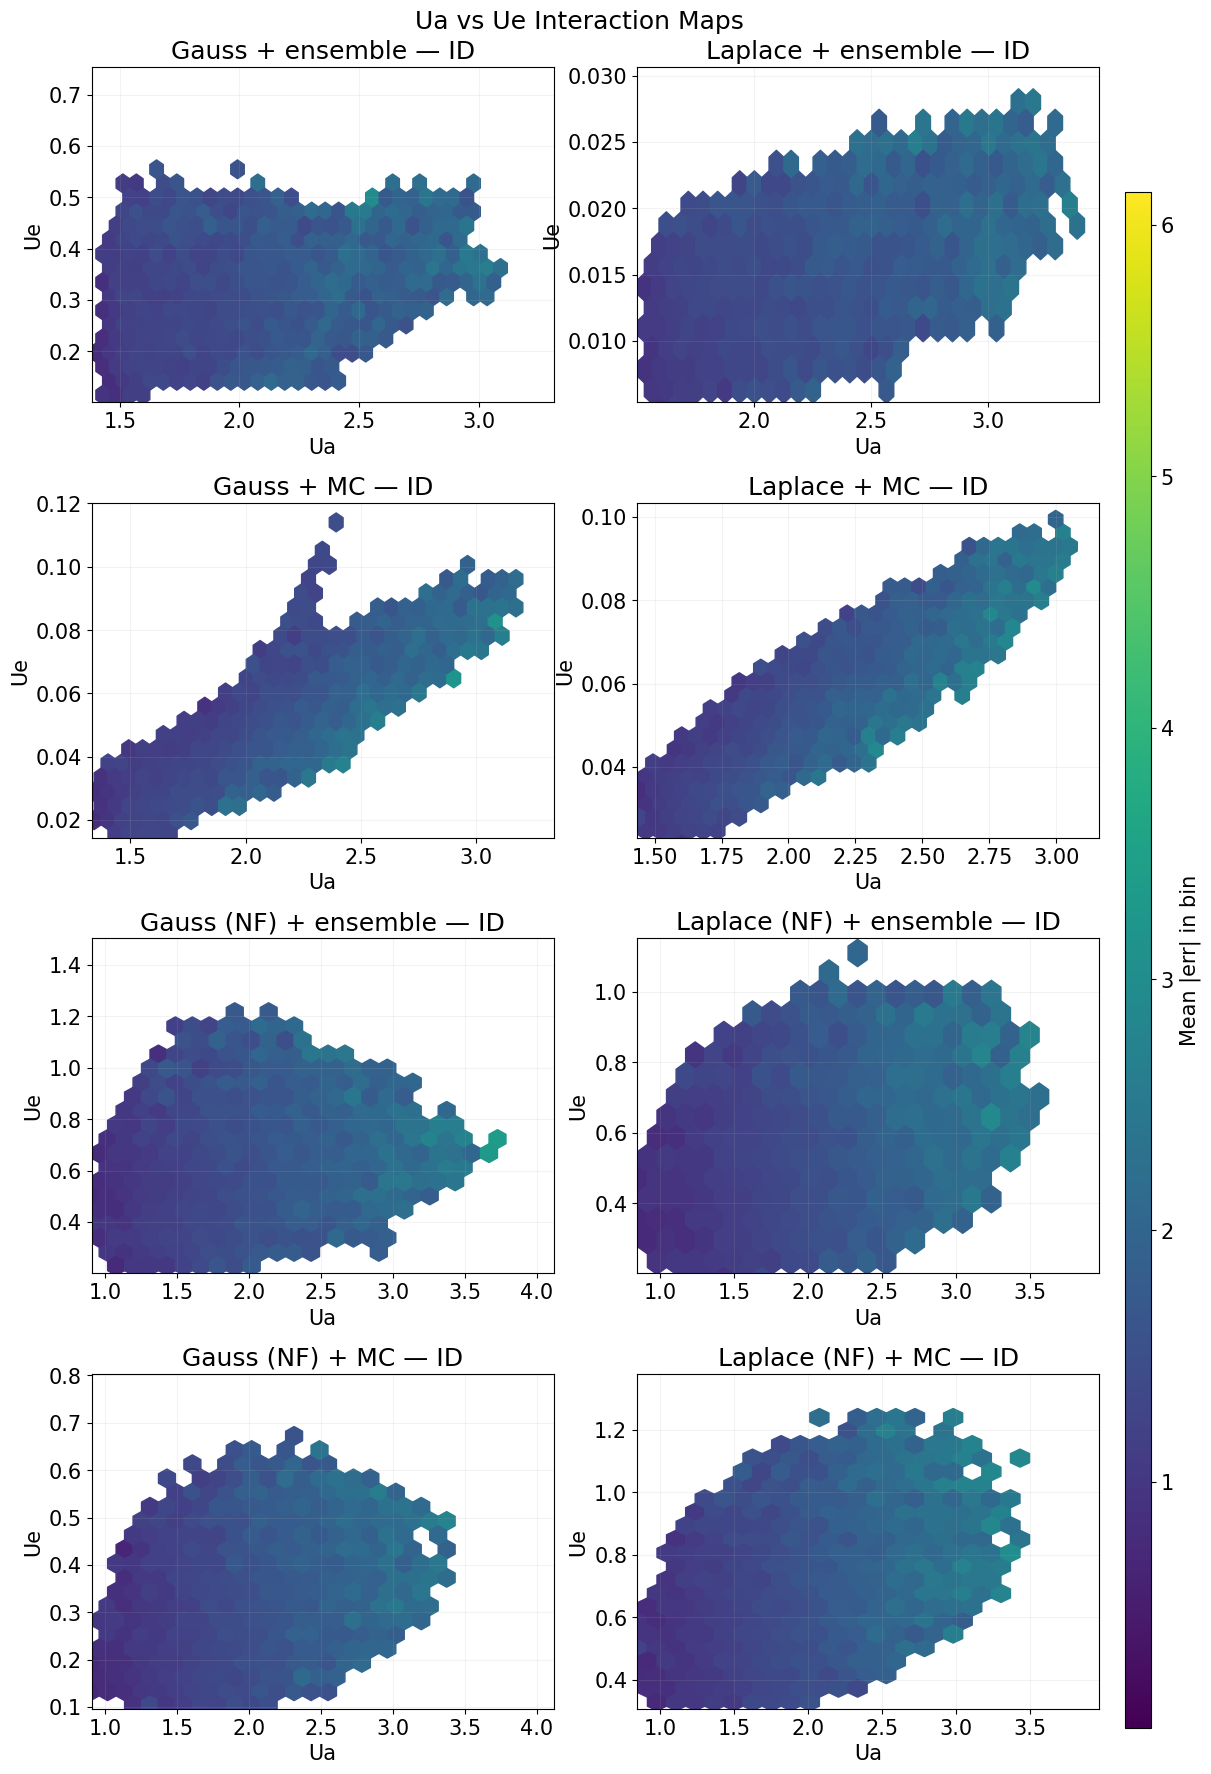

Message: "They capture different failure modes; high-Ua isn’t the same as high-Ue."


In [105]:
# Phase 10B: 2D interaction map (Ua vs Ue) with outcome overlays (ID and optionally OOD)
# Hexbin in (Ua, Ue) space colored by large-error rate or mean |err|.
# Updated: single figure grid with 2 columns (Gauss left, Laplace right)
# Update requested: do NOT share x/y axes across subplots.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, Dict, Tuple

# ----------------- toggles (set here) -----------------
USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

INCLUDE_OOD = False
OOD_LABEL_FOR_PLOTS = (list(OOD_LABELS)[0] if "OOD_LABELS" in globals() and list(OOD_LABELS) else None)  # e.g. "knn"

INCLUDE_NF_VARIANTS = True  # include (NF) variants if present
APPLY_KNN_BANDS_LOCAL = True

PLOT_METRIC = "mae"  # "large_rate" | "mae"   (color in hexbin)
USE_LOG10_AXES = False
LOG_EPS = 1e-6

GRIDSIZE = 55
MINCNT = 40

SHOW_CONTOURS = False
CONTOUR_BINS = 45
CONTOUR_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5]  # large-error probability

QUANTILE_LIMITS = (0.01, 0.99)  # axis limits from combined data per method

METHOD_KEYS = []  # optional: e.g. ["gau_mc", "esm_gau", "lpl_mc", "esm_lpl"]; leave [] for auto
# ------------------------------------------------------

try:
    TAU_LOCAL = float(TAU)
except Exception as e:
    raise RuntimeError("TAU not defined; run the large-error threshold cell first.") from e

OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []

# ----------------- font scaling -----------------
FONT_SCALE = 1.5
from matplotlib.font_manager import FontProperties

def _to_points(v, fallback=10.0) -> float:
    try:
        return float(FontProperties(size=v).get_size_in_points())
    except Exception:
        try:
            return float(v)
        except Exception:
            return float(fallback)

TITLE_SIZE = _to_points(plt.rcParams.get("axes.titlesize", 12)) * FONT_SCALE
LABEL_SIZE = _to_points(plt.rcParams.get("axes.labelsize", 10)) * FONT_SCALE
TICK_SIZE = _to_points(plt.rcParams.get("xtick.labelsize", 10)) * FONT_SCALE
LEGEND_SIZE = _to_points(plt.rcParams.get("legend.fontsize", 10)) * FONT_SCALE
SUPTITLE_SIZE = _to_points(plt.rcParams.get("figure.titlesize", plt.rcParams.get("axes.titlesize", 12))) * FONT_SCALE
# -----------------------------------------------


def _is_nf_variant(spec: "MethodSpec") -> bool:
    return str(getattr(spec, "aleatoric_source", "")).lower() == "nf" or getattr(spec, "kind", None) == "nf"


def _maybe_apply_knn(df_id: pd.DataFrame, df_ood: pd.DataFrame, ood_label: str, key: str):
    if APPLY_KNN_BANDS_LOCAL and "apply_knn_bands" in globals():
        try:
            return apply_knn_bands(df_id, df_ood, ood_label, key)
        except Exception as e:
            print(f"[knn bands skip] {key}/{ood_label}: {type(e).__name__}: {e}")
    return df_id, df_ood


def _sigmas(spec: "MethodSpec", df: pd.DataFrame):
    s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").to_numpy(float)
    miss_epi = ~np.isfinite(s_e_raw)
    s_e0 = np.nan_to_num(s_e_raw, nan=0.0)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        s_a, s_e, _s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=s_e0,
        )
        s_e = np.asarray(s_e, float)
        s_e[miss_epi] = np.nan
        return np.asarray(s_a, float), s_e

    return np.asarray(s_a_raw, float), np.asarray(s_e_raw, float)


def _load_slice(spec: "MethodSpec", which: str, ood_label: Optional[str]):
    if which == "id:test":
        return method_id_frame(spec, "test").copy()
    if which.startswith("ood:"):
        if not ood_label:
            raise ValueError("ood_label is None")
        return method_ood_frame(spec, ood_label).copy()
    raise ValueError(which)


def _prep_arrays(spec: "MethodSpec", df: pd.DataFrame):
    if "y_true" not in df.columns or "mu" not in df.columns:
        return None
    y = pd.to_numeric(df["y_true"], errors="coerce").to_numpy(float)
    mu = pd.to_numeric(df["mu"], errors="coerce").to_numpy(float)
    abs_err = np.abs(y - mu)
    is_large = (abs_err > TAU_LOCAL).astype(float)

    s_a, s_e = _sigmas(spec, df)

    m = np.isfinite(s_a) & np.isfinite(s_e) & np.isfinite(abs_err)
    if not np.any(m):
        return None

    ua = s_a[m]
    ue = s_e[m]
    abs_err = abs_err[m]
    is_large = is_large[m]

    if USE_LOG10_AXES:
        ua = np.log10(np.maximum(ua, LOG_EPS))
        ue = np.log10(np.maximum(ue, LOG_EPS))

    return ua, ue, abs_err, is_large


def _hexbin_panel(ax, ua, ue, abs_err, is_large, title: str, vmin=None, vmax=None):
    if PLOT_METRIC == "mae":
        C = abs_err
        cbar_label = "Mean |err| in bin"
        cmap = "viridis"
    else:
        C = is_large
        cbar_label = f"P(|err| > {TAU_LOCAL:.3g}) in bin"
        cmap = "magma"

    hb = ax.hexbin(
        ua,
        ue,
        C=C,
        reduce_C_function=np.mean,
        gridsize=GRIDSIZE,
        mincnt=MINCNT,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    if SHOW_CONTOURS:
        xlo, xhi = np.quantile(ua, QUANTILE_LIMITS)
        ylo, yhi = np.quantile(ue, QUANTILE_LIMITS)
        xedges = np.linspace(xlo, xhi, CONTOUR_BINS + 1)
        yedges = np.linspace(ylo, yhi, CONTOUR_BINS + 1)

        counts, _, _ = np.histogram2d(ua, ue, bins=[xedges, yedges])
        sum_large, _, _ = np.histogram2d(ua, ue, bins=[xedges, yedges], weights=is_large)
        with np.errstate(invalid="ignore", divide="ignore"):
            rate = sum_large / counts

        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        Xc, Yc = np.meshgrid(xc, yc, indexing="xy")

        ok = np.isfinite(rate) & (counts >= MINCNT)
        if np.any(ok):
            rate_plot = np.where(ok, rate, np.nan)
            ax.contour(
                Xc,
                Yc,
                rate_plot.T,
                levels=CONTOUR_LEVELS,
                colors="white",
                linewidths=1.0,
                alpha=0.85,
            )

    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.grid(True, alpha=0.15)
    ax.tick_params(axis="both", which="both", labelsize=TICK_SIZE)

    if USE_LOG10_AXES:
        ax.set_xlabel("log10(Ua)", fontsize=LABEL_SIZE)
        ax.set_ylabel("log10(Ue)", fontsize=LABEL_SIZE)
    else:
        ax.set_xlabel("Ua", fontsize=LABEL_SIZE)
        ax.set_ylabel("Ue", fontsize=LABEL_SIZE)

    return hb, cbar_label


# ----------------------------
# Select methods
# ----------------------------
if METHOD_KEYS:
    key_to_spec = {m.key: m for m in METHODS}
    specs = [key_to_spec[k] for k in METHOD_KEYS if k in key_to_spec]
else:
    specs = []
    for m in METHODS:
        if m.kind == "dido" or m.head_type == "point":
            continue
        epi = str(m.epistemic_source).lower()
        if epi not in {"mc", "ensemble"}:
            continue
        if (not INCLUDE_NF_VARIANTS) and _is_nf_variant(m):
            continue
        specs.append(m)

if not specs:
    print("[phase10B] No methods selected (need epi_source in {mc, ensemble}).")
else:
    if INCLUDE_OOD and not OOD_LABEL_FOR_PLOTS:
        print("[phase10B] INCLUDE_OOD=True but no OOD label available; plotting ID only.")
        INCLUDE_OOD = False

    # ----------------------------
    # Helpers: group + pairing key
    # ----------------------------
    def _head_group(spec: "MethodSpec") -> Optional[str]:
        ht = str(getattr(spec, "head_type", "")).lower()
        if ht.startswith("gau") or "gauss" in ht or "gaussian" in ht or ht == "normal":
            return "gauss"
        if ht.startswith("lpl") or "laplace" in ht or "laplacian" in ht:
            return "laplace"
        return None

    def _pair_key(spec: "MethodSpec") -> str:
        k = str(getattr(spec, "key", getattr(spec, "label", ""))).lower()
        for tok in ("gaussian", "gauss", "gau", "laplace", "lpl"):
            k = k.replace(tok, "")
        while "__" in k:
            k = k.replace("__", "_")
        return k.strip("_")

    rng = np.random.default_rng(0)

    def _sample(a: np.ndarray, max_n: int) -> np.ndarray:
        a = np.asarray(a)
        if a.size <= max_n:
            return a
        idx = rng.choice(a.size, size=max_n, replace=False)
        return a[idx]

    # ----------------------------
    # Build pairs: {pair_key: {gauss: spec, laplace: spec}}
    # ----------------------------
    pairs: Dict[str, Dict[str, "MethodSpec"]] = {}
    for spec in specs:
        grp = _head_group(spec)
        if grp is None:
            continue
        pk = _pair_key(spec)
        pairs.setdefault(pk, {})[grp] = spec

    base_keys = sorted(pairs.keys())

    if not base_keys:
        print("[phase10B] No gaussian/laplace methods found after grouping.")
    else:
        # ----------------------------
        # Precompute packs for each spec (ID and optionally OOD)
        # ----------------------------
        pack_by_spec_slice: Dict[Tuple[str, str], Optional[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]] = {}

        # For global axis + color limits (cap samples to keep memory predictable)
        ua_samp, ue_samp, c_samp = [], [], []
        MAX_SAMP_PER_PACK = 200_000

        for pk in base_keys:
            for grp in ("gauss", "laplace"):
                spec = pairs[pk].get(grp)
                if spec is None:
                    continue

                # load ID
                try:
                    df_id = _load_slice(spec, "id:test", None)
                except Exception as e:
                    print(f"[skip phase10B] {spec.label} id:test: {type(e).__name__}: {e}")
                    pack_by_spec_slice[(spec.key, "id")] = None
                    pack_by_spec_slice[(spec.key, "ood")] = None
                    continue

                df_ood = None
                if INCLUDE_OOD:
                    try:
                        df_ood0 = _load_slice(spec, f"ood:{OOD_LABEL_FOR_PLOTS}", OOD_LABEL_FOR_PLOTS)
                        df_id2, df_ood = _maybe_apply_knn(df_id.copy(), df_ood0, OOD_LABEL_FOR_PLOTS, spec.key)
                        df_id = df_id2
                    except Exception as e:
                        print(f"[skip phase10B] {spec.label} ood:{OOD_LABEL_FOR_PLOTS}: {type(e).__name__}: {e}")
                        df_ood = None

                pack_id = _prep_arrays(spec, df_id)
                if pack_id is None:
                    print(f"[skip phase10B] {spec.label} id:test: missing y_true/mu or no finite Ua/Ue.")
                pack_by_spec_slice[(spec.key, "id")] = pack_id

                pack_ood = None
                if INCLUDE_OOD and df_ood is not None:
                    pack_ood = _prep_arrays(spec, df_ood)
                    if pack_ood is None:
                        print(
                            f"[skip phase10B] {spec.label} ood:{OOD_LABEL_FOR_PLOTS}: missing y_true/mu or no finite Ua/Ue."
                        )
                pack_by_spec_slice[(spec.key, "ood")] = pack_ood

                # collect samples for global limits only (NOT used to set per-axis limits now)
                for pack in (pack_id, pack_ood):
                    if pack is None:
                        continue
                    ua, ue, abs_err, is_large = pack
                    ua_samp.append(_sample(ua, MAX_SAMP_PER_PACK))
                    ue_samp.append(_sample(ue, MAX_SAMP_PER_PACK))
                    if PLOT_METRIC == "mae":
                        c_samp.append(_sample(abs_err, MAX_SAMP_PER_PACK))
                    else:
                        c_samp.append(_sample(is_large, MAX_SAMP_PER_PACK))

        # Determine GLOBAL color limits for a shared colorbar
        if PLOT_METRIC == "mae":
            if c_samp:
                c_all = np.concatenate(c_samp)
                vmin, vmax = np.quantile(c_all, (0.01, 0.99))
                if not (np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin):
                    vmin, vmax = None, None
            else:
                vmin, vmax = None, None
        else:
            vmin, vmax = 0.0, 1.0

        # ----------------------------
        # Build 2-column grid: Gauss | Laplace
        # NOTE: sharex/sharey are False; each subplot gets its own limits
        # ----------------------------
        slice_rows = [("id", "ID")]
        if INCLUDE_OOD:
            slice_rows.append(("ood", f"OOD:{OOD_LABEL_FOR_PLOTS}"))

        n_slices = len(slice_rows)
        n_pairs = len(base_keys)
        nrows = n_pairs * n_slices

        fig_w = 13.0
        fig_h = 4.8 * nrows
        fig, axes = plt.subplots(
            nrows,
            2,
            figsize=(fig_w, fig_h),
            sharex=False,
            sharey=False,
            constrained_layout=False,
        )
        axes = np.atleast_2d(axes)

        hb_for_cbar = None
        cbar_label = None

        for i, pk in enumerate(base_keys):
            for j, (slice_key, slice_label) in enumerate(slice_rows):
                r = i * n_slices + j
                for c, grp in enumerate(("gauss", "laplace")):
                    ax = axes[r, c]
                    spec = pairs[pk].get(grp)

                    if spec is None:
                        ax.axis("off")
                        continue

                    pack = pack_by_spec_slice.get((spec.key, slice_key), None)
                    if pack is None:
                        ax.axis("off")
                        continue

                    ua, ue, abs_err, is_large = pack

                    # per-panel axis limits (quantile-based)
                    xlo, xhi = np.quantile(ua, QUANTILE_LIMITS)
                    ylo, yhi = np.quantile(ue, QUANTILE_LIMITS)
                    xpad = 0.03 * (xhi - xlo) if np.isfinite(xhi - xlo) and (xhi > xlo) else 0.1
                    ypad = 0.03 * (yhi - ylo) if np.isfinite(yhi - ylo) and (yhi > ylo) else 0.1

                    hb, cbar_label = _hexbin_panel(
                        ax,
                        ua,
                        ue,
                        abs_err,
                        is_large,
                        title=f"{spec.label} — {slice_label}",
                        vmin=vmin,
                        vmax=vmax,
                    )
                    if hb_for_cbar is None:
                        hb_for_cbar = hb

                    ax.set_xlim(xlo - xpad, xhi + xpad)
                    ax.set_ylim(ylo - ypad, yhi + ypad)

        # Layout + single shared colorbar
        fig.subplots_adjust(top=0.965, right=0.90, hspace=0.30, wspace=0.18)

        # Column headers
        # fig.text(0.27, 0.99, "Gaussian", ha="center", va="top", fontsize=TITLE_SIZE)
        # fig.text(0.73, 0.99, "Laplace", ha="center", va="top", fontsize=TITLE_SIZE)

        if hb_for_cbar is not None:
            cax = fig.add_axes([0.92, 0.10, 0.02, 0.80])
            cbar = fig.colorbar(hb_for_cbar, cax=cax)
            if cbar_label:
                cbar.set_label(cbar_label, fontsize=LABEL_SIZE)
                cbar.ax.tick_params(labelsize=TICK_SIZE)

        fig.suptitle(
            f"Ua vs Ue Interaction Maps",
            y=0.995,
            fontsize=SUPTITLE_SIZE,
        )

        tag = "id_only" if not INCLUDE_OOD else f"id_vs_ood_{OOD_LABEL_FOR_PLOTS}"
        savefig(
            fig,
            f"ua_ue_interaction_grid_gauss_vs_laplace_{tag}_{PLOT_METRIC}_{'log' if USE_LOG10_AXES else 'lin'}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
            dataset=DATASET_KEY,
            split="test",
        )
        plt.show()

print('Message: "They capture different failure modes; high-Ua isn’t the same as high-Ue."')


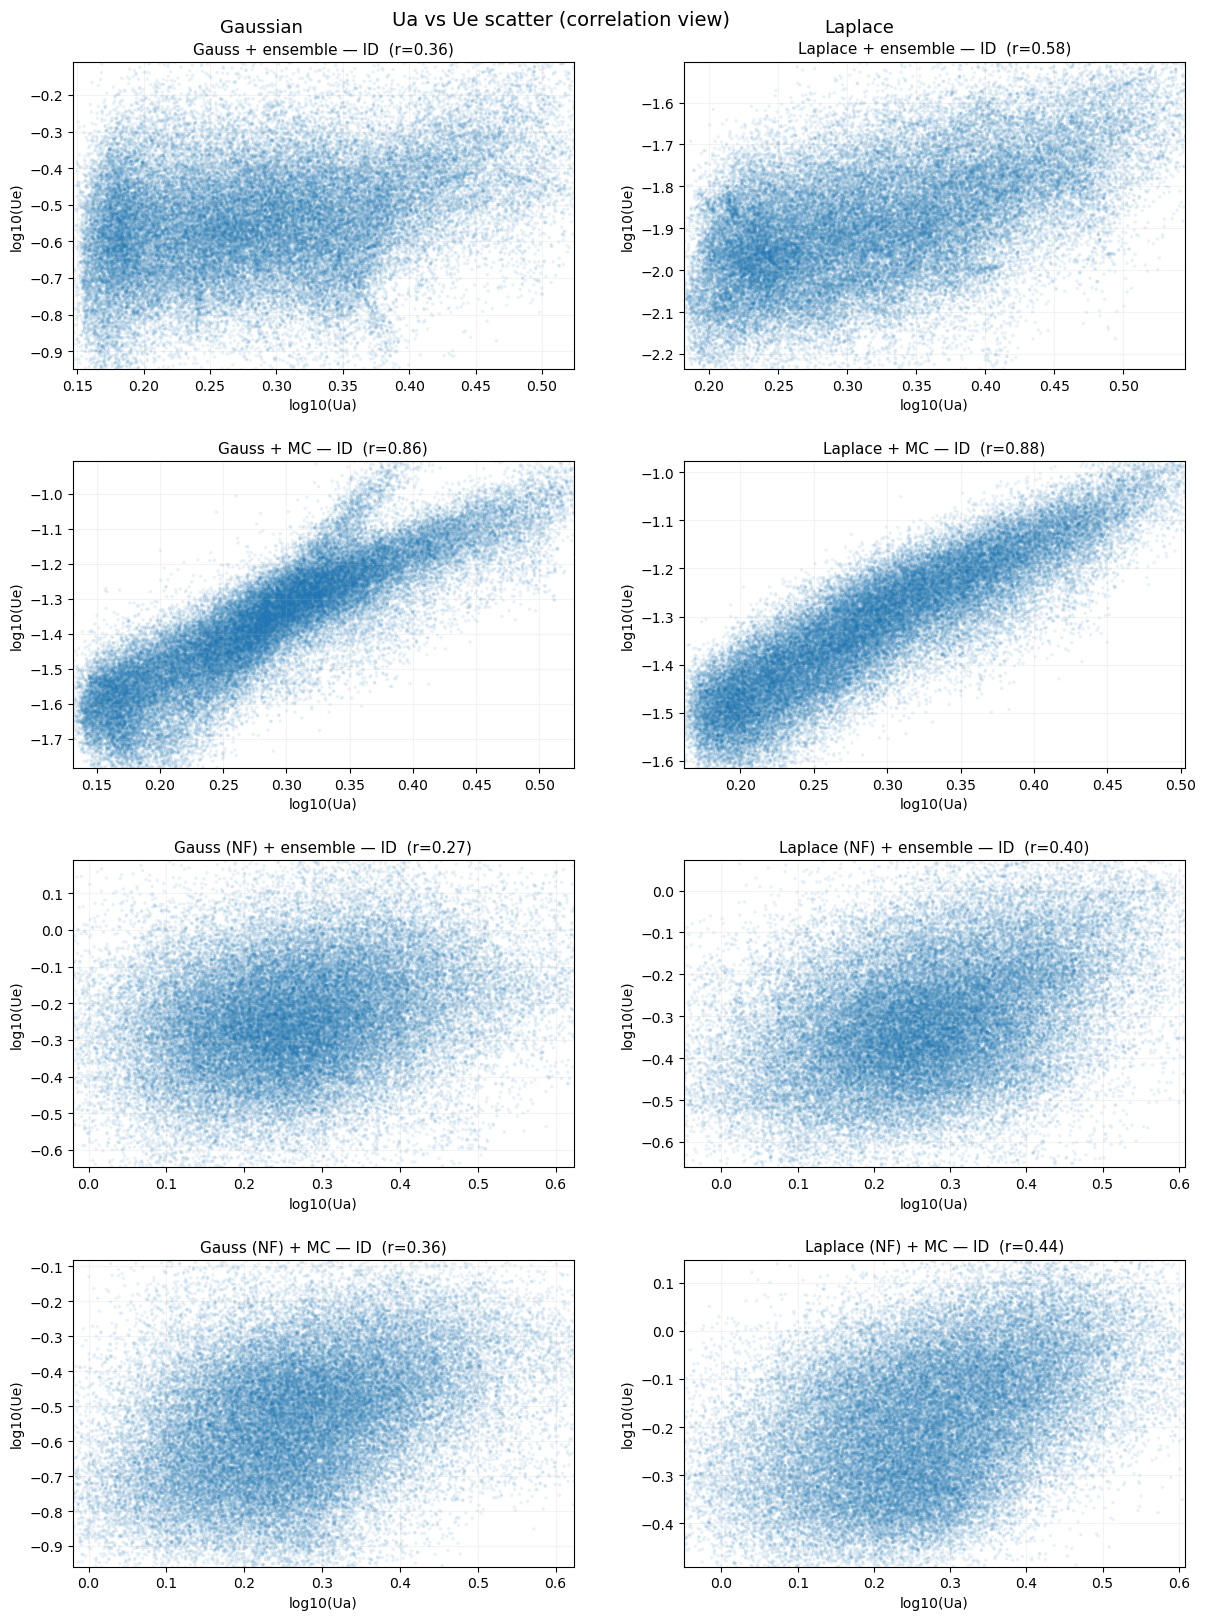

Message: "They’re not just scaled copies when r is well below 1.0."


In [106]:
# Phase 10B: Ua vs Ue scatter (correlation view)
# Same 2-column grid format (Gauss left, Laplace right), no shared axes.
# Each subplot shows Pearson r.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------- toggles (set here) -----------------
USE_CALIBRATED_SIGMAS_LOCAL = USE_CALIBRATED_SIGMAS if "USE_CALIBRATED_SIGMAS" in globals() else True

INCLUDE_OOD = False
OOD_LABEL_FOR_PLOTS = (list(OOD_LABELS)[0] if "OOD_LABELS" in globals() and list(OOD_LABELS) else None)  # e.g. "knn"

INCLUDE_NF_VARIANTS = True  # include (NF) variants if present
APPLY_KNN_BANDS_LOCAL = True

USE_LOG10_AXES = True
LOG_EPS = 1e-6

QUANTILE_LIMITS = (0.01, 0.99)  # per-panel axis limits
METHOD_KEYS = []  # optional: e.g. ["gau_mc", "esm_gau", "lpl_mc", "esm_lpl"]; leave [] for auto

MAX_POINTS_PER_PANEL = 50000
SCATTER_ALPHA = 0.10
SCATTER_SIZE = 6
RNG_SEED = 0
# ------------------------------------------------------

OOD_LABELS_LOCAL = list(OOD_LABELS) if "OOD_LABELS" in globals() else []
rng = np.random.default_rng(RNG_SEED)


def _is_nf_variant(spec: MethodSpec) -> bool:
    return str(getattr(spec, "aleatoric_source", "")).lower() == "nf" or getattr(spec, "kind", None) == "nf"


def _maybe_apply_knn(df_id: pd.DataFrame, df_ood: pd.DataFrame, ood_label: str, key: str):
    if APPLY_KNN_BANDS_LOCAL and "apply_knn_bands" in globals():
        try:
            return apply_knn_bands(df_id, df_ood, ood_label, key)
        except Exception as e:
            print(f"[knn bands skip] {key}/{ood_label}: {type(e).__name__}: {e}")
    return df_id, df_ood


def _sigmas(spec: MethodSpec, df: pd.DataFrame):
    s_a_raw = pd.to_numeric(df.get("sigma_ale_raw"), errors="coerce").to_numpy(float)
    s_e_raw = pd.to_numeric(df.get("sigma_epi_raw"), errors="coerce").to_numpy(float)
    miss_epi = ~np.isfinite(s_e_raw)
    s_e0 = np.nan_to_num(s_e_raw, nan=0.0)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        s_a, s_e, _s_t = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=s_a_raw,
            sigma_epi_raw=s_e0,
        )
        s_e = np.asarray(s_e, float)
        s_e[miss_epi] = np.nan
        return np.asarray(s_a, float), s_e

    return np.asarray(s_a_raw, float), np.asarray(s_e_raw, float)


def _load_slice(spec: MethodSpec, which: str, ood_label: str | None):
    if which == "id:test":
        return method_id_frame(spec, "test").copy()
    if which.startswith("ood:"):
        if not ood_label:
            raise ValueError("ood_label is None")
        return method_ood_frame(spec, ood_label).copy()
    raise ValueError(which)


def _prep_arrays(spec: MethodSpec, df: pd.DataFrame):
    s_a, s_e = _sigmas(spec, df)
    m = np.isfinite(s_a) & np.isfinite(s_e)
    if not np.any(m):
        return None
    ua = s_a[m]
    ue = s_e[m]

    if USE_LOG10_AXES:
        ua = np.log10(np.maximum(ua, LOG_EPS))
        ue = np.log10(np.maximum(ue, LOG_EPS))

    return ua, ue


def _pearson(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return float("nan")
    xx = x[m]
    yy = y[m]
    if np.nanstd(xx) == 0 or np.nanstd(yy) == 0:
        return float("nan")
    return float(np.corrcoef(xx, yy)[0, 1])


def _head_group(spec: MethodSpec) -> str | None:
    ht = str(getattr(spec, "head_type", "")).lower()
    if ht.startswith("gau") or "gauss" in ht or "gaussian" in ht or ht == "normal":
        return "gauss"
    if ht.startswith("lpl") or "laplace" in ht or "laplacian" in ht:
        return "laplace"
    return None


def _pair_key(spec: MethodSpec) -> str:
    k = str(getattr(spec, "key", getattr(spec, "label", ""))).lower()
    for tok in ("gaussian", "gauss", "gau", "laplace", "lpl"):
        k = k.replace(tok, "")
    while "__" in k:
        k = k.replace("__", "_")
    return k.strip("_")


def _sample(x: np.ndarray, y: np.ndarray, max_n: int):
    n = x.size
    if n <= max_n:
        return x, y
    idx = rng.choice(n, size=max_n, replace=False)
    return x[idx], y[idx]


# ----------------------------
# Select methods
# ----------------------------
if METHOD_KEYS:
    key_to_spec = {m.key: m for m in METHODS}
    specs = [key_to_spec[k] for k in METHOD_KEYS if k in key_to_spec]
else:
    specs = []
    for m in METHODS:
        if m.kind == "dido" or m.head_type == "point":
            continue
        epi = str(m.epistemic_source).lower()
        if epi not in {"mc", "ensemble"}:
            continue
        if (not INCLUDE_NF_VARIANTS) and _is_nf_variant(m):
            continue
        specs.append(m)

if not specs:
    print("[phase10B] No methods selected (need epi_source in {mc, ensemble}).")
else:
    if INCLUDE_OOD and not OOD_LABEL_FOR_PLOTS:
        print("[phase10B] INCLUDE_OOD=True but no OOD label available; plotting ID only.")
        INCLUDE_OOD = False

    # Build pairs: {pair_key: {gauss: spec, laplace: spec}}
    pairs = {}
    for spec in specs:
        grp = _head_group(spec)
        if grp is None:
            continue
        pk = _pair_key(spec)
        pairs.setdefault(pk, {})[grp] = spec

    base_keys = sorted(pairs.keys())

    if not base_keys:
        print("[phase10B] No gaussian/laplace methods found after grouping.")
    else:
        # Precompute packs
        pack_by_spec_slice = {}
        for pk in base_keys:
            for grp in ("gauss", "laplace"):
                spec = pairs[pk].get(grp)
                if spec is None:
                    continue

                try:
                    df_id = _load_slice(spec, "id:test", None)
                except Exception as e:
                    print(f"[skip phase10B] {spec.label} id:test: {type(e).__name__}: {e}")
                    pack_by_spec_slice[(spec.key, "id")] = None
                    pack_by_spec_slice[(spec.key, "ood")] = None
                    continue

                df_ood = None
                if INCLUDE_OOD:
                    try:
                        df_ood0 = _load_slice(spec, f"ood:{OOD_LABEL_FOR_PLOTS}", OOD_LABEL_FOR_PLOTS)
                        df_id2, df_ood = _maybe_apply_knn(df_id.copy(), df_ood0, OOD_LABEL_FOR_PLOTS, spec.key)
                        df_id = df_id2
                    except Exception as e:
                        print(f"[skip phase10B] {spec.label} ood:{OOD_LABEL_FOR_PLOTS}: {type(e).__name__}: {e}")
                        df_ood = None

                pack_id = _prep_arrays(spec, df_id)
                if pack_id is None:
                    print(f"[skip phase10B] {spec.label} id:test: no finite Ua/Ue.")
                pack_by_spec_slice[(spec.key, "id")] = pack_id

                pack_ood = None
                if INCLUDE_OOD and df_ood is not None:
                    pack_ood = _prep_arrays(spec, df_ood)
                    if pack_ood is None:
                        print(f"[skip phase10B] {spec.label} ood:{OOD_LABEL_FOR_PLOTS}: no finite Ua/Ue.")
                pack_by_spec_slice[(spec.key, "ood")] = pack_ood

        slice_rows = [("id", "ID")]
        if INCLUDE_OOD:
            slice_rows.append(("ood", f"OOD:{OOD_LABEL_FOR_PLOTS}"))

        n_slices = len(slice_rows)
        n_pairs = len(base_keys)
        nrows = n_pairs * n_slices

        fig, axes = plt.subplots(
            nrows,
            2,
            figsize=(13.0, 4.4 * nrows),
            sharex=False,
            sharey=False,
            constrained_layout=False,
        )
        axes = np.atleast_2d(axes)

        for i, pk in enumerate(base_keys):
            for j, (slice_key, slice_label) in enumerate(slice_rows):
                r = i * n_slices + j
                for c, grp in enumerate(("gauss", "laplace")):
                    ax = axes[r, c]
                    spec = pairs[pk].get(grp)
                    if spec is None:
                        ax.axis("off")
                        continue

                    pack = pack_by_spec_slice.get((spec.key, slice_key), None)
                    if pack is None:
                        ax.axis("off")
                        continue

                    ua, ue = pack
                    ua_s, ue_s = _sample(ua, ue, MAX_POINTS_PER_PANEL)

                    # per-panel axis limits
                    xlo, xhi = np.quantile(ua, QUANTILE_LIMITS)
                    ylo, yhi = np.quantile(ue, QUANTILE_LIMITS)
                    xpad = 0.03 * (xhi - xlo) if np.isfinite(xhi - xlo) and (xhi > xlo) else 0.1
                    ypad = 0.03 * (yhi - ylo) if np.isfinite(yhi - ylo) and (yhi > ylo) else 0.1

                    r_val = _pearson(ua, ue)
                    title = f"{spec.label} — {slice_label}  (r={r_val:.2f})"

                    ax.scatter(ua_s, ue_s, s=SCATTER_SIZE, alpha=SCATTER_ALPHA, color="tab:blue", edgecolors="none")
                    ax.set_xlim(xlo - xpad, xhi + xpad)
                    ax.set_ylim(ylo - ypad, yhi + ypad)
                    ax.set_title(title, fontsize=11)
                    ax.grid(True, alpha=0.15)
                    ax.set_xlabel("log10(Ua)" if USE_LOG10_AXES else "Ua")
                    ax.set_ylabel("log10(Ue)" if USE_LOG10_AXES else "Ue")

        fig.subplots_adjust(top=0.965, right=0.98, hspace=0.30, wspace=0.22)

        fig.text(0.27, 0.99, "Gaussian", ha="center", va="top", fontsize=13)
        fig.text(0.73, 0.99, "Laplace", ha="center", va="top", fontsize=13)
        fig.suptitle("Ua vs Ue scatter (correlation view)", y=0.995, fontsize=14)

        tag = "id_only" if not INCLUDE_OOD else f"id_vs_ood_{OOD_LABEL_FOR_PLOTS}"
        savefig(
            fig,
            f"ua_ue_scatter_grid_gauss_vs_laplace_{tag}_{'log' if USE_LOG10_AXES else 'lin'}_{'cal' if USE_CALIBRATED_SIGMAS_LOCAL else 'raw'}",
            dataset=DATASET_KEY,
            split="test",
        )
        plt.show()

print('Message: "They’re not just scaled copies when r is well below 1.0."')


In [107]:
# EXPORT / MANIFEST SUMMARY (for thesis Results)

import re
from pathlib import Path

# Where your thesis artifacts live (as requested)
TABLES_DIR = Path("thesis_manuscript/tables/generated")
FIGS_DIR = Path("thesis_manuscript/figures/generated")

# Fallback config locations (used only if the notebook doesn't expose the active paths)
FALLBACK_UQ_CFG = {
    "craigs": "configs/uq_analysis_craigs.yaml",
    "vw": "configs/uq_analysis_vw.yaml",
}
FALLBACK_KNN_CFG = {
    "craigs": "configs/knn_ood_craigs.yaml",
    "vw": "configs/knn_ood_vw.yaml",
}

KNN_DEF_ID_PCT = 80
KNN_DEF_OOD_TAIL = "95th–100th"
KNN_DEF_MID_BAND_IGNORED = True


def _load_yaml(path: str):
    p = Path(path)
    if not p.exists():
        return None
    try:
        import yaml  # type: ignore
        return yaml.safe_load(p.read_text())
    except Exception:
        return None


def _deep_get(d, key):
    if isinstance(d, dict):
        if key in d:
            return d[key]
        for v in d.values():
            r = _deep_get(v, key)
            if r is not None:
                return r
    if isinstance(d, list):
        for v in d:
            r = _deep_get(v, key)
            if r is not None:
                return r
    return None


def _first(*vals, default="UNKNOWN"):
    for v in vals:
        if v is None:
            continue
        if isinstance(v, str) and not v.strip():
            continue
        return v
    return default


def _as_str(v):
    if v is None:
        return "UNKNOWN"
    if isinstance(v, bool):
        return "Yes" if v else "No"
    if isinstance(v, (list, tuple)):
        return "[" + ", ".join(map(str, v)) + "]"
    return str(v)


def _infer_dataset_key():
    # Prefer runtime globals from the notebook
    ds = None
    for k in ("DATASET_KEY", "DATASET", "dataset_key", "dataset"):
        if k in globals() and globals()[k] is not None:
            ds = str(globals()[k])
            break
    if ds is None and "settings" in globals() and isinstance(settings, dict):
        ds = settings.get("dataset_key") or settings.get("dataset") or settings.get("name")
    if ds is None:
        return "UNKNOWN"

    s = str(ds).lower()
    if "craig" in s or "craigs" in s:
        return "craigs"
    if s == "vw" or " vw" in s or "vw_" in s or "_vw" in s:
        return "vw"
    return s


def _infer_dataset_name(ds_key: str):
    if ds_key == "craigs":
        return "Craigslist"
    if ds_key == "vw":
        return "VW"
    return ds_key.upper() if ds_key != "UNKNOWN" else "UNKNOWN"


def _active_config_paths(ds_key: str):
    # Try to get the exact config paths used in this run from globals/settings.
    uq_path = None
    knn_path = None

    for k in ("UQ_CONFIG_PATH", "CONFIG_PATH", "CONFIG_FILE", "UQ_YAML", "UQ_CONFIG"):
        if k in globals() and globals()[k]:
            uq_path = str(globals()[k])
            break
    if uq_path is None and "settings" in globals() and isinstance(settings, dict):
        uq_path = settings.get("config_path") or settings.get("uq_config") or settings.get("uq_config_path")

    for k in ("KNN_CONFIG_PATH", "KNN_YAML", "KNN_CONFIG"):
        if k in globals() and globals()[k]:
            knn_path = str(globals()[k])
            break
    if knn_path is None and "settings" in globals() and isinstance(settings, dict):
        knn_path = settings.get("knn_config") or settings.get("knn_config_path")

    # Fall back to the known defaults per dataset
    if uq_path is None:
        uq_path = FALLBACK_UQ_CFG.get(ds_key, "UNKNOWN")
    if knn_path is None:
        knn_path = FALLBACK_KNN_CFG.get(ds_key, "UNKNOWN")

    return uq_path, knn_path


def _scan_files(dirpath: Path):
    if not dirpath.exists():
        return []
    return sorted([p.name for p in dirpath.glob("*") if p.is_file()])


def _filter_dataset_files(files, ds_key: str):
    if ds_key == "UNKNOWN":
        return files
    pat = re.compile(rf"(^|[^a-z0-9]){re.escape(ds_key)}([^a-z0-9]|$)", re.IGNORECASE)
    out = [f for f in files if pat.search(f) or ds_key in f.lower()]
    return out


def _pick_prefixes(files, prefixes, limit=6):
    hits = []
    for pref in prefixes:
        for f in files:
            if f.startswith(pref):
                hits.append(f)
    hits = list(dict.fromkeys(hits))
    return hits[:limit] if hits else ["UNKNOWN"]


def _variants_from_methods():
    if "METHODS" not in globals():
        return ["UNKNOWN"]
    variants = set()
    for m in METHODS:
        ht = str(getattr(m, "head_type", "")).lower()
        kind = str(getattr(m, "kind", "")).lower()
        epi = str(getattr(m, "epistemic_source", "")).lower()
        ale = str(getattr(m, "aleatoric_source", "")).lower()

        if kind == "dido":
            if "gauss" in ht:
                variants.add("DIDO (Gaussian)")
            if "laplace" in ht:
                variants.add("DIDO (Laplace)")
            continue

        if ht == "point":
            variants.add("Point")
        if "gauss" in ht:
            variants.add("Gaussian")
        if "laplace" in ht:
            variants.add("Laplace")

        if epi == "mc":
            if "gauss" in ht:
                variants.add("MC Dropout (Gaussian)")
            if "laplace" in ht:
                variants.add("MC Dropout (Laplace)")
        if epi == "ensemble":
            if "gauss" in ht:
                variants.add("Deep Ensemble (Gaussian)")
            if "laplace" in ht:
                variants.add("Deep Ensemble (Laplace)")

        if ale == "nf" or kind == "nf":
            if "gauss" in ht:
                variants.add("NF (Gaussian)")
            if "laplace" in ht:
                variants.add("NF (Laplace)")

    return sorted(variants) if variants else ["UNKNOWN"]


def _beta_grid_summary():
    bg = globals().get("BETA_GRID", None)
    if bg is None:
        return "UNKNOWN"
    try:
        import numpy as np
        a = np.asarray(bg, float)
        if a.size == 0:
            return "UNKNOWN"
        return f"min={a.min():.3g}, max={a.max():.3g}, n={a.size}"
    except Exception:
        return str(bg)


# ------------------- dataset-scoped manifest -------------------

ds_key = _infer_dataset_key()
ds_name = _infer_dataset_name(ds_key)
uq_cfg_path, knn_cfg_path = _active_config_paths(ds_key)

uq_cfg = _load_yaml(uq_cfg_path) if uq_cfg_path != "UNKNOWN" else None
knn_cfg = _load_yaml(knn_cfg_path) if knn_cfg_path != "UNKNOWN" else None

# pull common fields from configs (best-effort)
splits_random = _first(
    _deep_get(uq_cfg, "splits_random"),
    _deep_get(uq_cfg, "split_random"),
    _deep_get(uq_cfg, "random_split"),
    globals().get("SPLITS_RANDOM", None),
)

target_transform = _first(
    _deep_get(uq_cfg, "target_transform"),
    _deep_get(uq_cfg, "y_transform"),
    _deep_get(uq_cfg, "label_transform"),
    globals().get("TARGET_TRANSFORM", None),
)

knn_dim = _first(
    _deep_get(knn_cfg, "knn_dim"),
    _deep_get(knn_cfg, "projection_dim"),
    _deep_get(knn_cfg, "proj_dim"),
    globals().get("KNN_DIM", None),
)

knn_k_grid = _first(
    _deep_get(knn_cfg, "knn_k_grid"),
    _deep_get(knn_cfg, "k_grid"),
    _deep_get(knn_cfg, "k_candidates"),
    globals().get("KNN_K_GRID", None),
)

knn_k_selected = _first(
    _deep_get(knn_cfg, "knn_k_selected"),
    _deep_get(knn_cfg, "selected_k"),
    _deep_get(knn_cfg, "k_selected"),
    globals().get("KNN_K_SELECTED", None),
)

knn_k_select_split = _first(
    _deep_get(knn_cfg, "knn_k_select_split"),
    _deep_get(knn_cfg, "k_select_split"),
    _deep_get(knn_cfg, "select_split"),
    globals().get("KNN_K_SELECT_SPLIT", None),
)

dido_signal = _first(
    (settings.get("dido_signal") if "settings" in globals() and isinstance(settings, dict) else None),
    _deep_get(uq_cfg, "dido_signal"),
    "dido_vacuity_raw",
)

use_cal = globals().get("USE_CALIBRATED_SIGMAS", True)
calib_split = _first(_deep_get(uq_cfg, "calib_split"), globals().get("CALIB_SPLIT", None), default="val")
calib_objective = _first(_deep_get(uq_cfg, "calib_objective"), globals().get("CALIB_OBJECTIVE", None), default="Gaussian NLL")
beta_grid_summary = _beta_grid_summary()

tau_val = globals().get("TAU", "UNKNOWN")

variants = _variants_from_methods()

# artifacts for this dataset run
tables = _filter_dataset_files(_scan_files(TABLES_DIR), ds_key)
figs = _filter_dataset_files(_scan_files(FIGS_DIR), ds_key)

predictive_files = _pick_prefixes(tables + figs, ["id_vs_ood_", "id_vs_ood_metrics", "id_only_", "id_vs_id"])
calibration_files = _pick_prefixes(tables + figs, ["calibration_coverage", "calibration_"])
ale_validity_files = _pick_prefixes(tables + figs, ["noise_cohort", "decomp_total_contrib", "decomp_total_"])
ood_files = _pick_prefixes(tables + figs, ["ood_detection_", "ood_gains_curves", "dido_ood_gains"])
large_error_files = _pick_prefixes(tables + figs, ["large_error_", "large_error_gains"])
unique_info_files = _pick_prefixes(tables + figs, ["ua_ue_", "conditional_auc", "redundancy_corr", "decision_synergy"])

print("RESULTS MANIFEST (for thesis Results)")
print("=" * 78)
print(f"- Dataset: {ds_name}  (dataset_key={ds_key})")
print(f"- UQ config used: {uq_cfg_path}")
print(f"- kNN OOD config used: {knn_cfg_path}")

print("\n1) Datasets and evaluation splits")
print(f"- Splits random: {_as_str(splits_random)}")
print("- kNN OOD definition used in results:")
print(f"  - ID band: up to {KNN_DEF_ID_PCT}th percentile kNN distance")
print(f"  - OOD tail: {KNN_DEF_OOD_TAIL} percentile tail")
print(f"  - 80–95% middle band ignored for ID-vs-OOD separation analyses: {_as_str(KNN_DEF_MID_BAND_IGNORED)}")
print("- kNN settings:")
print(f"  - projection dimension d: {_as_str(knn_dim)}")
print(f"  - K candidate grid: {_as_str(knn_k_grid)}")
print(f"  - selected K: {_as_str(knn_k_selected)}")
print(f"  - split used to select K: {_as_str(knn_k_select_split)}")

print("\n2) Signals and model variants included")
print(f"- Evaluated variants (from METHODS in this run): {', '.join(variants)}")
print("- Uncertainty outputs / interpretation:")
print("  - Aleatoric ranking scale: sigma_ale_cal (NF: sigma_ale_nf_cal)")
print("  - Epistemic ranking scale: sigma_epi_cal (MC/Ensemble only)")
print(f"  - DIDO ranking score used: {dido_signal} (alternative: dido_strength_raw)")
print("  - DIDO is NOT mapped to sigma and NOT combined by quadrature: Yes")
print("  - NF produces aleatoric-only signal (no epistemic): Yes")

print("\n3) Calibration settings")
print("- Alpha calibration: global multiplicative variance scaling (sigma_ale^2 *= alpha), fit on validation")
print(f"- Beta calibration: sigma_epi^2 *= beta, grid search; objective={_as_str(calib_objective)}; fit on {calib_split}")
print(f"- Beta grid (range/size): {beta_grid_summary}")
print(f"- Calibration applied to ID test and OOD evaluation: {_as_str(use_cal)}")

print("\n4) Large-error threshold")
print("- Tau definition: 95th percentile of |error| on validation using the point baseline; then frozen for test and OOD")
print(f"- Tau value (if computed in this session): {_as_str(tau_val)}")

print("\n5) Target transform / reporting space")
print(f"- Target transform: {_as_str(target_transform)}")
print("- Reporting space: original target units after inverse transform; uncertainty mapped via delta-method approximation")

print("\n6) Pointers to exported artifacts")
print(f"- Tables dir: {TABLES_DIR}")
print(f"- Figures dir: {FIGS_DIR}")
print("- Key files by Results subsection (filtered to this dataset):")
print(f"  - predictive quality: {_as_str(predictive_files)}")
print(f"  - calibration: {_as_str(calibration_files)}")
print(f"  - aleatoric validity: {_as_str(ale_validity_files)}")
print(f"  - epistemic on OOD: {_as_str(ood_files)}")
print(f"  - large-error detection: {_as_str(large_error_files)}")
print(f"  - unique information: {_as_str(unique_info_files)}")


RESULTS MANIFEST (for thesis Results)
- Dataset: VW  (dataset_key=vw)
- UQ config used: /home/canelo/uncertainty_quantification/configs/uq_analysis_vw.yaml
- kNN OOD config used: configs/knn_ood_vw.yaml

1) Datasets and evaluation splits
- Splits random: UNKNOWN
- kNN OOD definition used in results:
  - ID band: up to 80th percentile kNN distance
  - OOD tail: 95th–100th percentile tail
  - 80–95% middle band ignored for ID-vs-OOD separation analyses: Yes
- kNN settings:
  - projection dimension d: 32
  - K candidate grid: UNKNOWN
  - selected K: UNKNOWN
  - split used to select K: UNKNOWN

2) Signals and model variants included
- Evaluated variants (from METHODS in this run): DIDO (Gaussian), DIDO (Laplace), Deep Ensemble (Gaussian), Deep Ensemble (Laplace), Gaussian, Laplace, MC Dropout (Gaussian), MC Dropout (Laplace), NF (Gaussian), NF (Laplace), Point
- Uncertainty outputs / interpretation:
  - Aleatoric ranking scale: sigma_ale_cal (NF: sigma_ale_nf_cal)
  - Epistemic ranking sca

In [108]:
# # Write export manifest.
# run_dirs = None
# if "RUN_DIRS" in globals():
#     run_dirs = {k: (str(v) if v else None) for k, v in RUN_DIRS.items()}

# extra = {
#     "config_path": str(CONFIG_PATH) if "CONFIG_PATH" in globals() else None,
#     "eval_root": str(EVAL_ROOT) if "EVAL_ROOT" in globals() else None,
#     "dataset_key": DATASET_KEY if "DATASET_KEY" in globals() else None,
#     "ood_labels": OOD_LABELS if "OOD_LABELS" in globals() else None,
#     "large_error": LARGE_ERROR if "LARGE_ERROR" in globals() else None,
#     "tau": float(TAU) if "TAU" in globals() else None,
#     "run_dirs": run_dirs,
# }
# EXPORTER.write_manifest(extra=extra, project_root=PROJECT_ROOT)
